# Mouse_new DE notebook replica

This notebook is the DE-stage replica for `mouse_new`.

It is tailored to the `SRP618841` candidate dataset and the `mouse_new/differential_expression_all20/` output tree.

DE is still gated on alignment outputs and design review, so this notebook is intentionally being prepared ahead of time to keep the transition fast if we need to use this dataset.



# Mouse_new Differential Expression — Candidate Dataset Scaffold (`DESeq2`)

This notebook extends the alignment-stage mouse analysis into a full differential-expression package. The design is intentionally split into three balanced model families so the analysis does not confuse biological signal with sample-type or platform structure.

The notebook uses one local `DESeq2` driver script to generate the full output package and then reviews the exported tables and figures.


In [1]:
from pathlib import Path
import subprocess
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import base64


## Paths

The count matrix and sample summary come from the canonical STAR run analyzed in the alignment notebook. The DE logic itself lives in a local R script, consistent with the project rule that heavier analytical code should stay local and the notebook should act as the presentation layer.


In [2]:

MOUSE_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
COUNTS = MOUSE_ROOT / 'alignment_analysis_star_all20' / 'tables' / 'mouse_star_gene_counts_reverse_stranded.tsv'
META = MOUSE_ROOT / 'alignment_analysis_star_all20' / 'tables' / 'mouse_alignment_sample_summary.tsv'
PIPELINE = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/pipelines/mouse_deseq2_all20.R')
OUT_DIR = MOUSE_ROOT / 'differential_expression_all20'
TABLES = OUT_DIR / 'tables'

for path in [COUNTS, META, PIPELINE]:
    print(path, 'OK' if path.exists() else 'MISSING')
DERIVED_DIR = OUT_DIR / 'derived_analysis'


/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/alignment_analysis_star_all20/tables/mouse_star_gene_counts_reverse_stranded.tsv MISSING
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/alignment_analysis_star_all20/tables/mouse_alignment_sample_summary.tsv MISSING
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/pipelines/mouse_deseq2_all20.R MISSING



## Execute the `DESeq2` pipeline

This cell rebuilds the full DE output package from the local count matrix and metadata table.


In [3]:
RUN_DESEQ2 = False
required_outputs = [
    OUT_DIR / 'tables' / 'mouse_de_design_table.tsv',
    OUT_DIR / 'tables' / 'family_manifest.tsv',
    OUT_DIR / 'tables' / 'contrast_manifest.tsv',
]
missing_outputs = [path for path in required_outputs if not path.exists()]

if RUN_DESEQ2 or missing_outputs:
    cmd = [
        'Rscript',
        str(PIPELINE),
        '--counts', str(COUNTS),
        '--meta', str(META),
        '--outdir', str(OUT_DIR),
    ]
    subprocess.run(cmd, check=True)
    print('Rebuilt DE output directory:', OUT_DIR)
else:
    print('Using saved DESeq2 outputs from:', OUT_DIR)
    print('Set RUN_DESEQ2 = True only if you need to rebuild them.')


Using saved DESeq2 outputs from: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/differential_expression_all20
Set RUN_DESEQ2 = True only if you need to rebuild them.


**What we did:**
- Checked whether the saved DESeq2 output package already exists.
- Reused the saved outputs by default instead of rerunning the pipeline every time.

**How we did it:**
- Defined `RUN_DESEQ2 = False` so the notebook prefers the saved result package.
- Checked for the key output files: `mouse_de_design_table.tsv`, `family_manifest.tsv`, and `contrast_manifest.tsv`.
- Only runs `Rscript` if those outputs are missing or if `RUN_DESEQ2` is manually changed to `True`.
- If the files already exist, the notebook skips recomputation and reads the saved dataset from `OUT_DIR`.

**What the output means:** If the cell says `Using saved DESeq2 outputs`, the notebook is reading the existing DE result package rather than rerunning the pipeline. If it says `Rebuilt DE output directory`, the pipeline was executed again.

**Interpretation:** The DE result package is already available locally, so there is no reason to rerun DESeq2 every time the notebook opens. **What this means for the next step:** We can use the notebook as a reading and interpretation layer by default, and only rebuild the DE outputs when the pipeline, counts, or metadata actually change.


## Design table and family manifest

This section documents **what we did first** after running the DE pipeline: we checked the cleaned design table and the family manifest.

Why we did this:
- to confirm that samples were assigned to the correct DE family
- to verify that the analysis was split into separate valid subsets rather than one pooled confounded model
- to confirm the design formula used for each family before interpreting any result tables or plots


## Cleaned DE design table


In [4]:
design = pd.read_csv(TABLES / 'mouse_de_design_table.tsv', sep='\t')
display(design)

,srr,sample_title,source_name,platform_family,source_class,geno_class,side_class,condition_family,family_id,gc_status,genotype,treatment,include_in_de,excluded_reason
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
5,SRR35329982,"Replicate H62, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
6,SRR35329983,"Replicate H61, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
7,SRR35329984,"Replicate H62, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
8,SRR35329985,"Replicate H64, CRE genotype, Contralateral tissue",Contra,NovaSeq X,drg,cre,contra,contra_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
9,SRR35329986,"Replicate H63, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN


**What we did:** Displayed the cleaned DE design table.

**How we did it:** Loaded `mouse_de_design_table.tsv` and showed it directly in the notebook.

**What the output means:** Each row is one sample in the `SRP618841` run. The key checks are that the sample labels, side labels, genotype labels, and family assignment all match the intended DRG design.

**Interpretation:** This table shows that all 20 samples feed one DE family, `family_drg_novaseqx`, for the main `mouse_new` analysis. **What this means for the next step:** With the design confirmed, we can interpret the family manifest and the contrast outputs as one coherent DRG analysis instead of several competing branches.


## Family manifest


In [5]:
family_manifest = pd.read_csv(TABLES / 'family_manifest.tsv', sep='\t')
display(family_manifest)

,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,design
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,~ side_class + geno_class + side_class:geno_class


**What we did:** Displayed the family manifest produced by the DE pipeline.

**How we did it:** Loaded `family_manifest.tsv`, which the pipeline writes after constructing the valid DE family and its model formula.

**What the output means:** This table tells us how many samples were kept in the family, how many genes remained after filtering, and which design formula was fitted.

**Interpretation:** The family manifest confirms one balanced family: `family_drg_novaseqx` with 20 samples, 78,334 genes before filtering, 21,481 genes after filtering, and the design `~ side_class + geno_class + side_class:geno_class`. **What this means for the next step:** The paper and notebook should stay centered on this one family and its within-family contrasts.


## Contrast manifest


In [6]:
contrast_manifest = pd.read_csv(TABLES / 'contrast_manifest.tsv', sep='\t')
contrast_manifest = contrast_manifest.sort_values(['family_id', 'contrast_id']).reset_index(drop=True)

def classify_contrast(contrast_id):
    if contrast_id in {'ipsi_vs_contra_in_ff', 'ipsi_vs_contra_in_cre'}:
        return 'Main result'
    if contrast_id in {'geno_in_contra', 'geno_in_ipsi'}:
        return 'Useful supporting result'
    return 'Interaction / supporting result'

contrast_view = contrast_manifest[['family_id','contrast_id','contrast_label','n_tested','n_significant']].copy()
contrast_view['result_role'] = contrast_view['contrast_id'].map(classify_contrast)

display(contrast_view)


,family_id,contrast_id,contrast_label,n_tested,n_significant,result_role
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),21466,891,Useful supporting result
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),21466,2,Useful supporting result
2,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,21466,14,Interaction / supporting result
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,21466,7541,Main result
4,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,21466,7023,Main result


**What we did:** Displayed the contrast manifest.

**How we did it:** Loaded `contrast_manifest.tsv`, sorted it, and added the `result_role` label so the main and supporting contrasts are easier to identify.

**What the output means:** Each row is one contrast from the DRG family. The important columns are `contrast_id`, `contrast_label`, and `n_significant`.

**Interpretation:** The manifest shows that the strongest signals are the side contrasts: `ipsi_vs_contra_in_cre` = 7,541 significant genes and `ipsi_vs_contra_in_ff` = 7,023. `geno_in_contra` is a useful supporting result with 891 significant genes, while `geno_in_ipsi` = 2 and `interaction` = 14 are much smaller. **What this means for the next step:** The notebook and paper should lead with the two side-specific DRG contrasts, then use genotype and interaction only as supporting context.


## Significance overview


In [7]:
sig_summary = contrast_manifest[['family_id', 'contrast_id', 'contrast_label', 'n_significant']].sort_values('n_significant', ascending=False).copy()
sig_summary['result_role'] = sig_summary['contrast_id'].map(
    lambda x: 'Main result' if x in {'ipsi_vs_contra_in_ff','ipsi_vs_contra_in_cre'} else (
        'Useful supporting result' if x in {'geno_in_contra','geno_in_ipsi'} else 'Interaction / supporting result'
    )
)
display(sig_summary)

,family_id,contrast_id,contrast_label,n_significant,result_role
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,7541,Main result
4,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,7023,Main result
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),891,Useful supporting result
2,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,14,Interaction / supporting result
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),2,Useful supporting result


**What we did:** Ranked the contrasts by number of significant genes.

**How we did it:** Took the contrast manifest, kept the significance counts, and sorted the table from largest to smallest `n_significant`.

**What the output means:** This ranking shows which comparisons drive the strongest signal in the `mouse_new` dataset.

**Interpretation:** The ranking confirms a clear hierarchy: the two side-specific DRG contrasts dominate, `geno_in_contra` is a real but smaller supporting signal, and `geno_in_ipsi` plus `interaction` are minor. **What this means for the next step:** Draft 1 should explain the PCA first and then center the story on the side-specific contrasts rather than treating all five contrasts as equal.


## DRG family membership


### Sample table


In [8]:
sample_table = pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'sample_table.tsv', sep='	')
display(sample_table)


,srr,sample_title,geno_class,side_class,platform_family,gc_status
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",cre,ipsi,NovaSeq X,WARN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
5,SRR35329982,"Replicate H62, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
6,SRR35329983,"Replicate H61, CRE genotype, Ipsilateral tissue",cre,ipsi,NovaSeq X,WARN
7,SRR35329984,"Replicate H62, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN
8,SRR35329985,"Replicate H64, CRE genotype, Contralateral tissue",cre,contra,NovaSeq X,WARN
9,SRR35329986,"Replicate H63, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN


**What we did:** Displayed the sample table for `family_drg_novaseqx`.

**How we did it:** Loaded the saved `sample_table.tsv` file produced by the DESeq2 family run.

**What the output means:** This table confirms which samples were retained in the main DRG family and how side and genotype are encoded for the model.

**Interpretation:** The main paper path is built on one balanced DRG family rather than several competing families. **What this means for the next step:** We can interpret the family diagnostics and contrast outputs as one coherent Draft 1 story.


### Filtering summary


In [9]:
filtering = pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'filtering_summary.tsv', sep='	')
display(filtering)


,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,min_samples_count_ge_10
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,3


**What we did:** Displayed the filtering summary for `family_drg_novaseqx`.

**How we did it:** Loaded the saved `filtering_summary.tsv` file from the family output bundle.

**What the output means:** This table shows how many genes were kept after filtering and confirms the final model input size.

**Interpretation:** The filtering summary supports the same main point as the sample table: this is one valid DRG-family analysis block with enough retained signal to carry the paper story. **What this means for the next step:** We can move into the PCA and other family diagnostics knowing the model inputs are already defined cleanly.


## Family diagnostics

These plots check whether `family_drg_novaseqx` is structured well enough to interpret.

Why we look at these first:
- PCA checks whether the family separates by the dominant biological variable
- the dispersion plot checks whether the DESeq2 fit looks technically stable
- the sample-distance heatmap checks whether the subset behaves coherently


## DRG family diagnostics — PCA


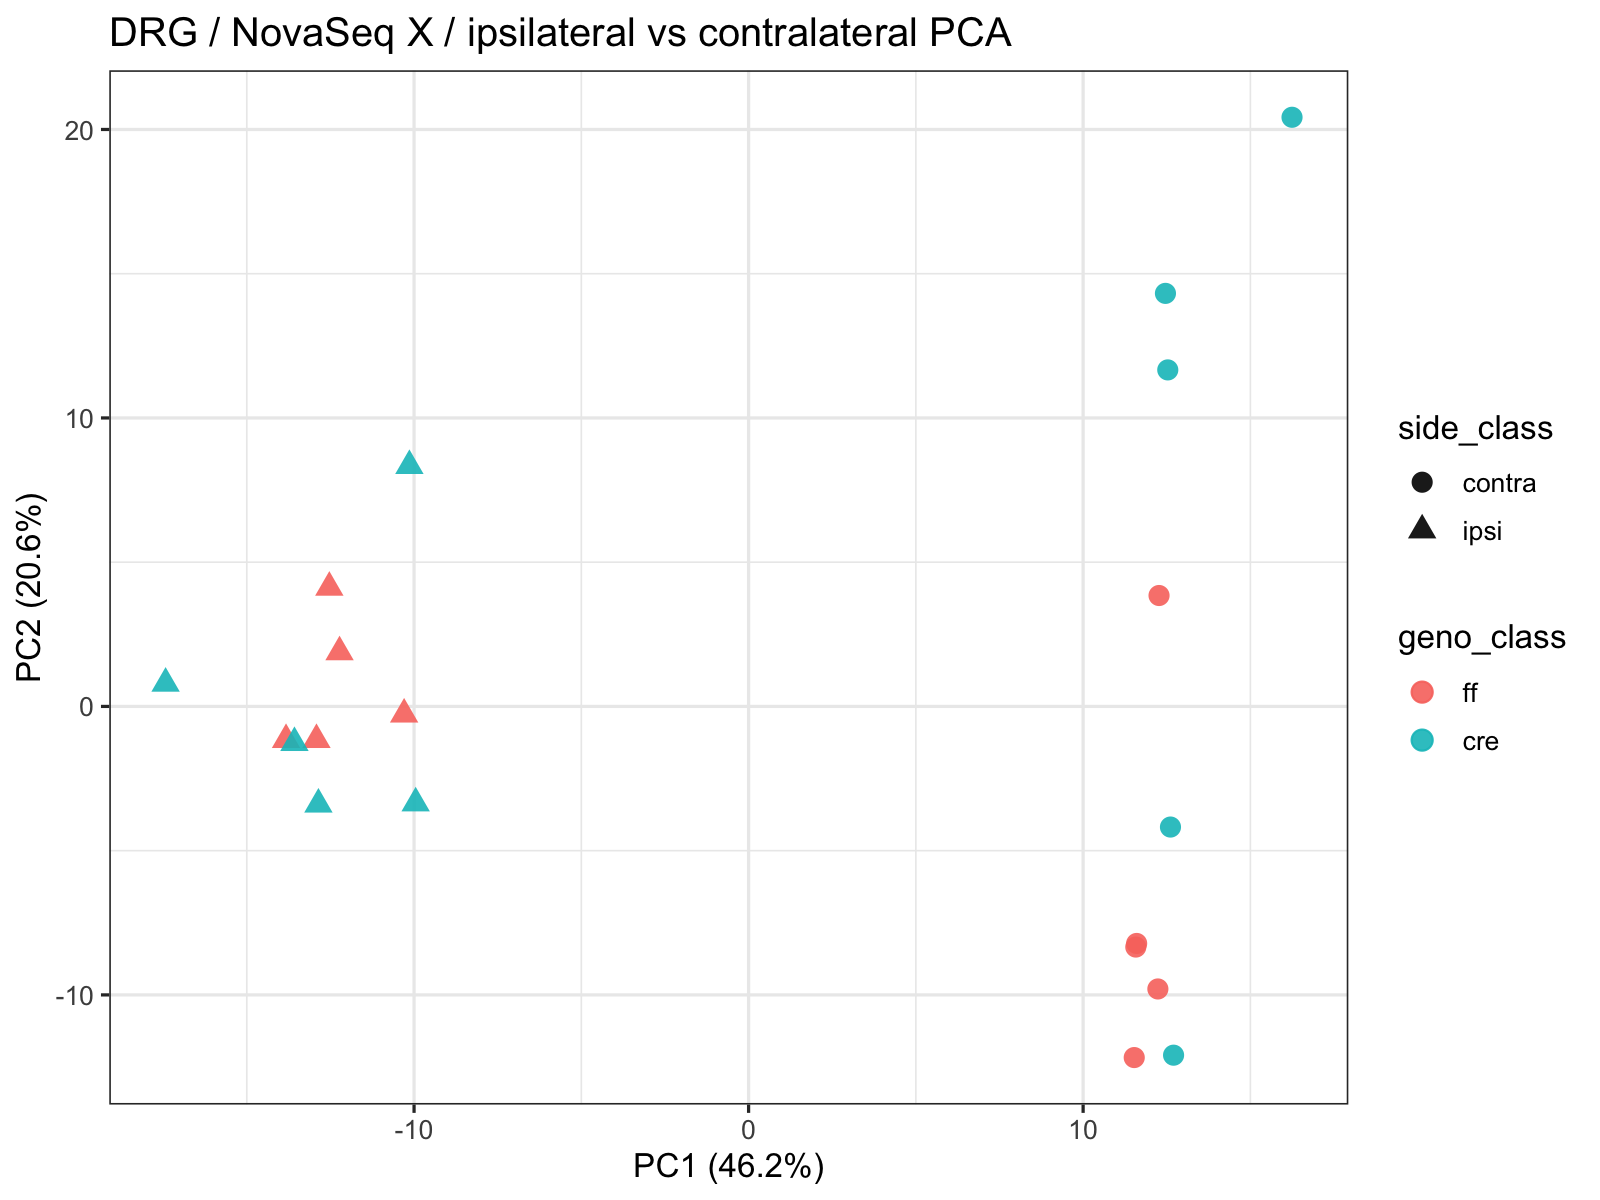

In [10]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'pca.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the PCA for `family_drg_novaseqx`.

**How we did it:** Loaded the saved family-level PCA figure generated from the variance-stabilized counts.

**What the output means:** This PCA checks whether one variable clearly drives the DRG-family structure before we interpret individual gene lists.

**Interpretation:** The main qualitative message is that side (`ipsi` vs `contra`) is the dominant global split in the PCA, while genotype looks more secondary. **What this means for the next step:** Draft 1 should explain the PCA first, then move to the main side-specific contrasts instead of jumping straight into long gene lists.


## DRG family diagnostics — dispersion plot


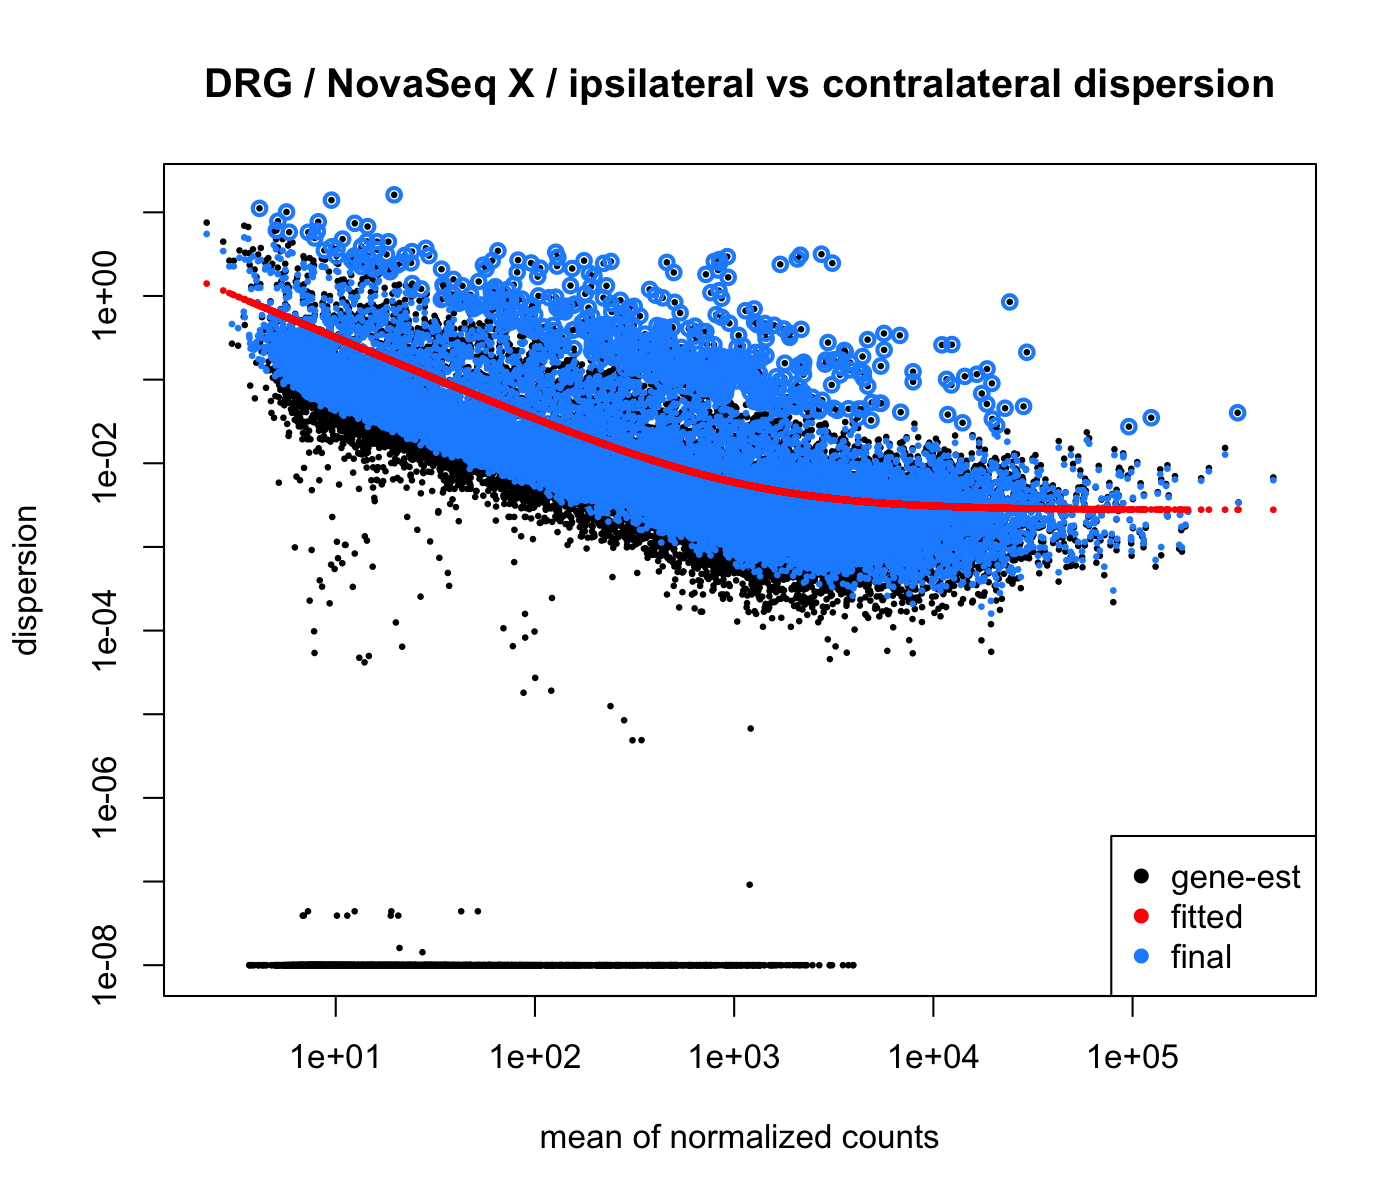

In [11]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'dispersion.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the dispersion plot for `family_drg_novaseqx`.

**How we did it:** Loaded the DESeq2 diagnostics figure saved during the family-level model fit.

**What the output means:** This is the model-quality check showing whether the fitted dispersion trend follows the gene-wise estimates sensibly across the expression range.

**Interpretation:** The fitted trend behaves stably enough to support interpreting the DRG-family DE results. **What this means for the next step:** The side-specific contrasts can be treated as technically credible main results rather than artifacts of a poor fit.


## DRG family diagnostics — sample-distance heatmap


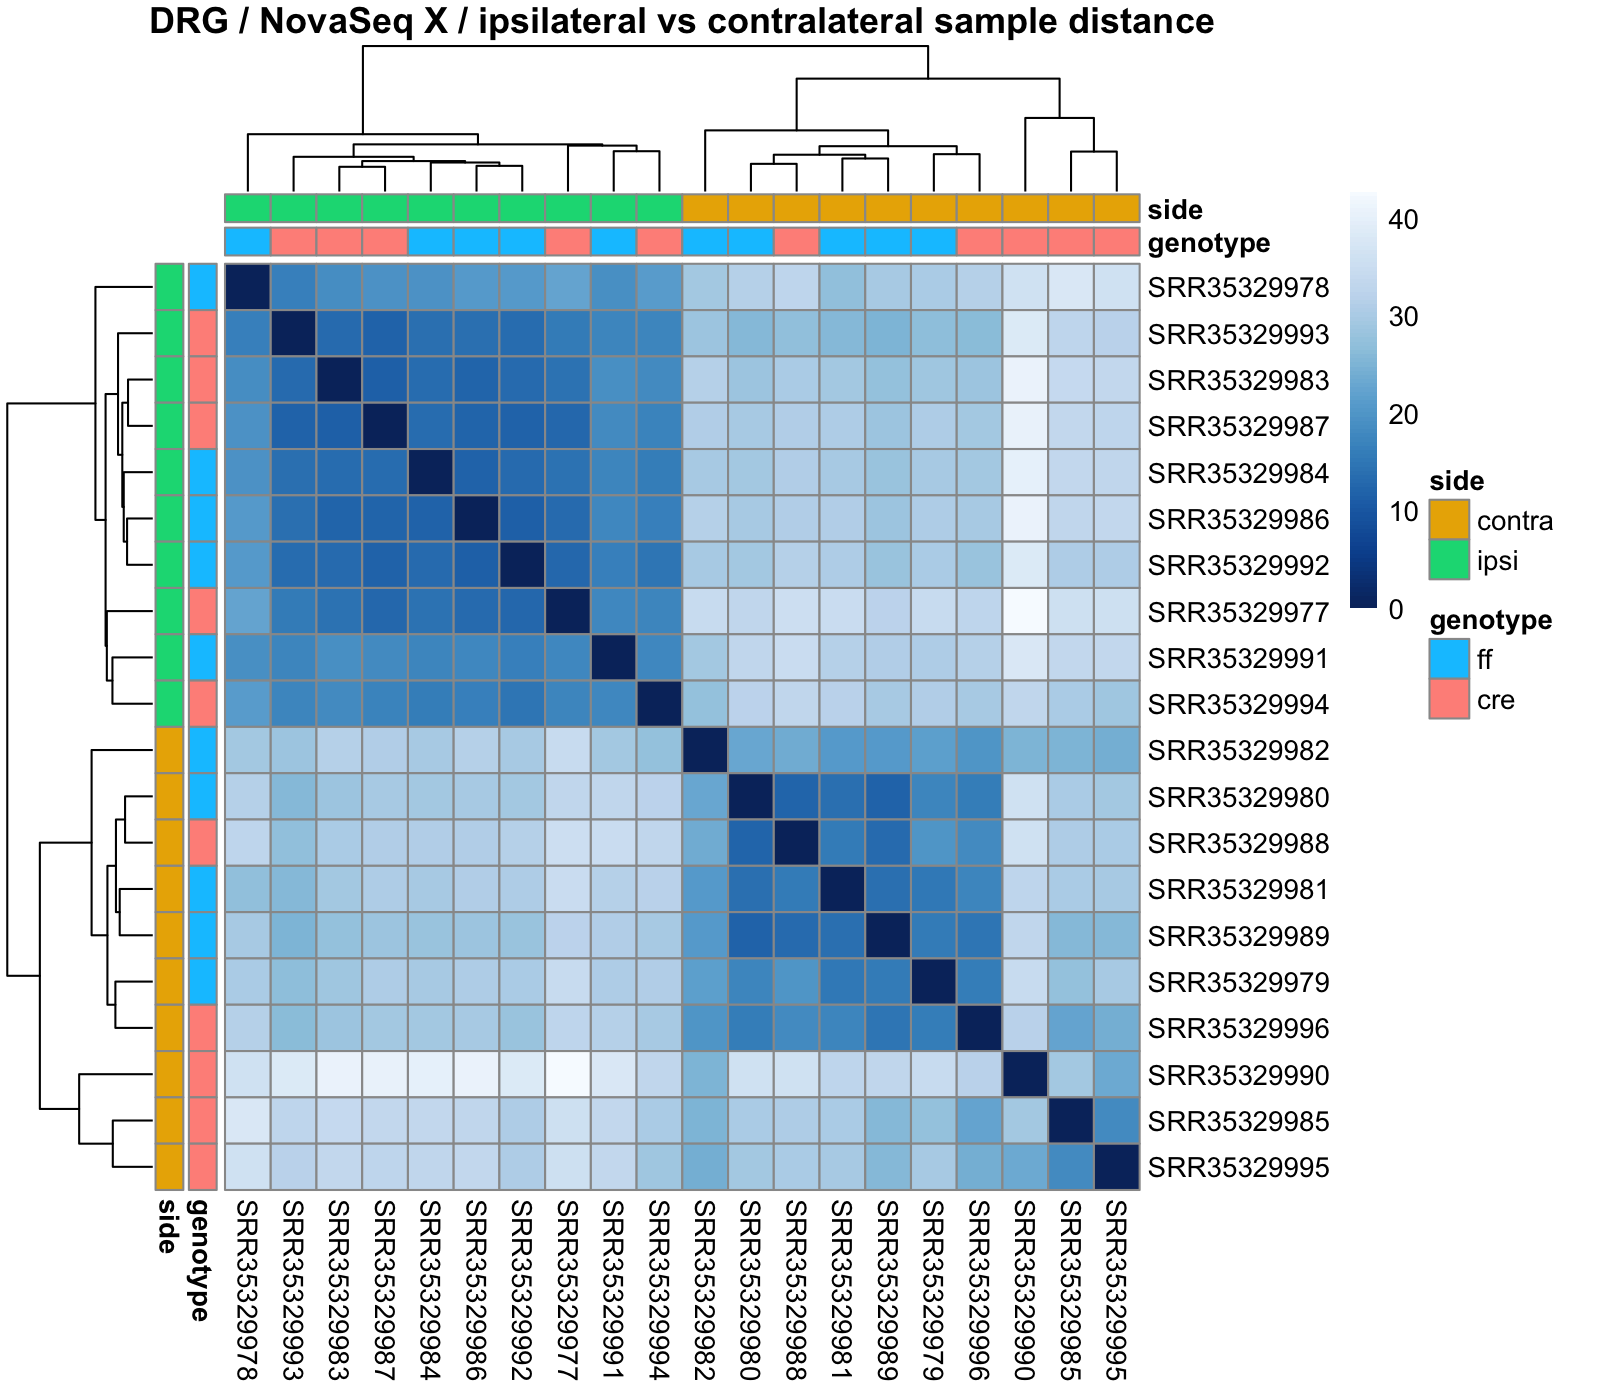

In [12]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'sample_distance_heatmap.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the sample-distance heatmap for `family_drg_novaseqx`.

**How we did it:** Loaded the saved family-level heatmap generated from the variance-stabilized count matrix.

**What the output means:** This heatmap checks whether samples inside the DRG family behave coherently and whether there are any obvious outliers or broken replicate relationships.

**Interpretation:** The heatmap supports the same hierarchy seen in the PCA: the family is coherent, and side drives the main separation more strongly than genotype. **What this means for the next step:** The notebook can move from family diagnostics into the contrast-level outputs with the DRG family treated as a valid main analysis block.


## Representative contrast outputs

This section shows the main side-specific contrasts first and then one smaller supporting genotype contrast.

Why we included this:
- to connect the family-level design to specific DE contrasts
- to show where the strongest gene-level signal actually appears
- to keep the local notebook aligned with the team walkthrough while still preserving the richer local interpretation


## DRG / NovaSeq X / ipsilateral vs contralateral — ipsi_vs_contra_in_ff


### Full result table preview — `ipsi_vs_contra_in_ff`


In [13]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'ipsi_vs_contra_in_ff')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the first rows of the full DE table for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the full results table written by the pipeline for this contrast and previewed the top rows.

**What the output means:** Each row is a gene. `baseMean` is the average normalized expression, `log2FoldChange` is the effect size, and `padj` is the adjusted significance value.

**Interpretation:** This table is the gene-level source behind one of the two dominant notebook results: 7,023 significant genes out of 21,466 tested in `ipsi_vs_contra_in_ff`. **What this means for the next step:** This is one of the central contrast tables behind the main paper story.


### Significant hits preview — `ipsi_vs_contra_in_ff`


In [14]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the significant-hits table for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the filtered significant results table for this contrast and previewed the top rows.

**What the output means:** This is the subset of genes that passed the adjusted-significance threshold for the FF side comparison.

**Interpretation:** This table isolates the 7,023 significant genes in `ipsi_vs_contra_in_ff`. **What this means for the next step:** These rows are the direct source for named examples when we discuss the FF side-specific signal.


### Volcano plot — `ipsi_vs_contra_in_ff`



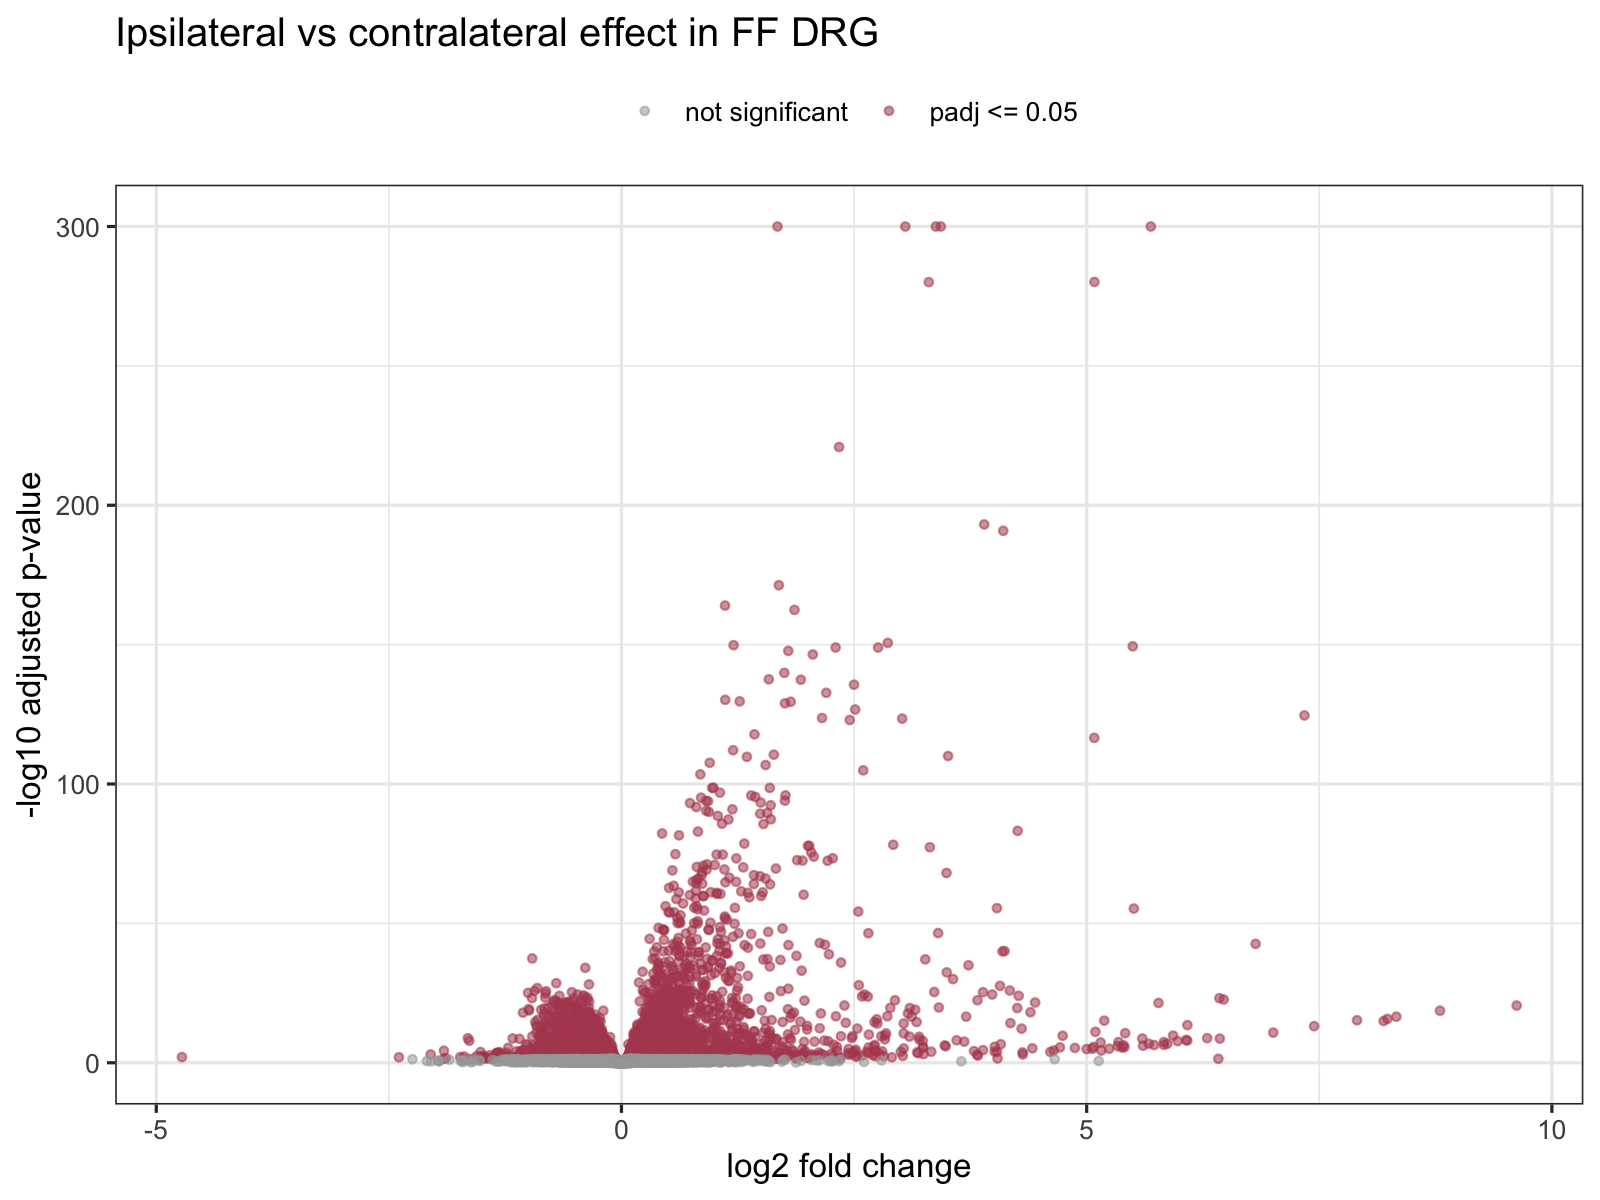
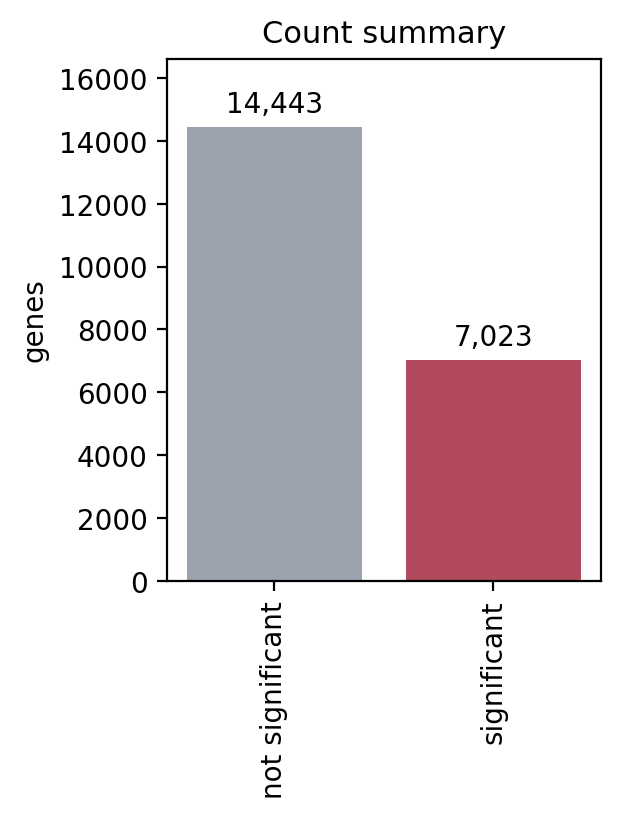

In [15]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for this contrast.

**What the output means:** Genes farther from zero have larger fold changes, and genes higher on the plot have stronger statistical support.

**Interpretation:** In this volcano plot, 7,023 genes are significant and 14,443 are not. That makes this one of the two headline DE signals in the notebook. **What this means for the next step:** This should stay in the central figure set for Draft 1.


## DRG / NovaSeq X / ipsilateral vs contralateral — ipsi_vs_contra_in_cre


### Full result table preview — `ipsi_vs_contra_in_cre`


In [16]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'ipsi_vs_contra_in_cre')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the first rows of the full DE table for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the full results table written by the pipeline for this side-specific contrast and previewed the top rows.

**What the output means:** This table shows the gene-level DE results for the CRE side comparison.

**Interpretation:** This table shows that `ipsi_vs_contra_in_cre` has 7,541 significant genes out of 21,466 tested, making it the strongest single contrast in the package. **What this means for the next step:** This belongs beside `ipsi_vs_contra_in_ff` as the other main contrast in the paper story.


### Significant hits preview — `ipsi_vs_contra_in_cre`


In [17]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the significant-hits table for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the filtered significant results table for this side-specific contrast and previewed the top rows.

**What the output means:** This table isolates the genes that remain significant in the CRE side comparison.

**Interpretation:** This table isolates the 7,541 significant genes in `ipsi_vs_contra_in_cre`, confirming that the CRE side-specific signal is also a main result rather than a secondary one. **What this means for the next step:** These rows are the direct source for named examples from the CRE side-specific signal.


### Volcano plot — `ipsi_vs_contra_in_cre`



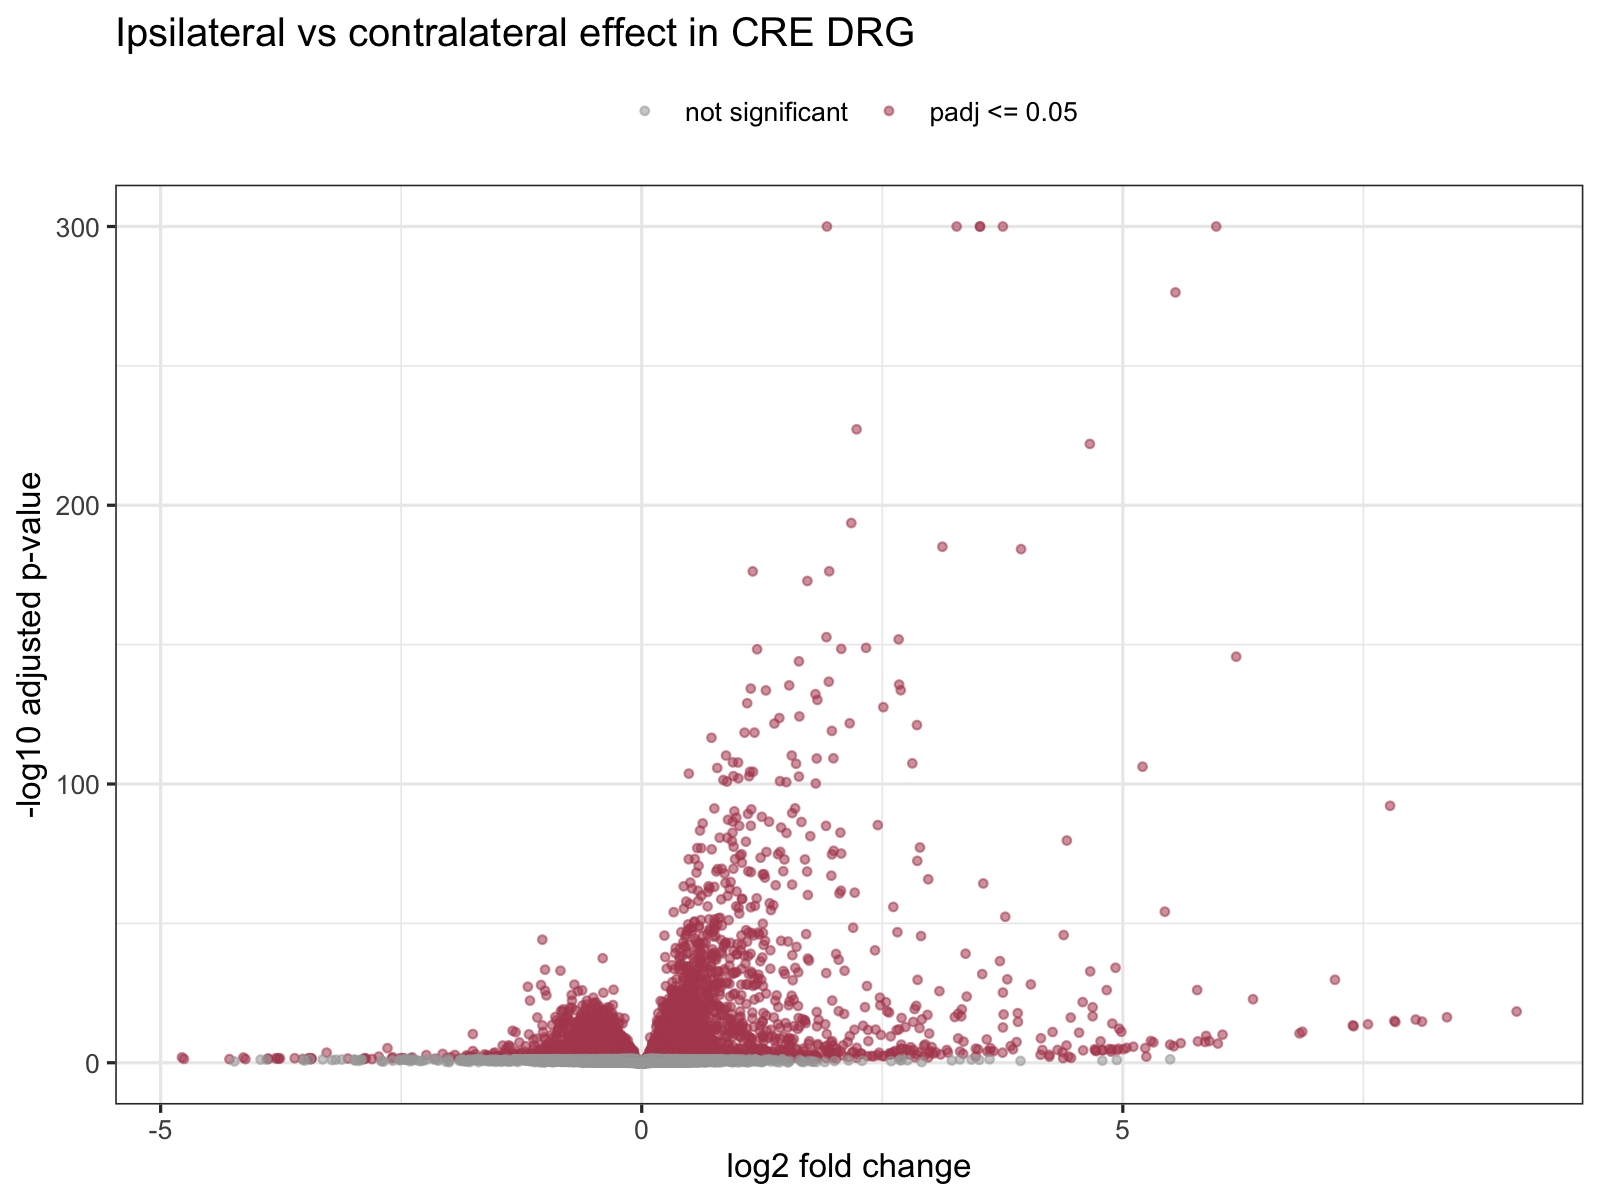
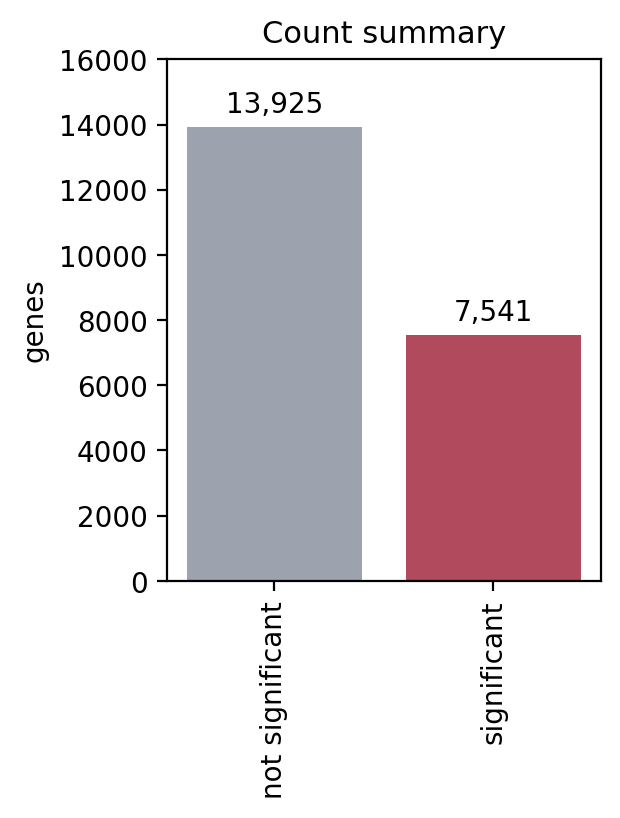

In [18]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for this side-specific contrast.

**What the output means:** This plot shows the strength and breadth of the CRE side-specific signal.

**Interpretation:** In this volcano plot, 7,541 genes are significant and 13,925 are not. That makes it one of the two headline figures in the notebook, not a supporting-only result. **What this means for the next step:** This should stay in the main Draft 1 figure set with the matching FF contrast.


## DRG / NovaSeq X / genotype effect — `geno_in_contra`


### Full result table preview — `geno_in_contra`


In [19]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'geno_in_contra')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the first rows of the full DE table for `geno_in_contra`.

**How we did it:** Loaded the full results table written by the pipeline for the contralateral genotype contrast and previewed the top rows.

**What the output means:** This table shows the gene-level DE results for the genotype effect in contralateral DRG.

**Interpretation:** This table shows that `geno_in_contra` has 891 significant genes out of 21,466 tested. That is a real supporting signal, but it is much smaller than the two side-specific contrasts. **What this means for the next step:** This result is strong enough to keep as supporting evidence without competing with the main paper center.


### Significant hits preview — `geno_in_contra`


In [20]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the significant-hits table for `geno_in_contra`.

**How we did it:** Loaded the filtered significant results table for the contralateral genotype contrast and previewed the top rows.

**What the output means:** This table isolates the genes that remain significant in the genotype comparison on the contralateral side.

**Interpretation:** This table isolates the 891 significant genes in `geno_in_contra`, confirming that the contralateral genotype effect is a usable supporting result. **What this means for the next step:** These rows give us named genotype-support examples if we want one smaller secondary result in the paper.


### Volcano plot — `geno_in_contra`



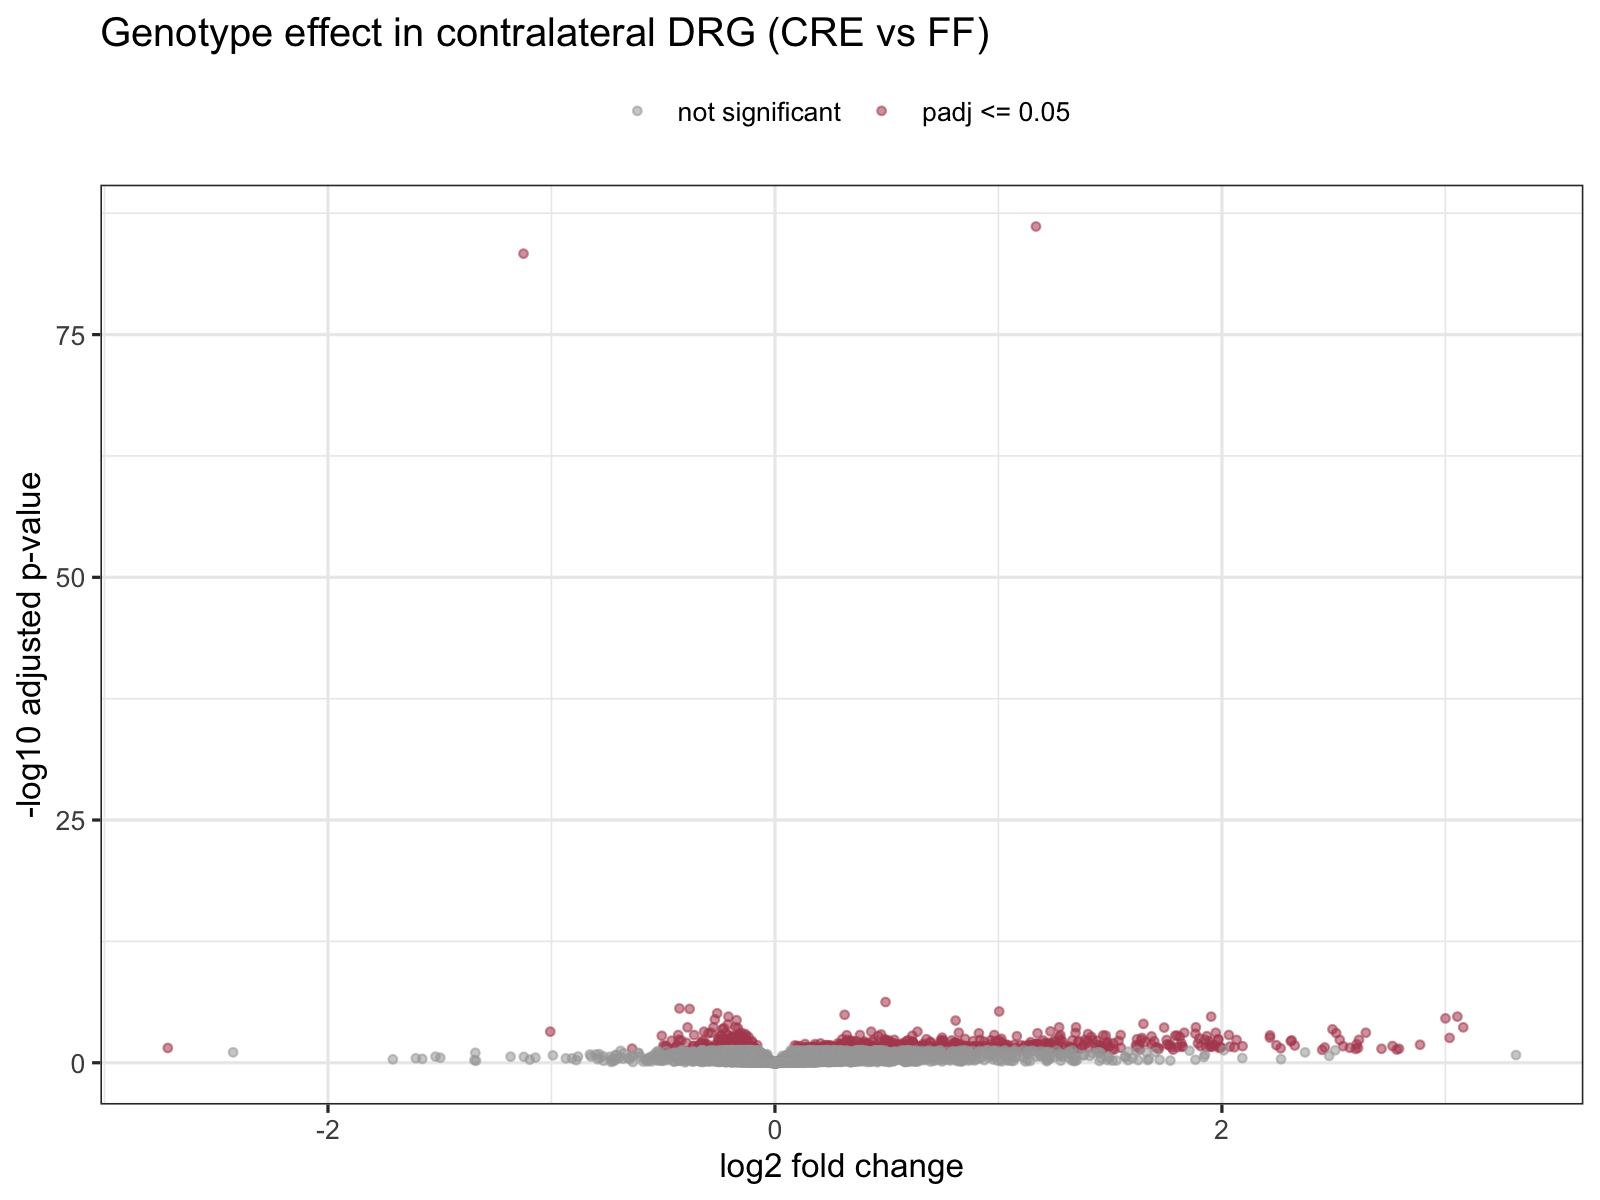
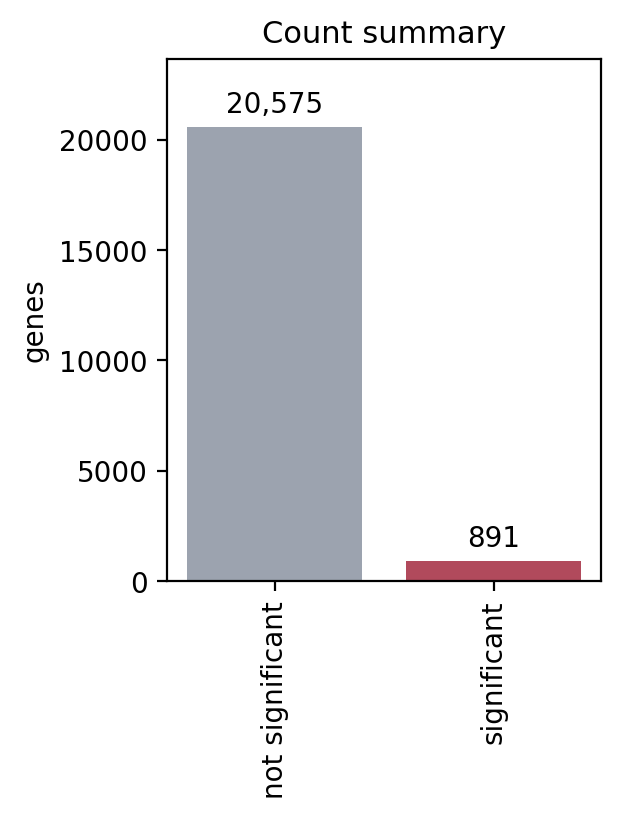

In [21]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `geno_in_contra`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for the contralateral genotype contrast.

**What the output means:** This plot shows whether the genotype effect in contralateral DRG is broad and strong or narrower and more modest.

**Interpretation:** In this volcano plot, 891 genes are significant and 20,575 are not. That makes the result clearly real, but still secondary to the two side-specific contrasts. **What this means for the next step:** This plot supports keeping `geno_in_contra` as the strongest secondary contrast in the notebook.


## Shared notebook comparison panels


### `ipsi_vs_contra_in_ff` volcano preview


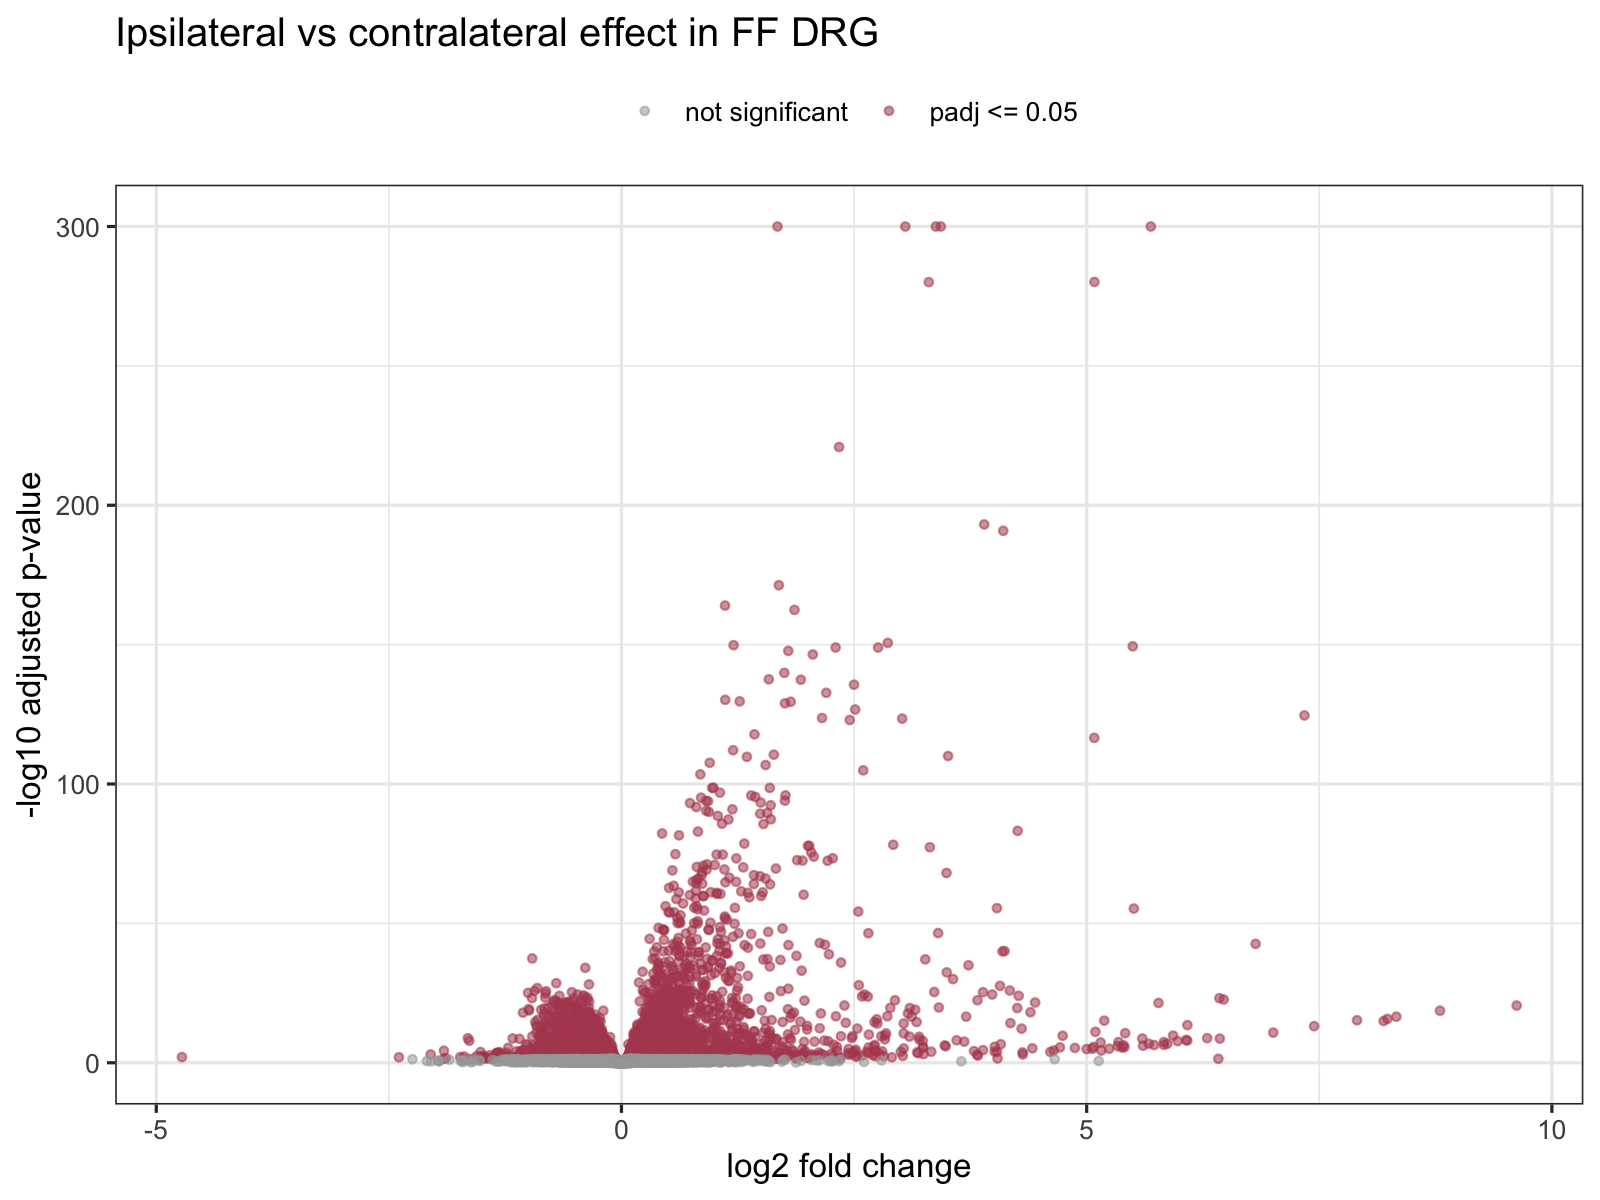

In [22]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_volcano.png'), width=900))


**What we did:** Displayed the `ipsi_vs_contra_in_ff` volcano preview used in the shared team walkthrough.

**How we did it:** Loaded the saved volcano plot directly from the `family_drg_novaseqx/tables/` output bundle.

**What the output means:** This is one of the two dominant side-specific contrasts and one of the quickest visuals for showing the size of the FF signal.

**Interpretation:** This preview belongs in the compact summary because it shows one of the two main paper contrasts immediately. **What this means for the next step:** Use this as one of the first quick-look visuals when summarizing the DE package.


### `ipsi_vs_contra_in_ff` heatmap preview


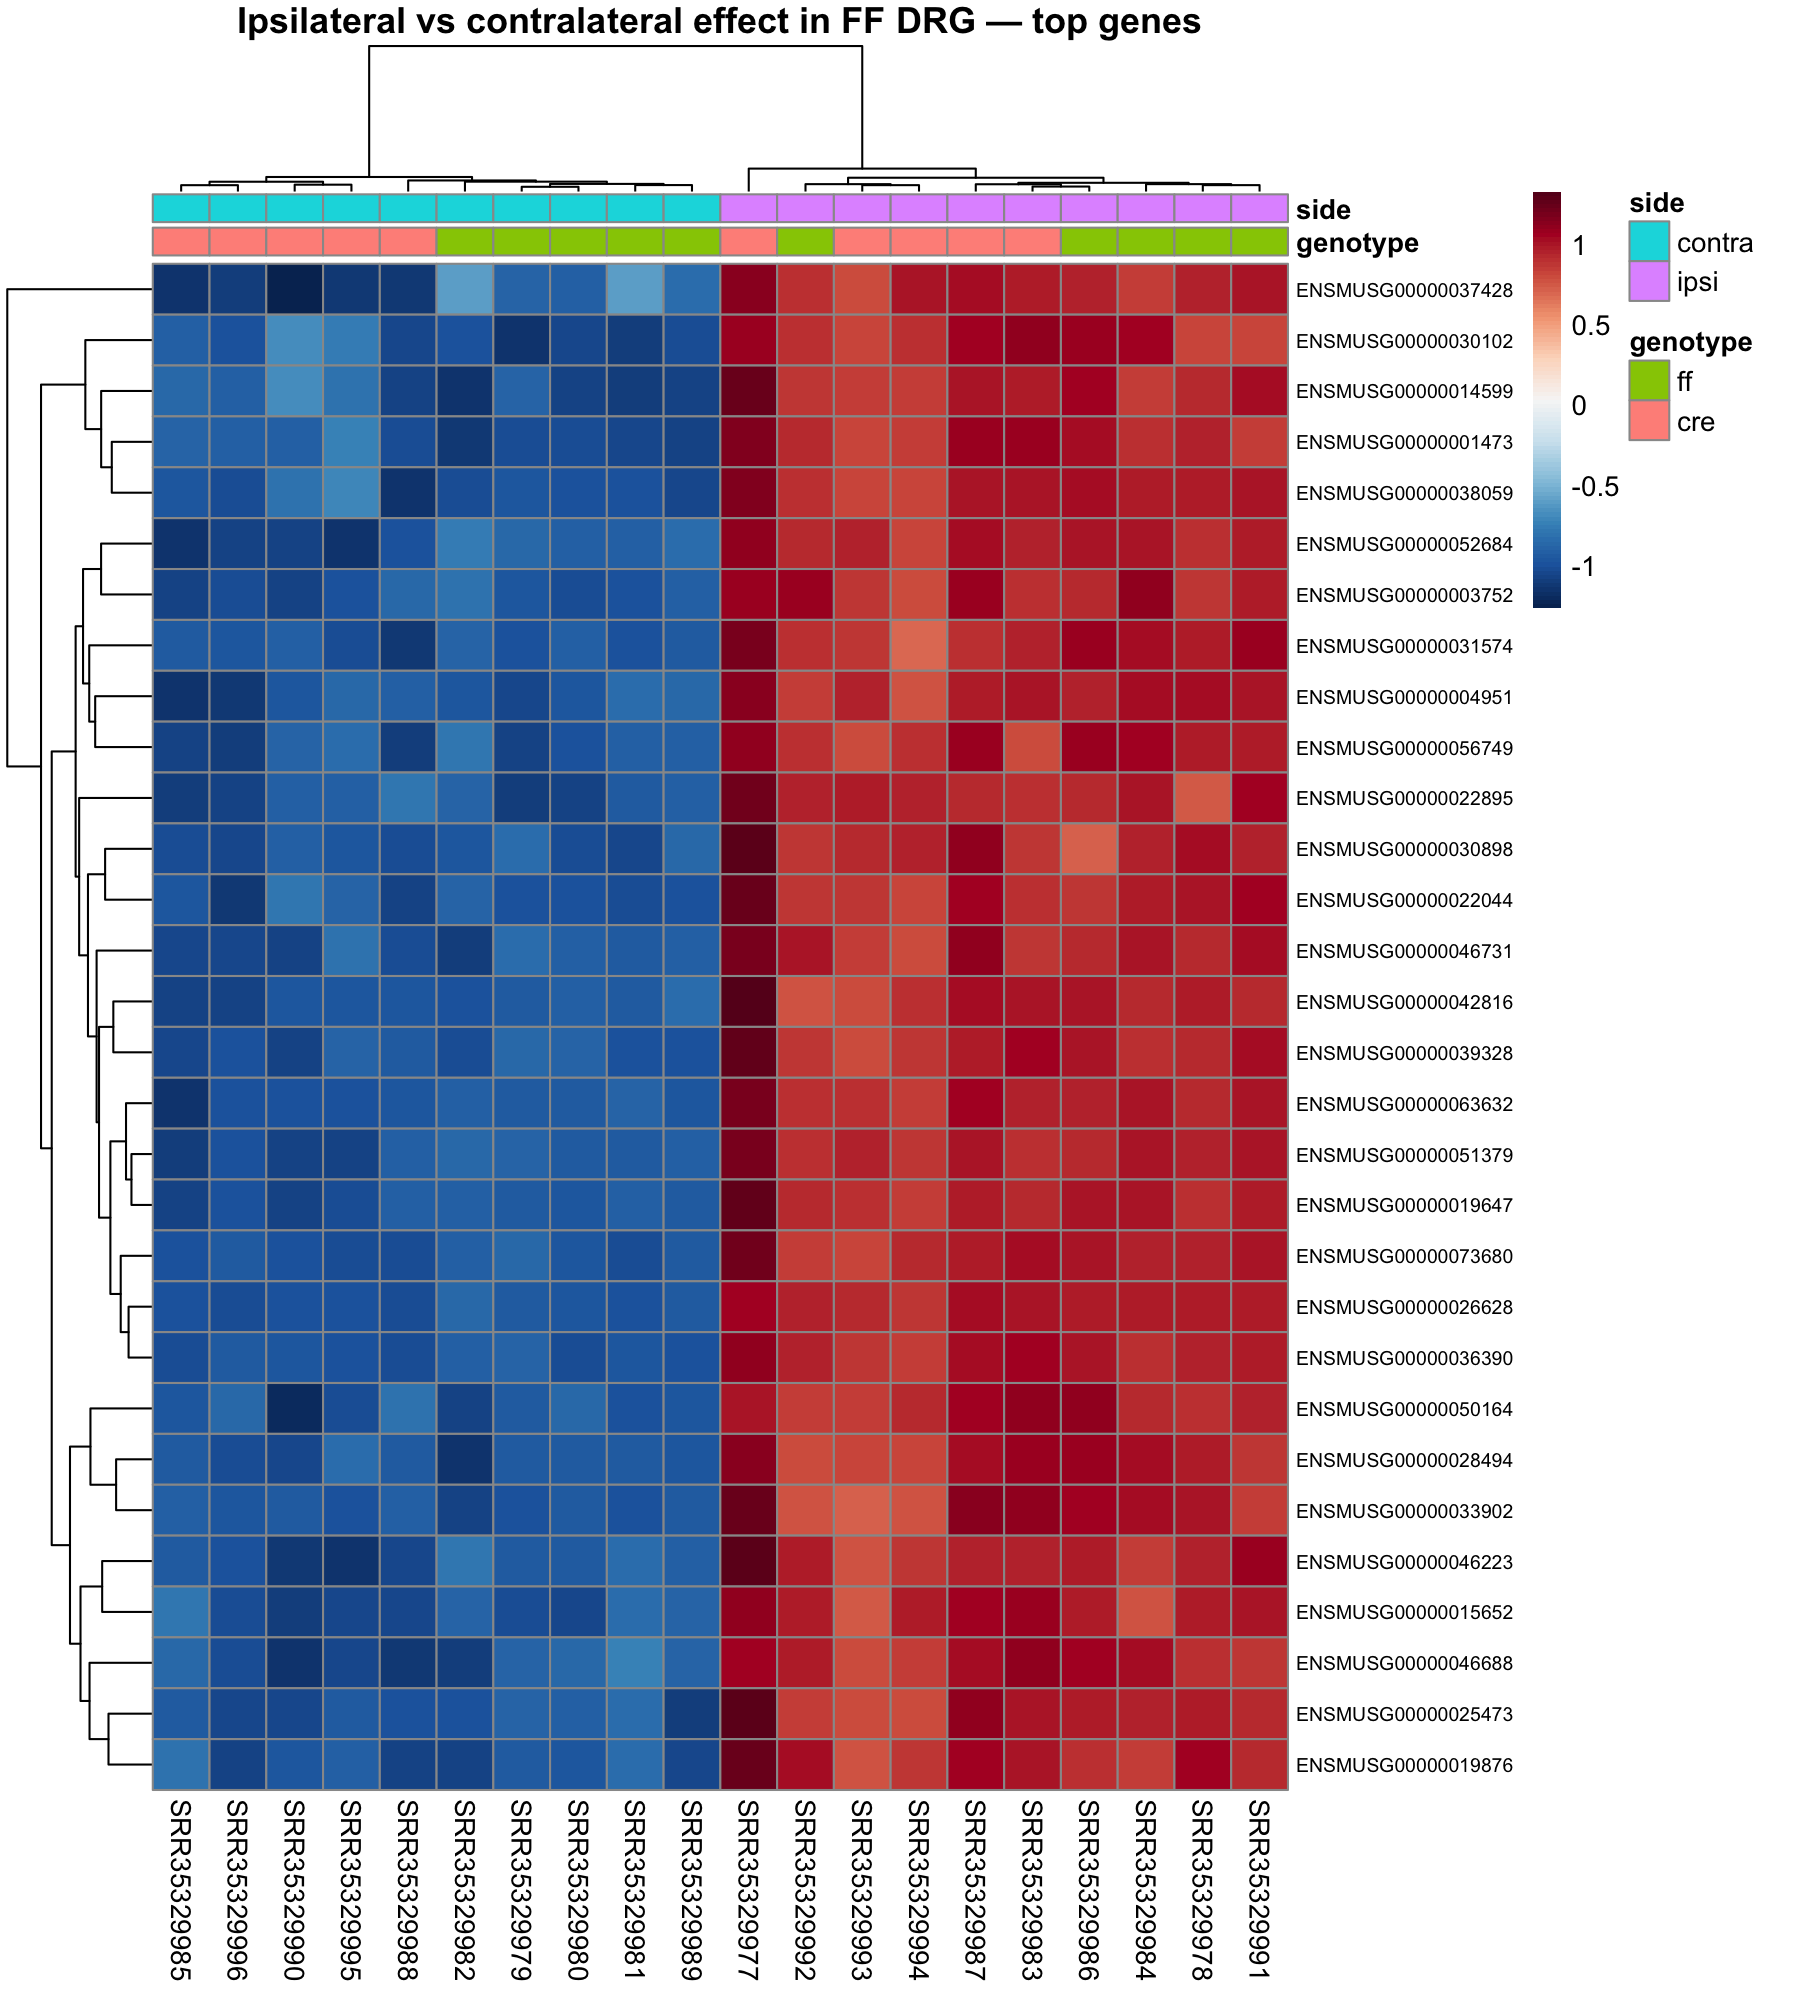

In [23]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_heatmap.png'), width=900))


**What we did:** Displayed the `ipsi_vs_contra_in_ff` heatmap preview used in the shared team walkthrough.

**How we did it:** Loaded the saved heatmap for the FF side-specific contrast from the family tables bundle.

**What the output means:** This heatmap gives a fast view of how the strongest FF contrast separates samples at the gene-pattern level.

**Interpretation:** This preview complements the FF volcano by showing the same dominant contrast as a sample-pattern view. **What this means for the next step:** Keep it paired with the FF volcano when giving a compact summary of the main result.


### `geno_in_contra` volcano preview


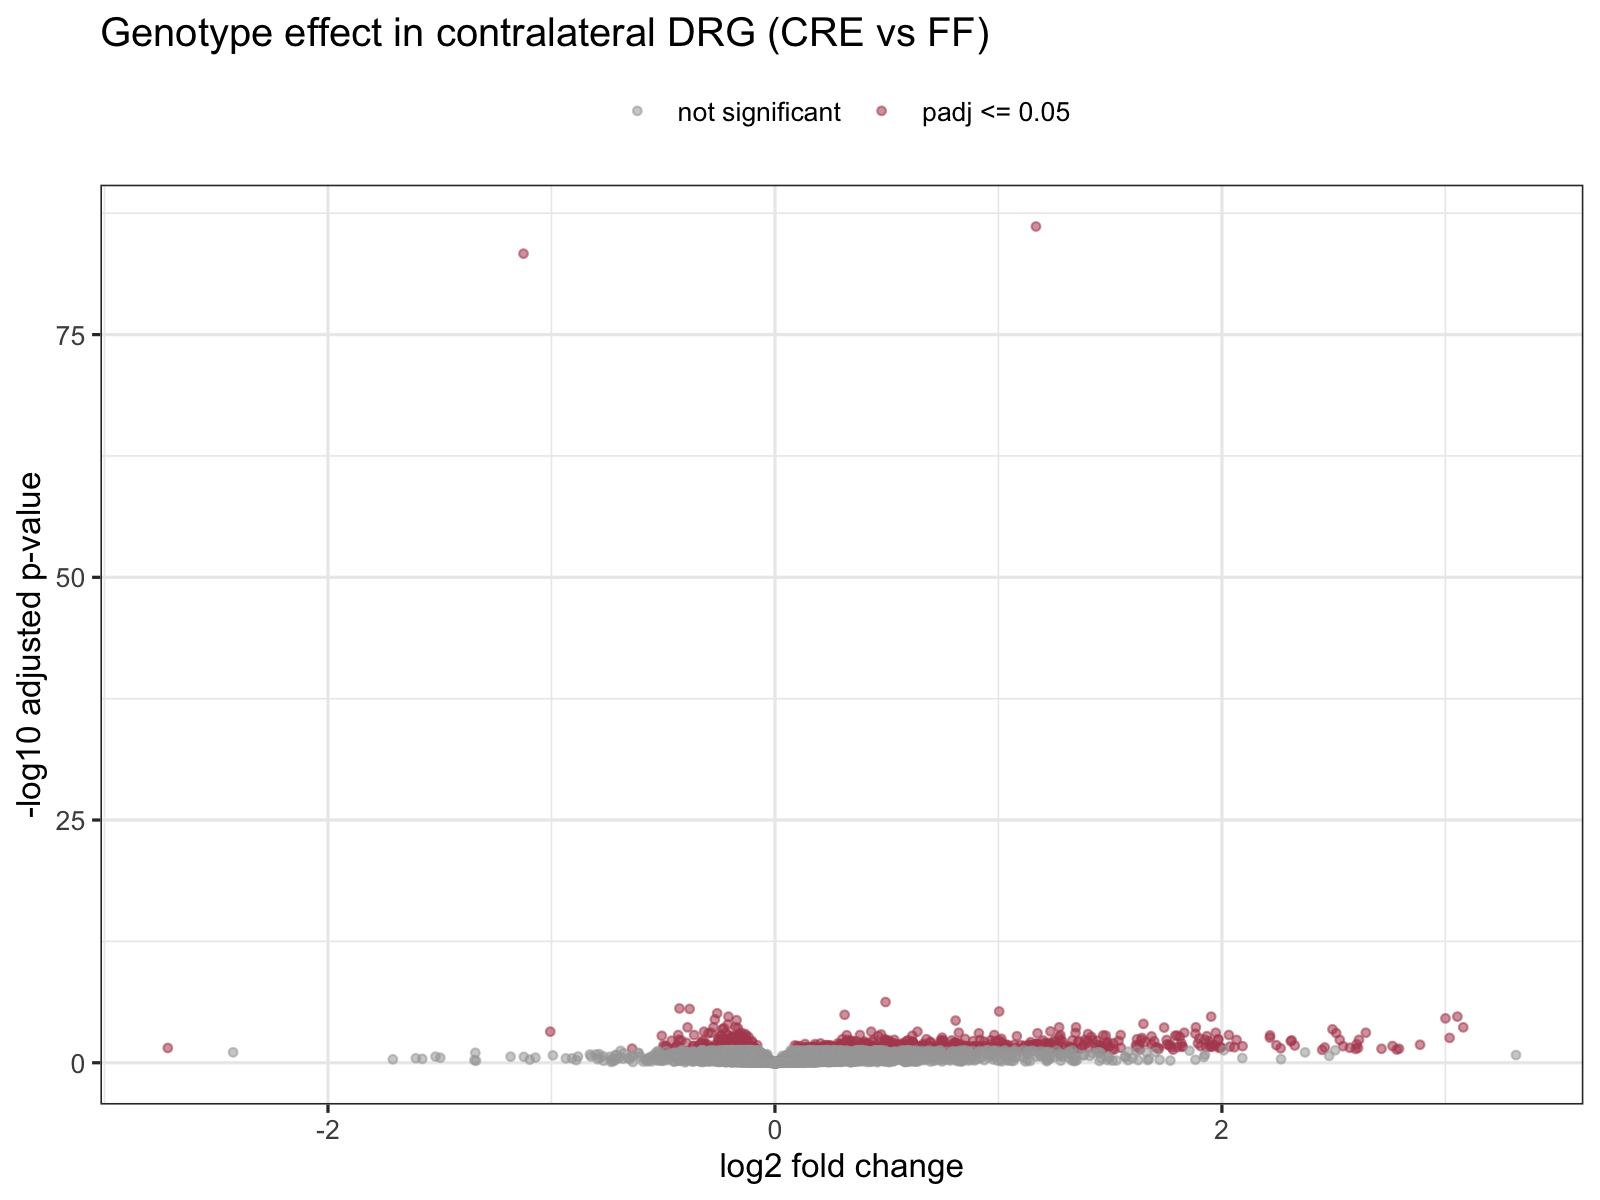

In [24]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'geno_in_contra_volcano.png'), width=900))


**What we did:** Displayed the `geno_in_contra` volcano preview used in the shared team walkthrough.

**How we did it:** Loaded the saved genotype-support volcano directly from the family tables bundle.

**What the output means:** This is the strongest secondary contrast in the package and the most useful compact support panel.

**Interpretation:** This preview shows why `geno_in_contra` is worth keeping as supporting evidence without letting it compete with the side-specific main results. **What this means for the next step:** Use it when a compact notebook summary needs one genotype-support panel.


### `interaction` volcano preview


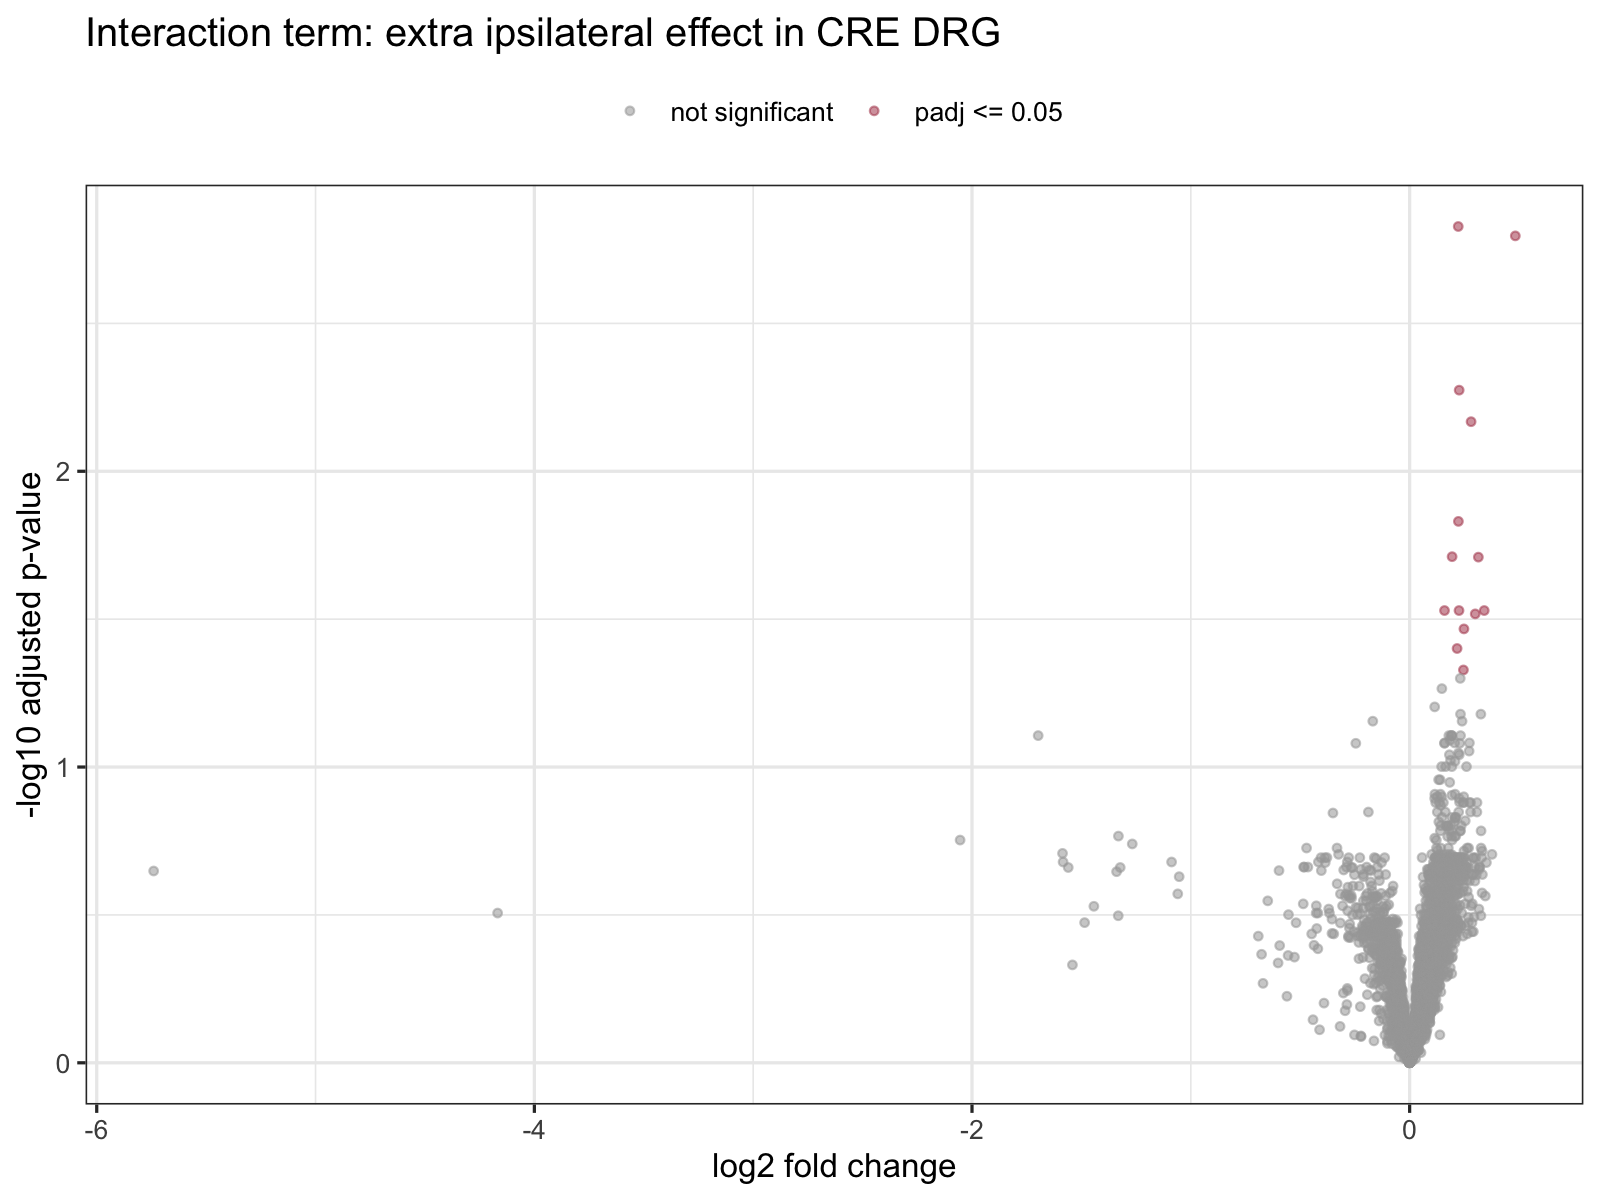

In [25]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'interaction_volcano.png'), width=900))


**What we did:** Displayed the `interaction` volcano preview used in the shared team walkthrough.

**How we did it:** Loaded the saved interaction volcano directly from the family tables bundle.

**What the output means:** This is the smallest contrast in the package and is shown here mainly to complete the compact comparison set.

**Interpretation:** The interaction preview stays in the notebook as context, but it should remain minor compared with the two side-specific contrasts and `geno_in_contra`. **What this means for the next step:** Treat this as a small supporting panel only.


### Top genes preview — `ipsi_vs_contra_in_ff`


In [26]:
display(pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_top_genes.tsv', sep='	').head(20))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the top-gene preview for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the saved `ipsi_vs_contra_in_ff_top_genes.tsv` table and previewed the first 20 rows.

**What the output means:** This is the quickest named-gene table for the FF main contrast.

**Interpretation:** This preview is one of the first places to pull named genes when discussing the FF side-specific signal in Draft 1. **What this means for the next step:** Use it as a direct source for gene examples tied to the FF main result.


### Top genes preview — `ipsi_vs_contra_in_cre`


In [27]:
display(pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_cre_top_genes.tsv', sep='	').head(20))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the top-gene preview for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the saved `ipsi_vs_contra_in_cre_top_genes.tsv` table and previewed the first 20 rows.

**What the output means:** This is the matching named-gene table for the CRE main contrast.

**Interpretation:** This preview lines up with the second main side-specific contrast and should be used beside the FF table when naming genes from the main paper story. **What this means for the next step:** Use it as the CRE counterpart to the FF top-gene table in Draft 1.


## Transcript-driven plan (this week)

In [28]:
display(pd.read_csv(DERIVED_DIR / 'analysis_summary.tsv', sep='\t'))

,contrast_id,analysis_focus,significant_padj_lt_0_05,bendpoint_selected,bendpoint_threshold
0,ipsi_vs_contra_in_ff,main_side_specific,7023,709,1.374018e-17
1,ipsi_vs_contra_in_cre,main_side_specific,7541,870,8.396838e-17
2,geno_in_contra,genotype,891,267,2.134600e-04
3,geno_in_ipsi,genotype,2,113,1.434321e-02
4,interaction,interaction,14,1823,4.564824e-02


**What we did:** Loaded the transcript-driven derived-analysis summary table for all five exported contrasts.

**Why it matters:** This keeps the whole week’s plan visible in one place before we inspect individual artifacts. The summary now includes bend-point counts and thresholds for the side-specific contrasts, the two genotype contrasts, and the interaction contrast.

## Method: cumulative p-value bend-point

In [29]:
display(pd.concat([
    pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'bendpoint_summary.tsv', sep='\t'),
    pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'bendpoint_summary.tsv', sep='\t'),
    pd.read_csv(DERIVED_DIR / 'geno_in_contra' / 'bendpoint_summary.tsv', sep='\t'),
    pd.read_csv(DERIVED_DIR / 'geno_in_ipsi' / 'bendpoint_summary.tsv', sep='\t'),
    pd.read_csv(DERIVED_DIR / 'interaction' / 'bendpoint_summary.tsv', sep='\t'),
], ignore_index=True))

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,ipsi_vs_contra_in_ff,21466,7023,1.374018e-17,709
1,ipsi_vs_contra_in_cre,21466,7541,8.396838e-17,870
2,geno_in_contra,21466,891,2.134600e-04,267
3,geno_in_ipsi,21466,2,1.434321e-02,113
4,interaction,21466,14,4.564824e-02,1823


**What we did:** Loaded the bend-point summaries for every contrast we are considering this week.

**Why it matters:** The bend-point method orders genes by `pvalue`, finds an elbow-style transition in that ordered curve, and uses that threshold to define a less-arbitrary follow-up gene set than a fixed top-`100` or padj-only rule.

## Outputs produced (files + where they live)

In [30]:
from pathlib import Path
outputs_index = pd.DataFrame({
    'artifact_group': [
        'analysis_summary', 'main_ff', 'main_cre', 'geno_in_contra', 'geno_in_ipsi', 'interaction', 'genotype_comparison'
    ],
    'path': [
        str(DERIVED_DIR / 'analysis_summary.tsv'),
        str(DERIVED_DIR / 'ipsi_vs_contra_in_ff'),
        str(DERIVED_DIR / 'ipsi_vs_contra_in_cre'),
        str(DERIVED_DIR / 'geno_in_contra'),
        str(DERIVED_DIR / 'geno_in_ipsi'),
        str(DERIVED_DIR / 'interaction'),
        str(DERIVED_DIR / 'genotype_comparison'),
    ]
})
display(outputs_index)

,artifact_group,path
0,analysis_summary,/Users/pitergarcia/DataScience/Semester5/BIOL5...
1,main_ff,/Users/pitergarcia/DataScience/Semester5/BIOL5...
2,main_cre,/Users/pitergarcia/DataScience/Semester5/BIOL5...
3,geno_in_contra,/Users/pitergarcia/DataScience/Semester5/BIOL5...
4,geno_in_ipsi,/Users/pitergarcia/DataScience/Semester5/BIOL5...
5,interaction,/Users/pitergarcia/DataScience/Semester5/BIOL5...
6,genotype_comparison,/Users/pitergarcia/DataScience/Semester5/BIOL5...


**What we did:** Listed the main artifact locations under `mouse_new/differential_expression_all20/derived_analysis/`.

**Why it matters:** This keeps the notebook tied to the actual files on disk so the weekly report can cite a concrete source for each figure, table, and enrichment result.

## Top story selection criteria

- Prefer contrasts where the PCA interpretation and the DE results point in the same direction.
- Prefer contrasts where the bend-point narrowing still leaves a coherent, interpretable follow-up set.
- Prefer enrichment themes that stay biologically readable after filtering, not just statistically large.
- Keep `geno_in_contra` as the strongest secondary branch, but do not let it outrank the side-specific story unless it becomes clearly more coherent across plots, tables, and enrichment.

## Risks & checks

- **PCA sanity check:** the DRG family should still read primarily as a side-driven structure.
- **Volcano sanity check:** the highlighted contrast should still look like a real signal, not a threshold artifact.
- **Enrichment sanity check:** very broad pathway terms can be useful for orientation, but we still need to decide whether they are specific enough for the weekly report.
- **Interaction caution:** the bend-point threshold can produce a large selected set even when the padj-significant set is small, so interaction interpretation should stay cautious until the plots and terms look compelling.

## PCA-first interpretation support

### PCA recap — why side-specific contrasts lead Draft 1

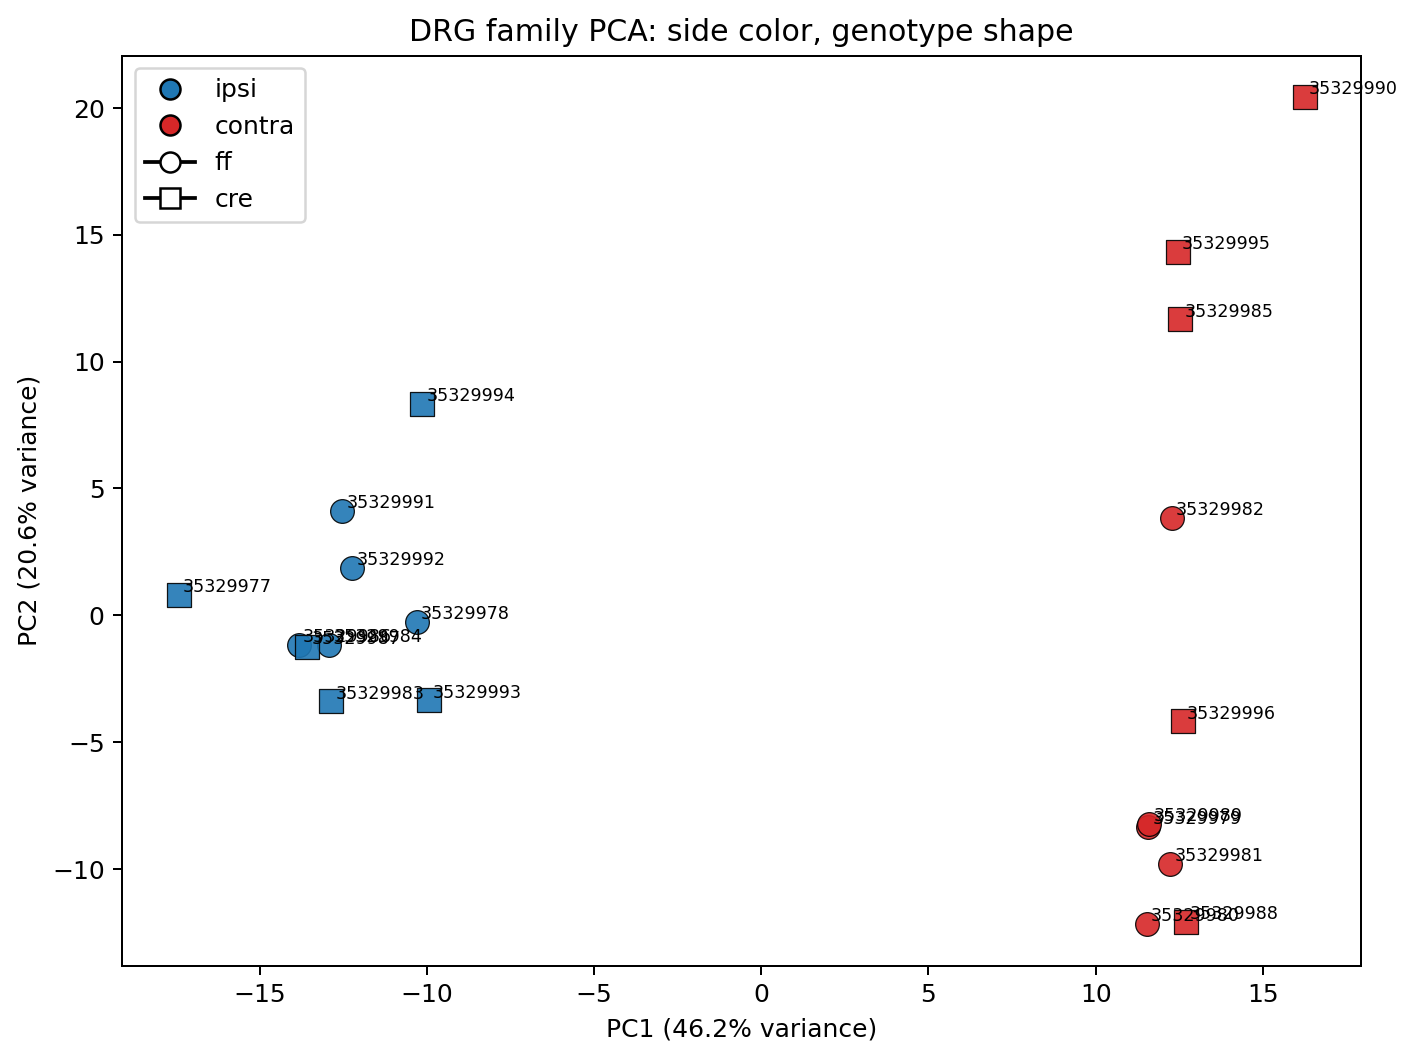

In [31]:
display(Image(filename=str(DERIVED_DIR / 'family_structure' / 'pca_side_genotype_annotated.png'), width=900))

**What we did:** Displayed an annotated PCA with color = `side_class` and shape = `geno_class`.

**Why it matters:** This makes the grouping rule explicit. If earlier PCA reading leaned too heavily on genotype alone, this updated encoding shows that the dominant separation is by side, while genotype appears as a weaker overlay within that side-driven structure.

### Closest `ff` / `cre` PCA collisions

In [32]:
display(pd.read_csv(DERIVED_DIR / 'family_structure' / 'pca_ff_cre_collision_pairs.tsv', sep='\t').head(10))

,side_class,ff_srr,cre_srr,pca_distance
0,ipsi,SRR35329986,SRR35329987,0.272240
1,ipsi,SRR35329984,SRR35329987,0.666371
2,contra,SRR35329980,SRR35329988,1.178849
3,ipsi,SRR35329984,SRR35329983,2.239021
4,contra,SRR35329981,SRR35329988,2.342927
5,ipsi,SRR35329986,SRR35329983,2.438799
6,ipsi,SRR35329978,SRR35329993,3.098920
7,ipsi,SRR35329992,SRR35329987,3.422004
8,ipsi,SRR35329978,SRR35329987,3.423500
9,ipsi,SRR35329984,SRR35329993,3.690469


**What we did:** Listed the closest `ff` / `cre` sample pairs in PCA space within the same side.

**Why it matters:** This gives us a concrete way to talk about where genotype classes collide instead of only saying they overlap by eye. The overlap tells us genotype is present but weaker than the side-driven structure, not that genotype is absent.

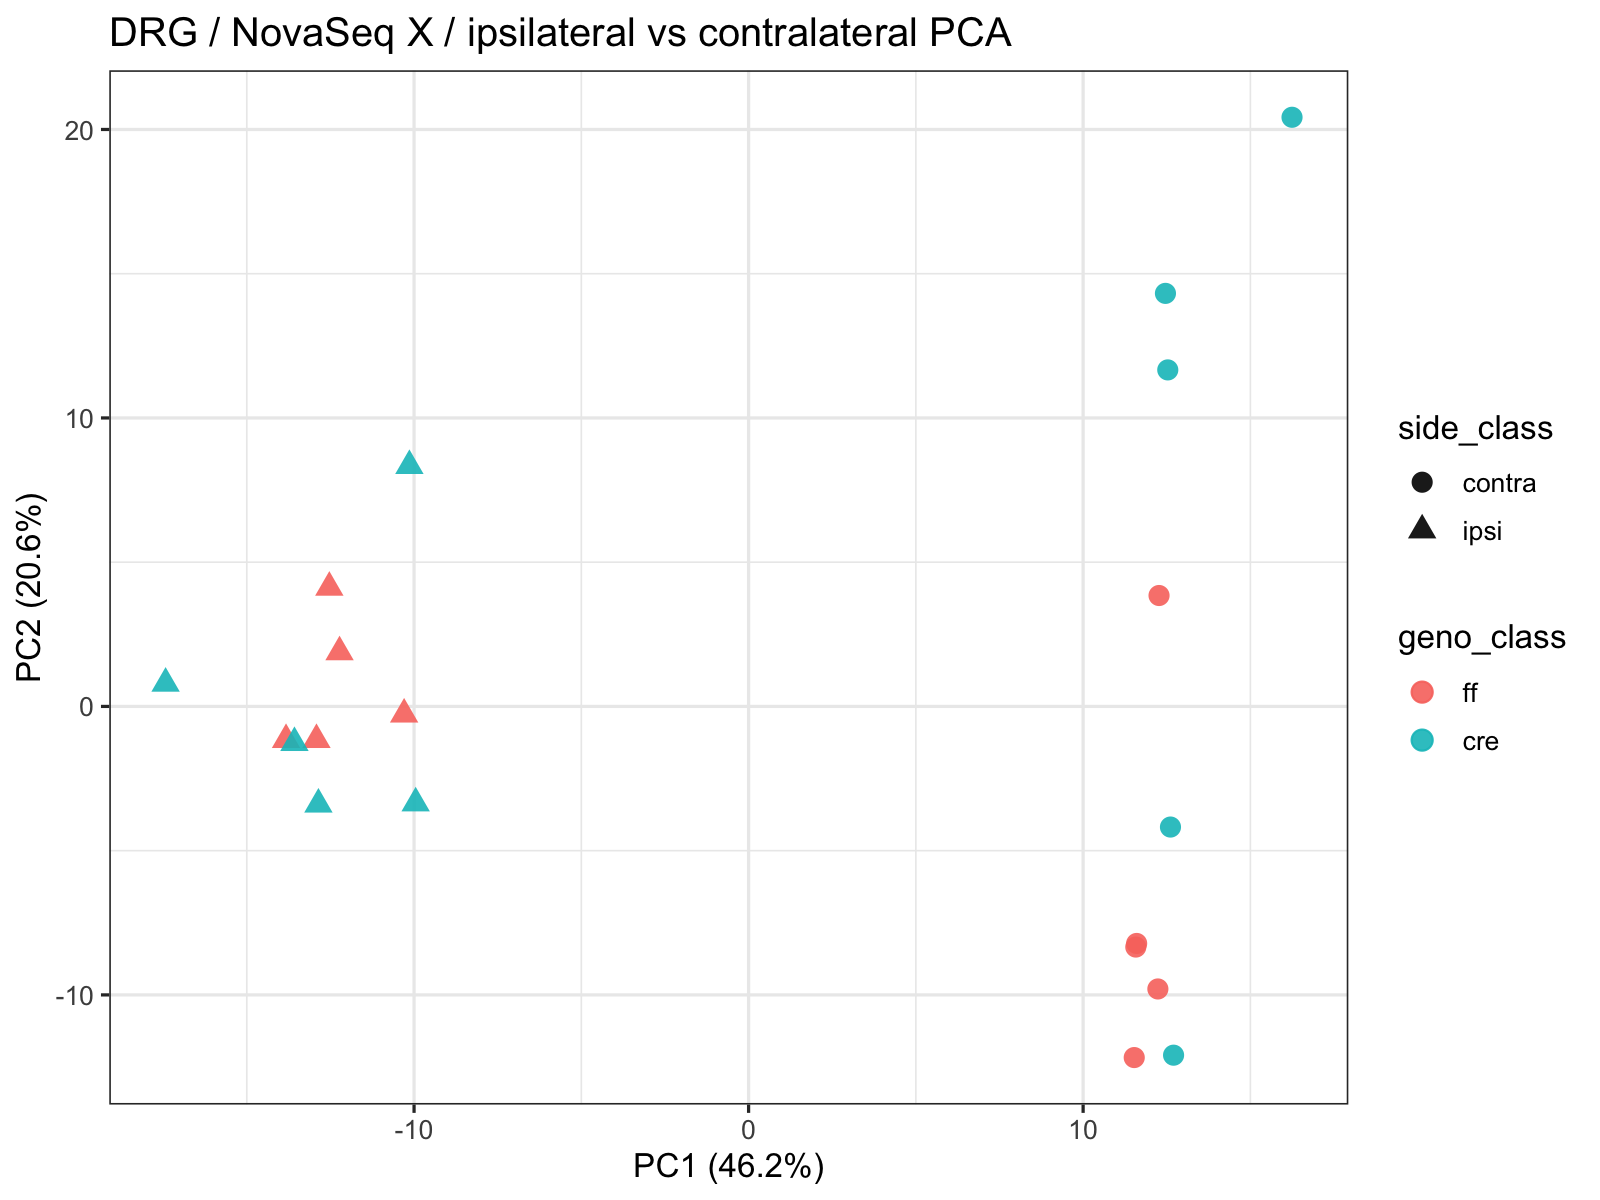

In [33]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'pca.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')

**What we did:** Re-displayed the DRG family PCA as the first interpretation checkpoint for Draft 1.

**Why it matters:** The transcript-guided reading is that `side_class` is the dominant visible separation in the family, which supports leading the paper with the side-specific contrasts before diving into large gene lists.

## Cumulative / bend-point filtering for the main side-specific contrasts

### Standalone volcano + count view — `ipsi_vs_contra_in_ff`


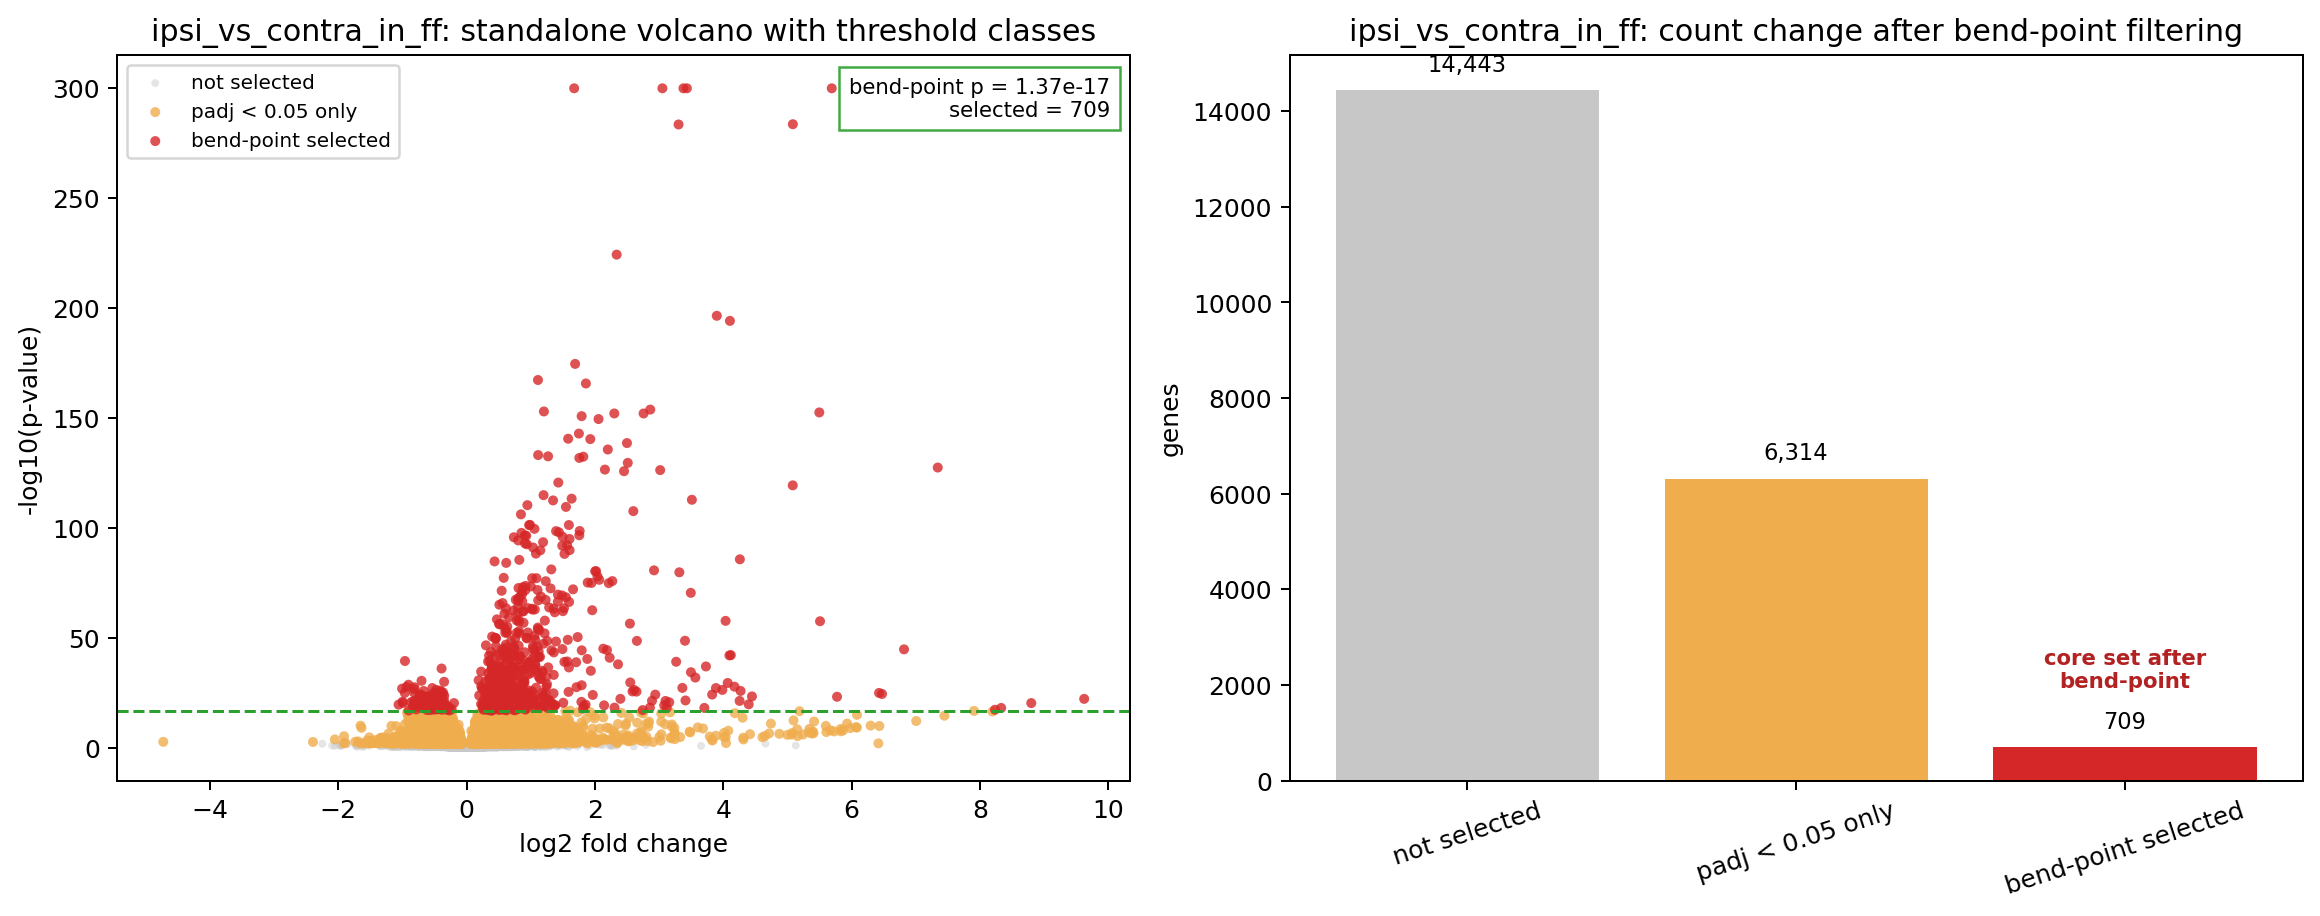

In [34]:
display(HTML((DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'volcano_with_counts.html').read_text()))

**What we did:** Displayed the standalone volcano and count breakdown for `ipsi_vs_contra_in_ff`.

**Why it matters:** This standalone view keeps the focus on the raw DE result itself before we compare how the bend-point threshold changes that view.

### Ordered p-value curve — `ipsi_vs_contra_in_ff`

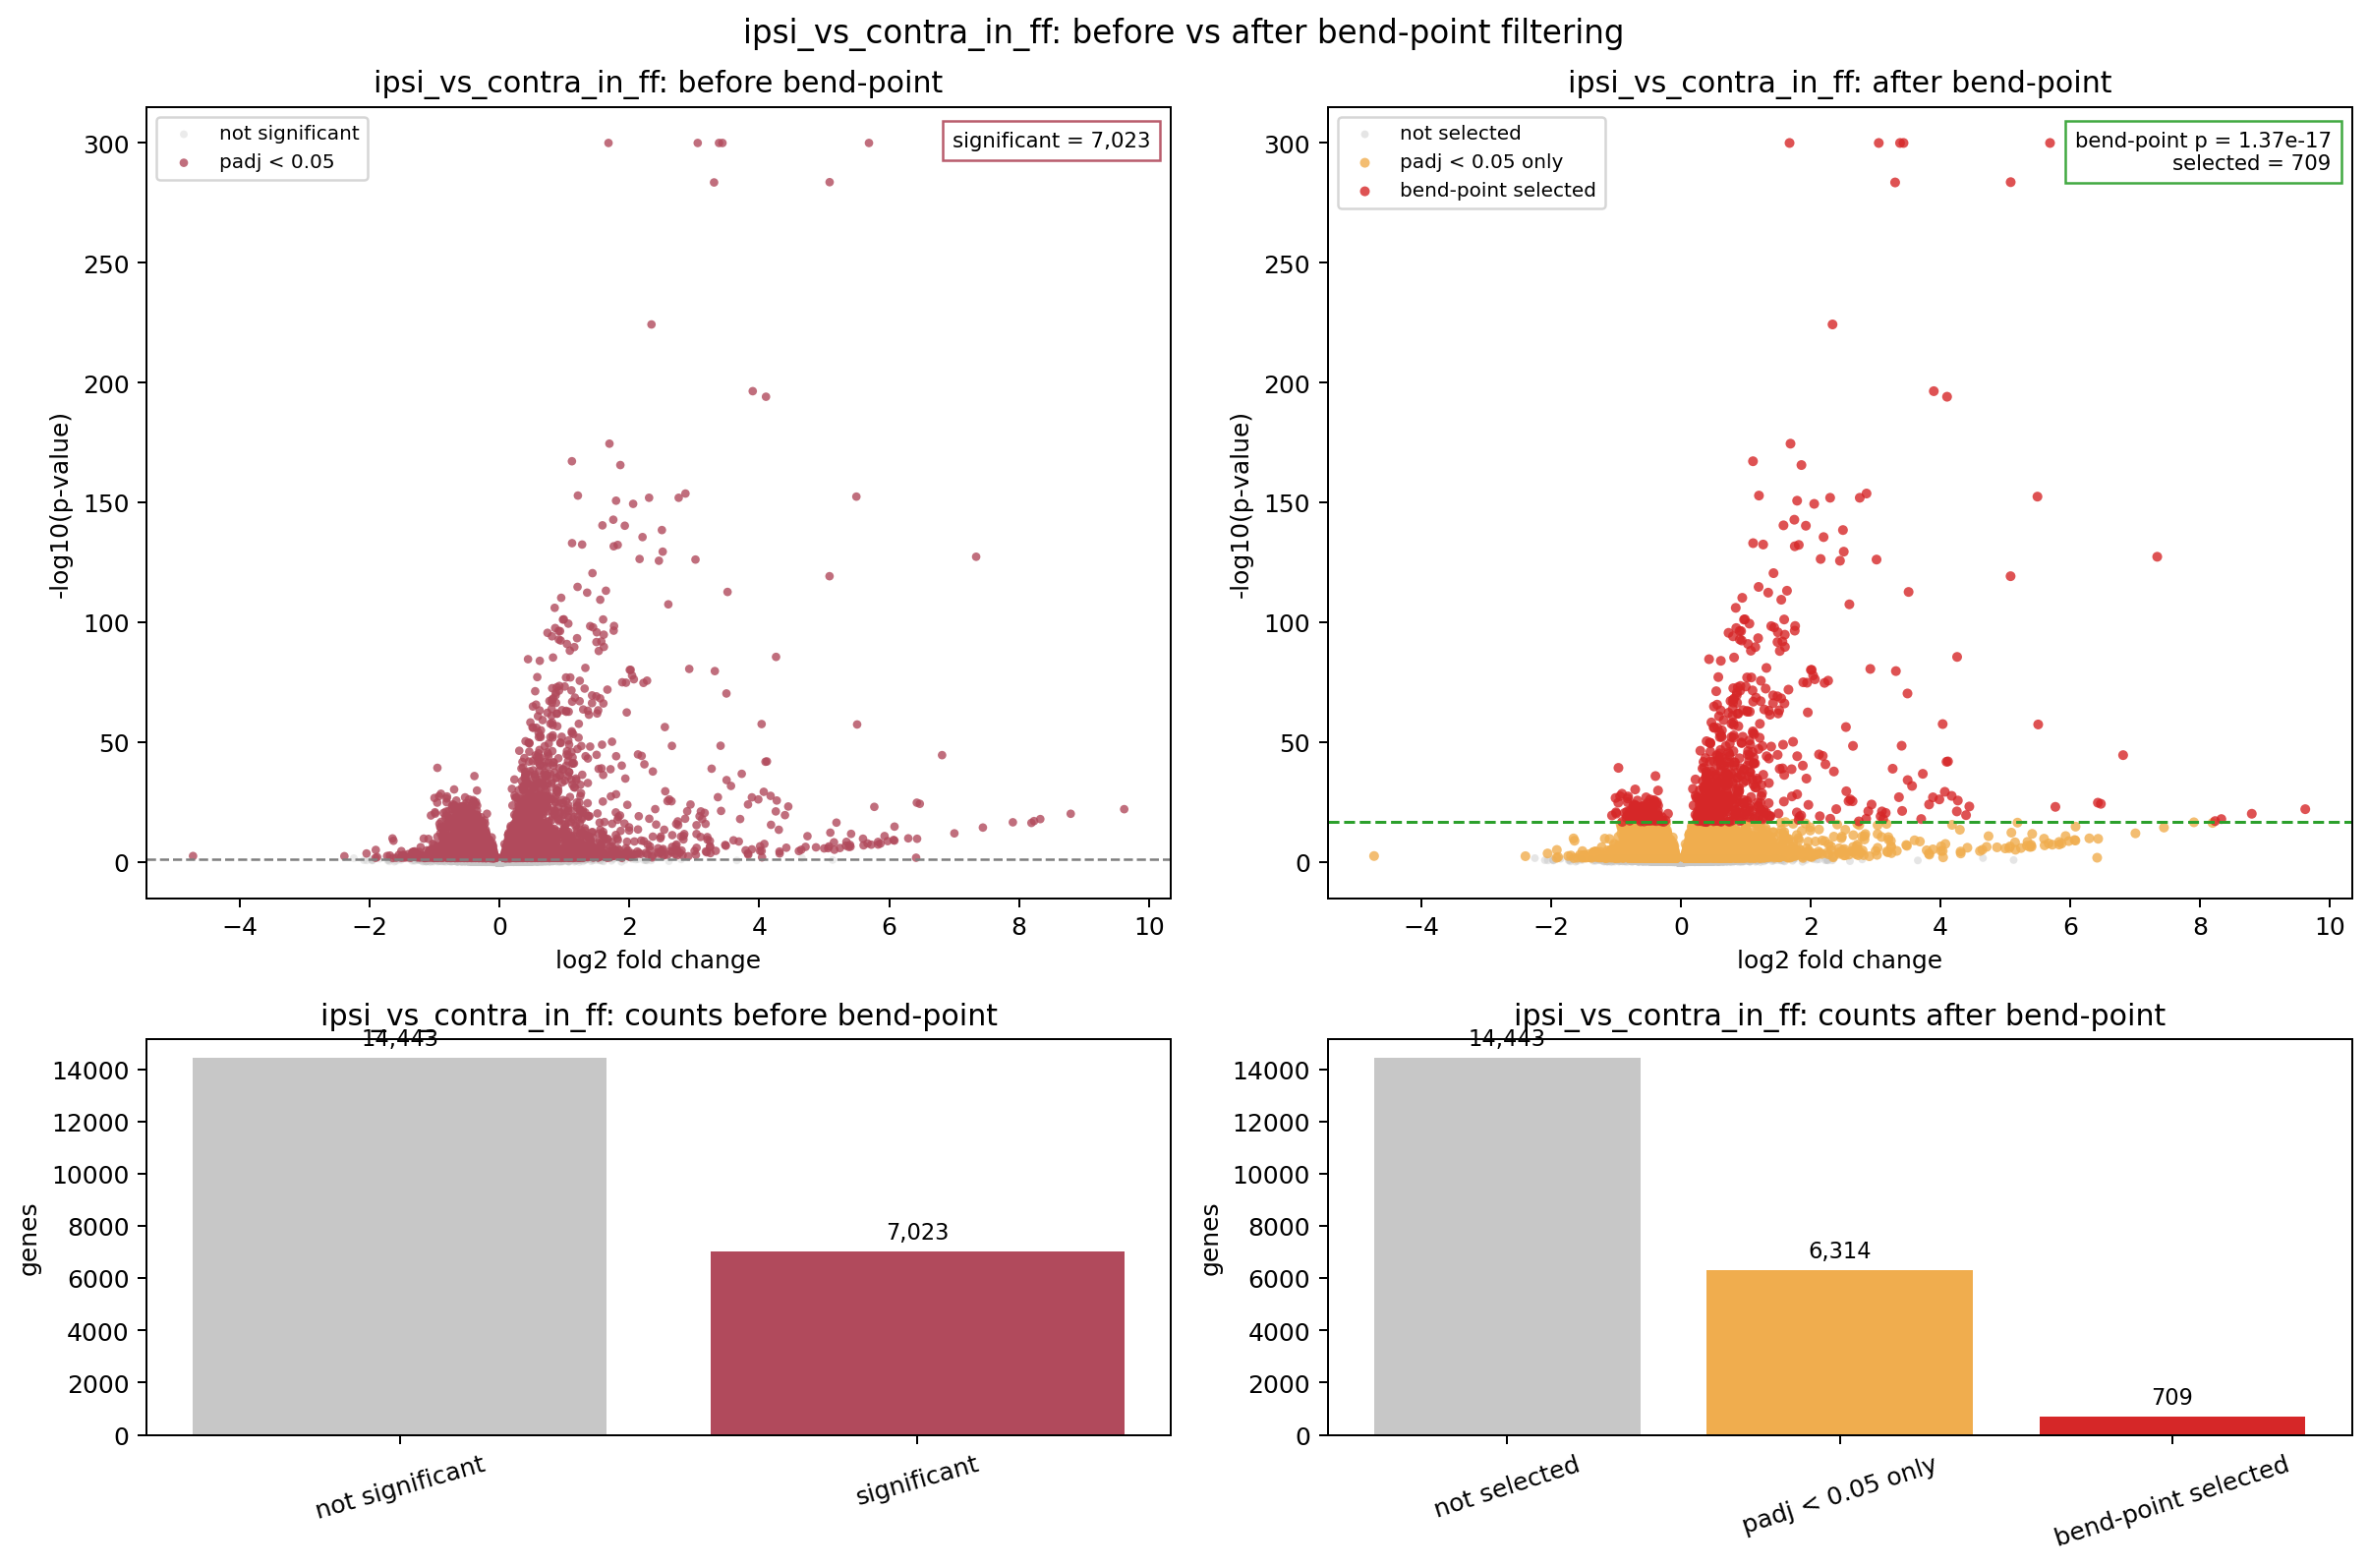

In [35]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'before_after_selection_comparison.png'), width=1000))

**What we did:** Displayed the combined before/after comparison grid for `ipsi_vs_contra_in_ff`.

**Why it matters:** The top row shows the full volcano and the post-bend-point volcano side by side, while the bottom row shows the matching count breakdowns before and after narrowing. This makes it easier to see that the bend-point threshold does not erase the signal; it highlights a smaller core subset inside the much larger significant-gene set.

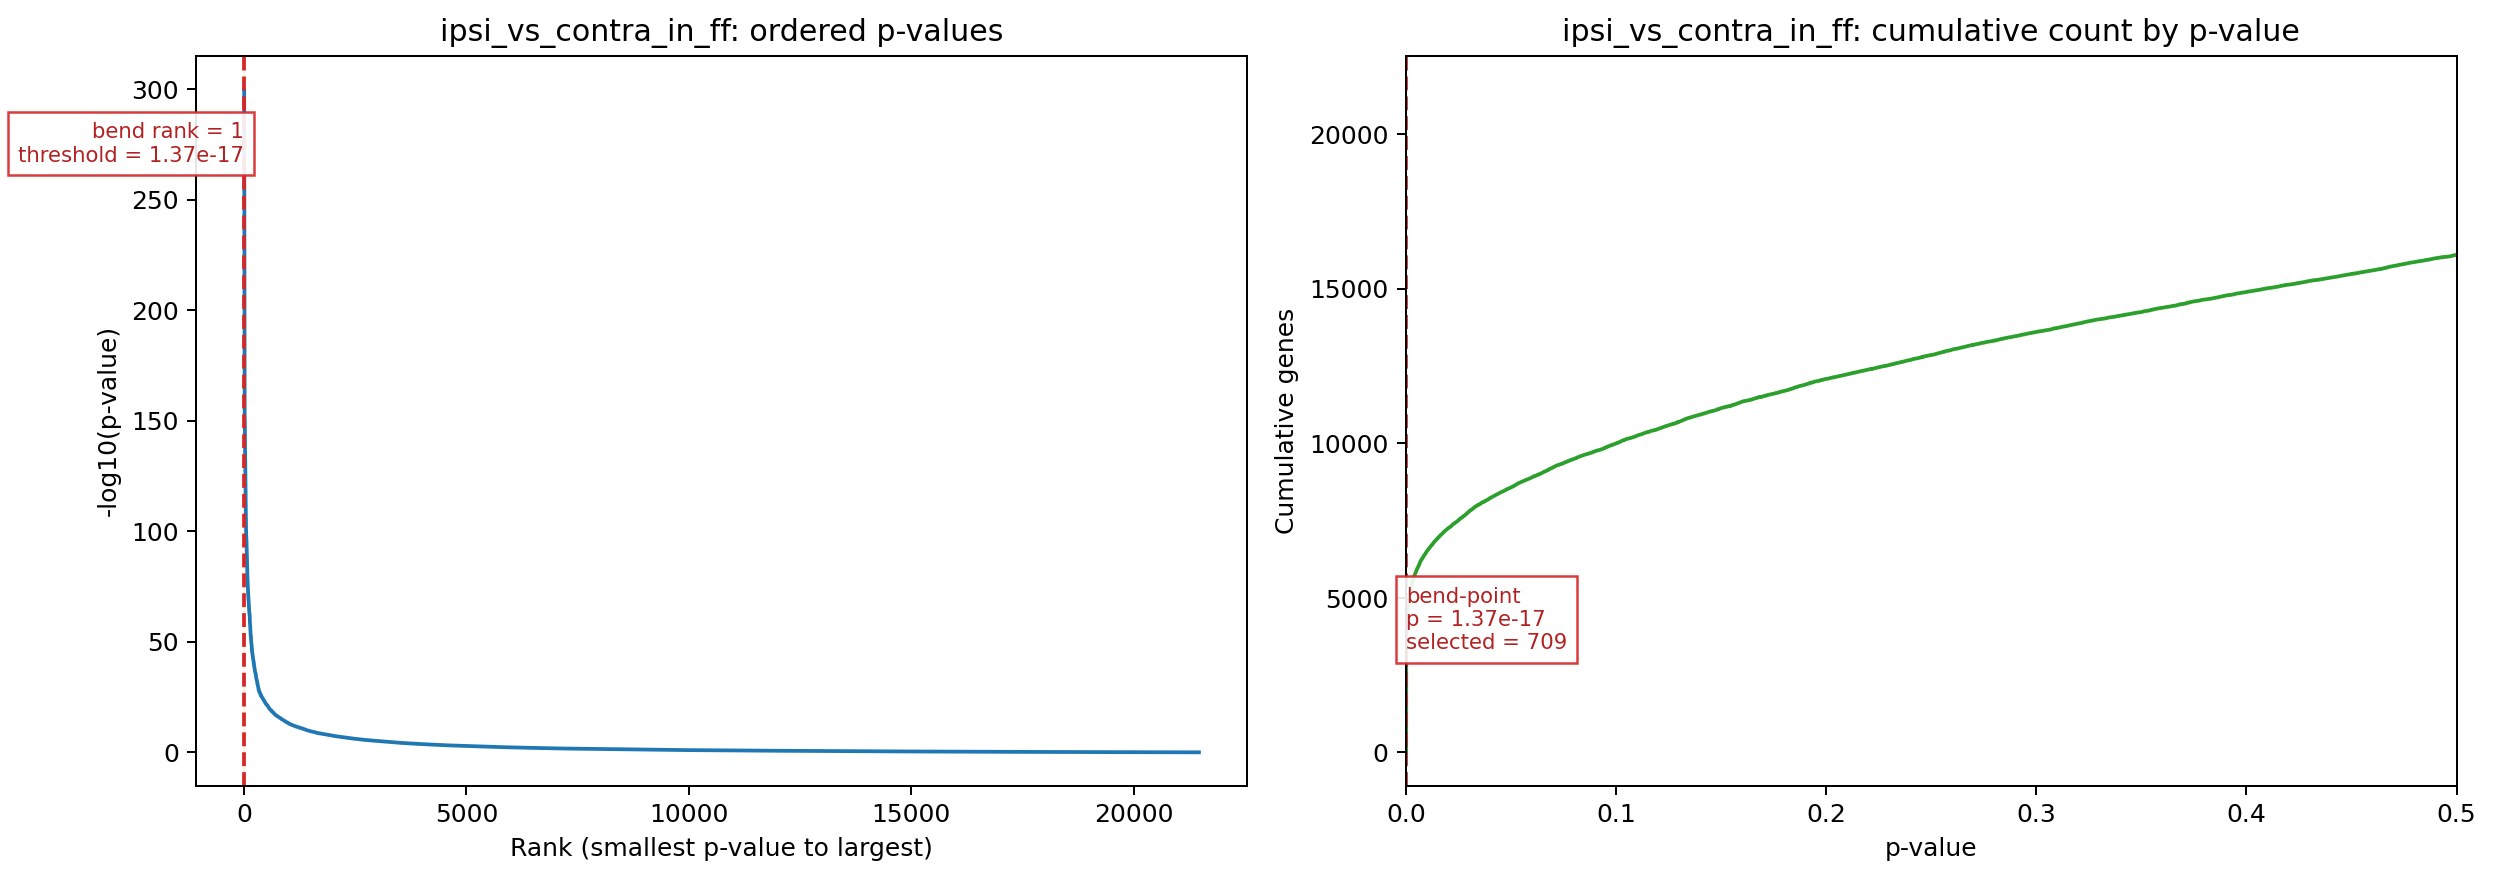

In [36]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'ordered_pvalue_and_cumulative_curve.png'), width=1000))

**What we did:** Displayed the ordered-`pvalue` / cumulative curve for `ipsi_vs_contra_in_ff`.

**Why it matters:** The dashed line and annotation now mark the bend-point explicitly, including the threshold value and the selected-gene count. This makes it easier to see that the bend-point is not redefining significance; it is carving out a smaller core follow-up set from the much larger significant-gene tail.

### Bend-point summary table — `ipsi_vs_contra_in_ff`

In [37]:
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'bendpoint_summary.tsv', sep='	'))

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,ipsi_vs_contra_in_ff,21466,7023,1.374018e-17,709


**What we did:** Displayed the bend-point summary table for `ipsi_vs_contra_in_ff`.

**Why it matters:** The summary records the tested-gene count, the total number of significant genes, the bend-point threshold, and the final narrowed set we can carry into enrichment and figure triage.

### Bend-point-selected genes preview — `ipsi_vs_contra_in_ff`

In [38]:
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'selected_genes_bendpoint.tsv', sep='	').head(20))

,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000026628,0.000000e+00,0.000000e+00,5.689282,14650.812564,1,0.000000,300.000000,0.000000,True
1,ENSMUSG00000036390,0.000000e+00,0.000000e+00,3.378730,7407.125832,2,0.000047,300.000000,0.000047,True
2,ENSMUSG00000051379,0.000000e+00,0.000000e+00,3.432440,5691.613725,3,0.000093,300.000000,0.000093,True
3,ENSMUSG00000063632,4.173594e-315,2.239759e-311,3.051050,2497.658471,4,0.000140,300.000000,0.000140,True
4,ENSMUSG00000052684,5.925095e-310,2.543762e-306,1.676557,12732.080048,5,0.000186,300.000000,0.000186,True
5,ENSMUSG00000073680,2.194698e-284,7.851898e-281,5.083084,829.441406,6,0.000233,283.658625,0.054238,True
6,ENSMUSG00000019647,2.877959e-284,8.825467e-281,3.302991,4767.595802,7,0.000280,283.540915,0.054584,True
7,ENSMUSG00000001473,4.803378e-225,1.288866e-221,2.338560,1906.164567,8,0.000326,224.318453,0.251944,True
8,ENSMUSG00000031574,3.236989e-197,7.720579e-194,3.898638,608.571399,9,0.000373,196.489859,0.344659,True
9,ENSMUSG00000042816,6.780940e-195,1.455597e-191,4.102968,871.386731,10,0.000419,194.168710,0.352350,True


**What we did:** Previewed the first bend-point-selected genes for `ipsi_vs_contra_in_ff`.

**Why it matters:** This selected set is the default input for the transcript-guided follow-up analyses because it narrows the very large DE list without relying on an arbitrary top-`N` rule.

### Standalone volcano + count view — `ipsi_vs_contra_in_cre`


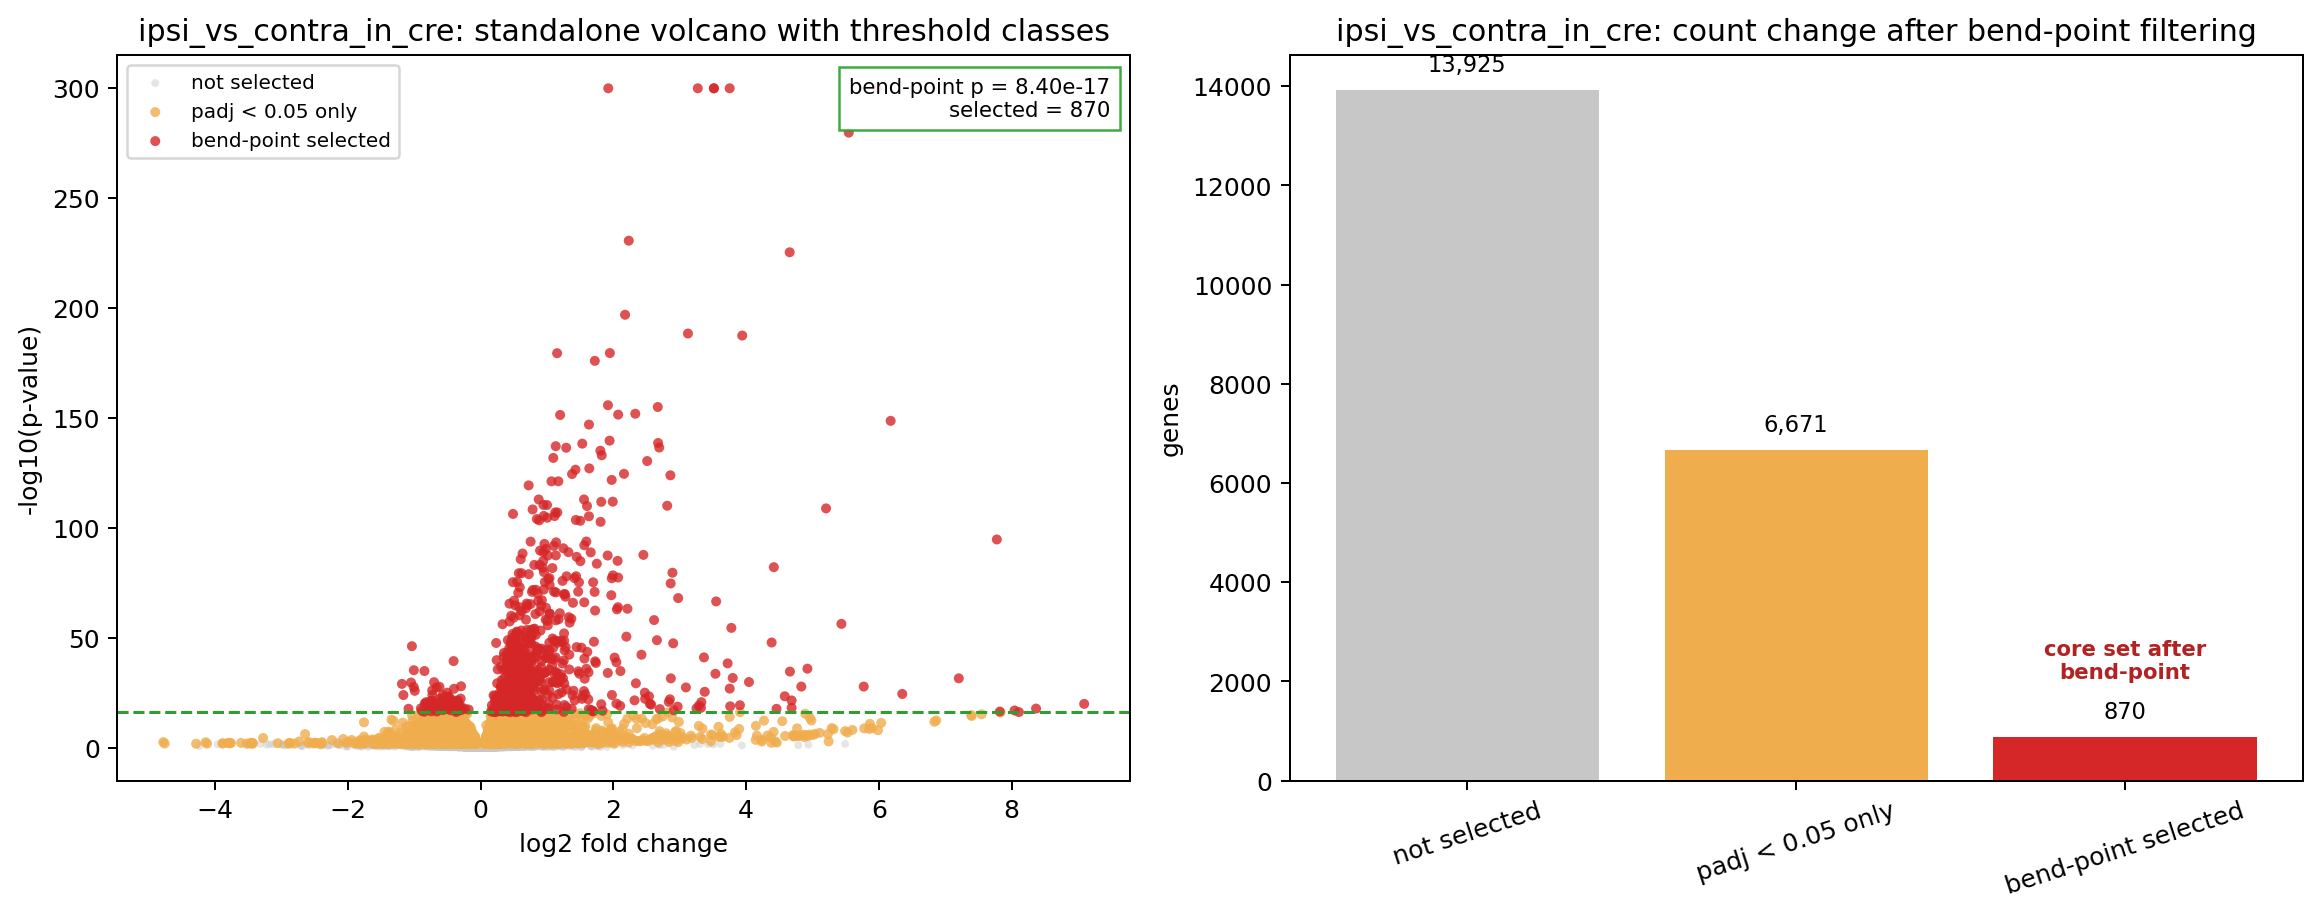

In [39]:
display(HTML((DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'volcano_with_counts.html').read_text()))

**What we did:** Displayed the standalone volcano and count breakdown for `ipsi_vs_contra_in_cre`.

**Why it matters:** This standalone view serves the same purpose for the CRE-side contrast, so the raw result and the threshold comparison stay separate.

### Ordered p-value curve — `ipsi_vs_contra_in_cre`

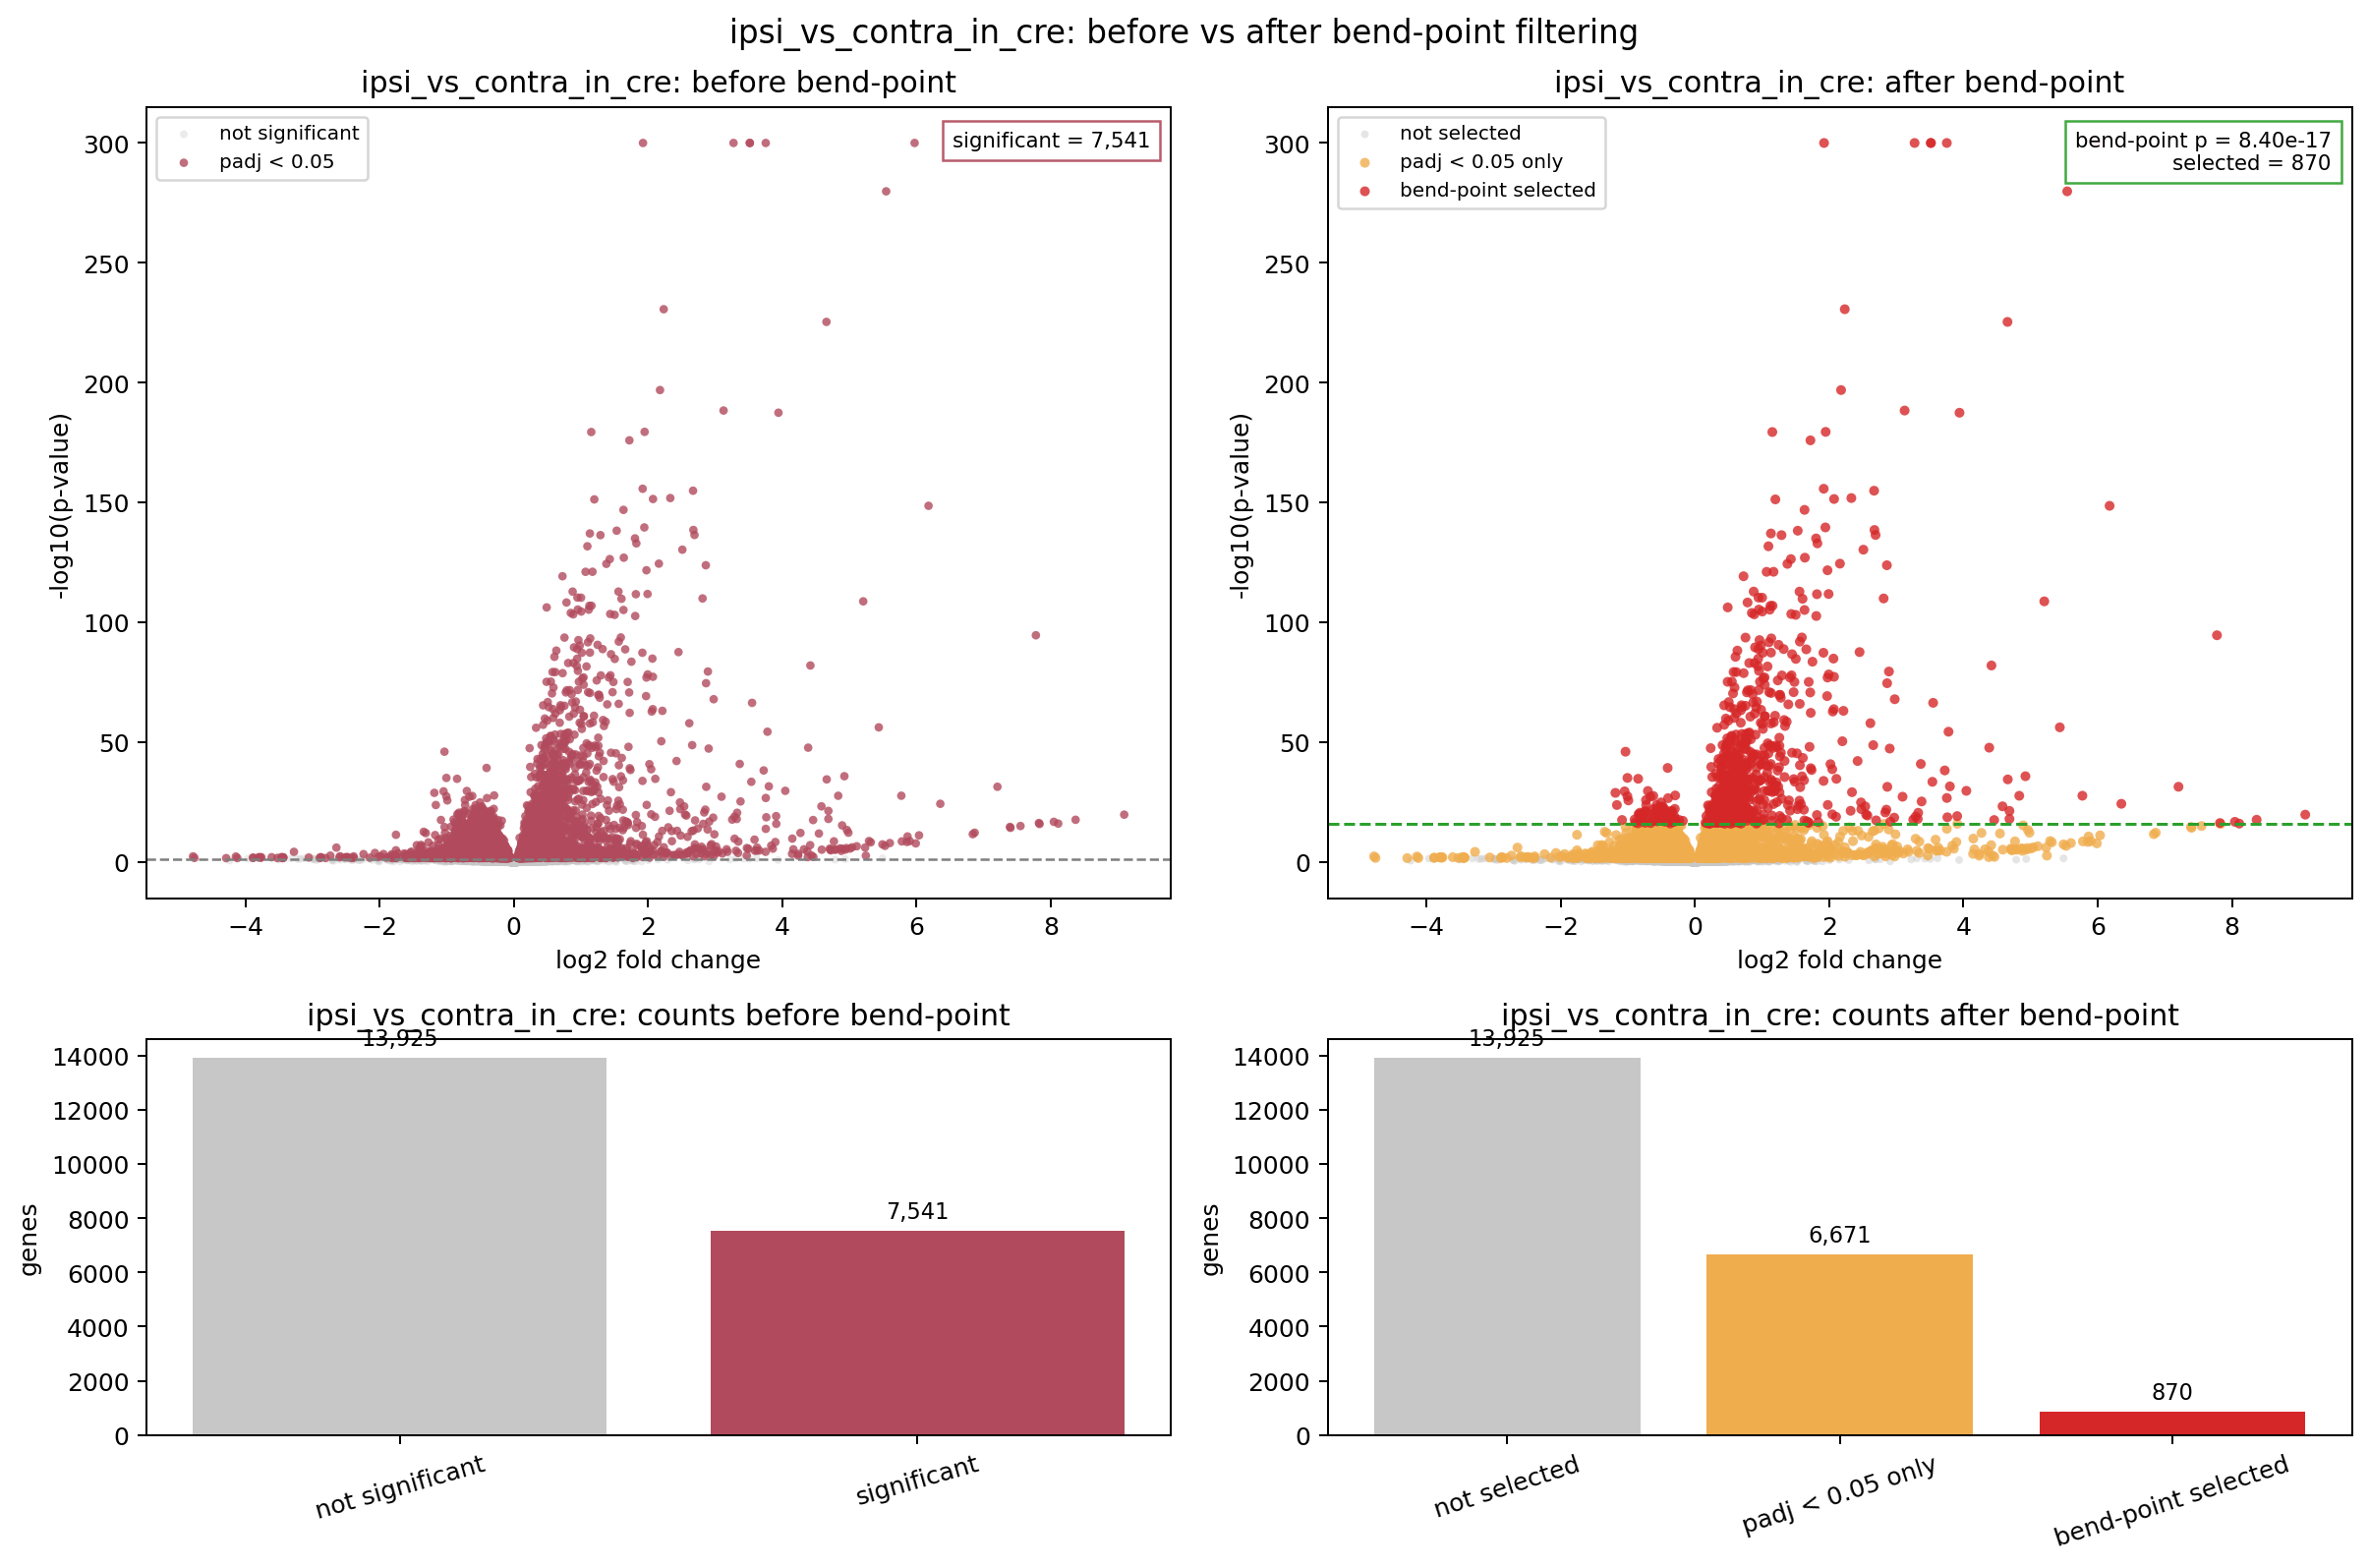

In [40]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'before_after_selection_comparison.png'), width=1000))

**What we did:** Displayed the combined before/after comparison grid for `ipsi_vs_contra_in_cre`.

**Why it matters:** The top row compares the volcano before and after bend-point filtering, and the bottom row compares the count summaries before and after the threshold. This lets us see the same contrast in both views: the full significant cloud and the narrower core set used for follow-up interpretation.

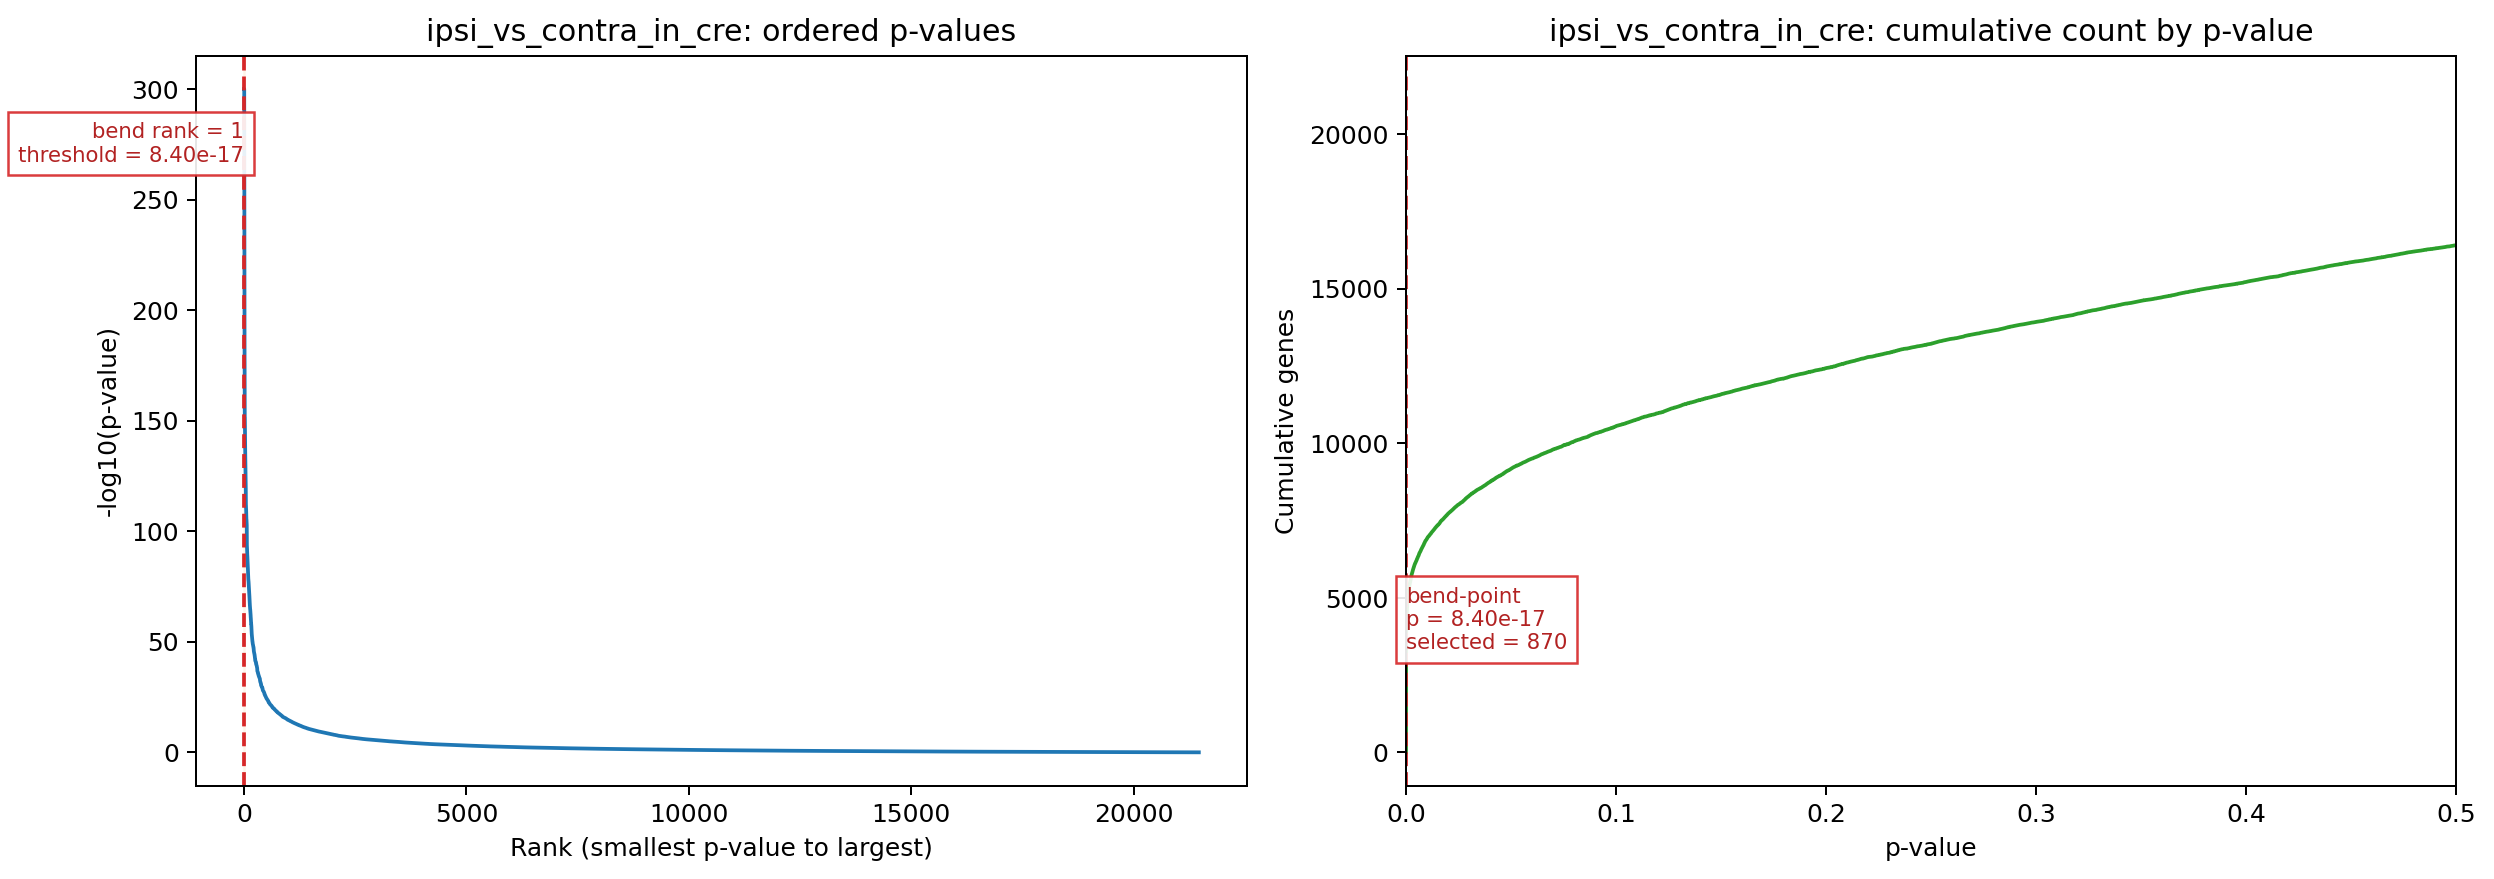

In [41]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'ordered_pvalue_and_cumulative_curve.png'), width=1000))

**What we did:** Displayed the ordered-`pvalue` / cumulative curve for `ipsi_vs_contra_in_cre`.

**Why it matters:** The bend-point line and annotation now show exactly where the threshold sits on the curve and how many genes remain after narrowing. This is the visual explanation for why the bend-point count is much smaller than the total significant-gene count.

### Bend-point summary table — `ipsi_vs_contra_in_cre`

In [42]:
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'bendpoint_summary.tsv', sep='	'))

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,ipsi_vs_contra_in_cre,21466,7541,8.396838e-17,870


**What we did:** Displayed the bend-point summary table for `ipsi_vs_contra_in_cre`.

**Why it matters:** This gives us a consistent side-specific narrowing rule across both main contrasts so we can compare follow-up gene interpretation more cleanly.

### Bend-point-selected genes preview — `ipsi_vs_contra_in_cre`

In [43]:
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'selected_genes_bendpoint.tsv', sep='	').head(20))

,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000026628,0.000000e+00,0.000000e+00,5.970877,14650.812564,1,0.000000,300.000000,0.000000,True
1,ENSMUSG00000036390,0.000000e+00,0.000000e+00,3.516284,7407.125832,2,0.000047,300.000000,0.000047,True
2,ENSMUSG00000051379,0.000000e+00,0.000000e+00,3.753422,5691.613725,3,0.000093,300.000000,0.000093,True
3,ENSMUSG00000052684,0.000000e+00,0.000000e+00,1.924662,12732.080048,4,0.000140,300.000000,0.000140,True
4,ENSMUSG00000063632,0.000000e+00,0.000000e+00,3.273226,2497.658471,5,0.000186,300.000000,0.000186,True
5,ENSMUSG00000019647,9.684882e-318,3.464928e-314,3.515638,4767.595802,6,0.000233,300.000000,0.000233,True
6,ENSMUSG00000073680,1.472341e-280,4.515038e-277,5.547182,829.441406,7,0.000280,279.831992,0.066947,True
7,ENSMUSG00000037428,2.147886e-231,5.763315e-228,2.233345,16683.752209,8,0.000326,230.667989,0.230779,True
8,ENSMUSG00000042816,4.125676e-226,9.840195e-223,4.657516,871.386731,9,0.000373,225.384505,0.248344,True
9,ENSMUSG00000001473,1.104265e-197,2.370416e-194,2.178042,1906.164567,10,0.000419,196.956927,0.343056,True


**What we did:** Previewed the bend-point-selected genes for `ipsi_vs_contra_in_cre`.

**Why it matters:** This is the candidate gene set we carry into enrichment instead of using an arbitrary fixed-size shortlist.

## Genotype-focused follow-up

### Genotype comparison summary — `geno_in_contra` vs `geno_in_ipsi`

### Genotype comparison volcanoes

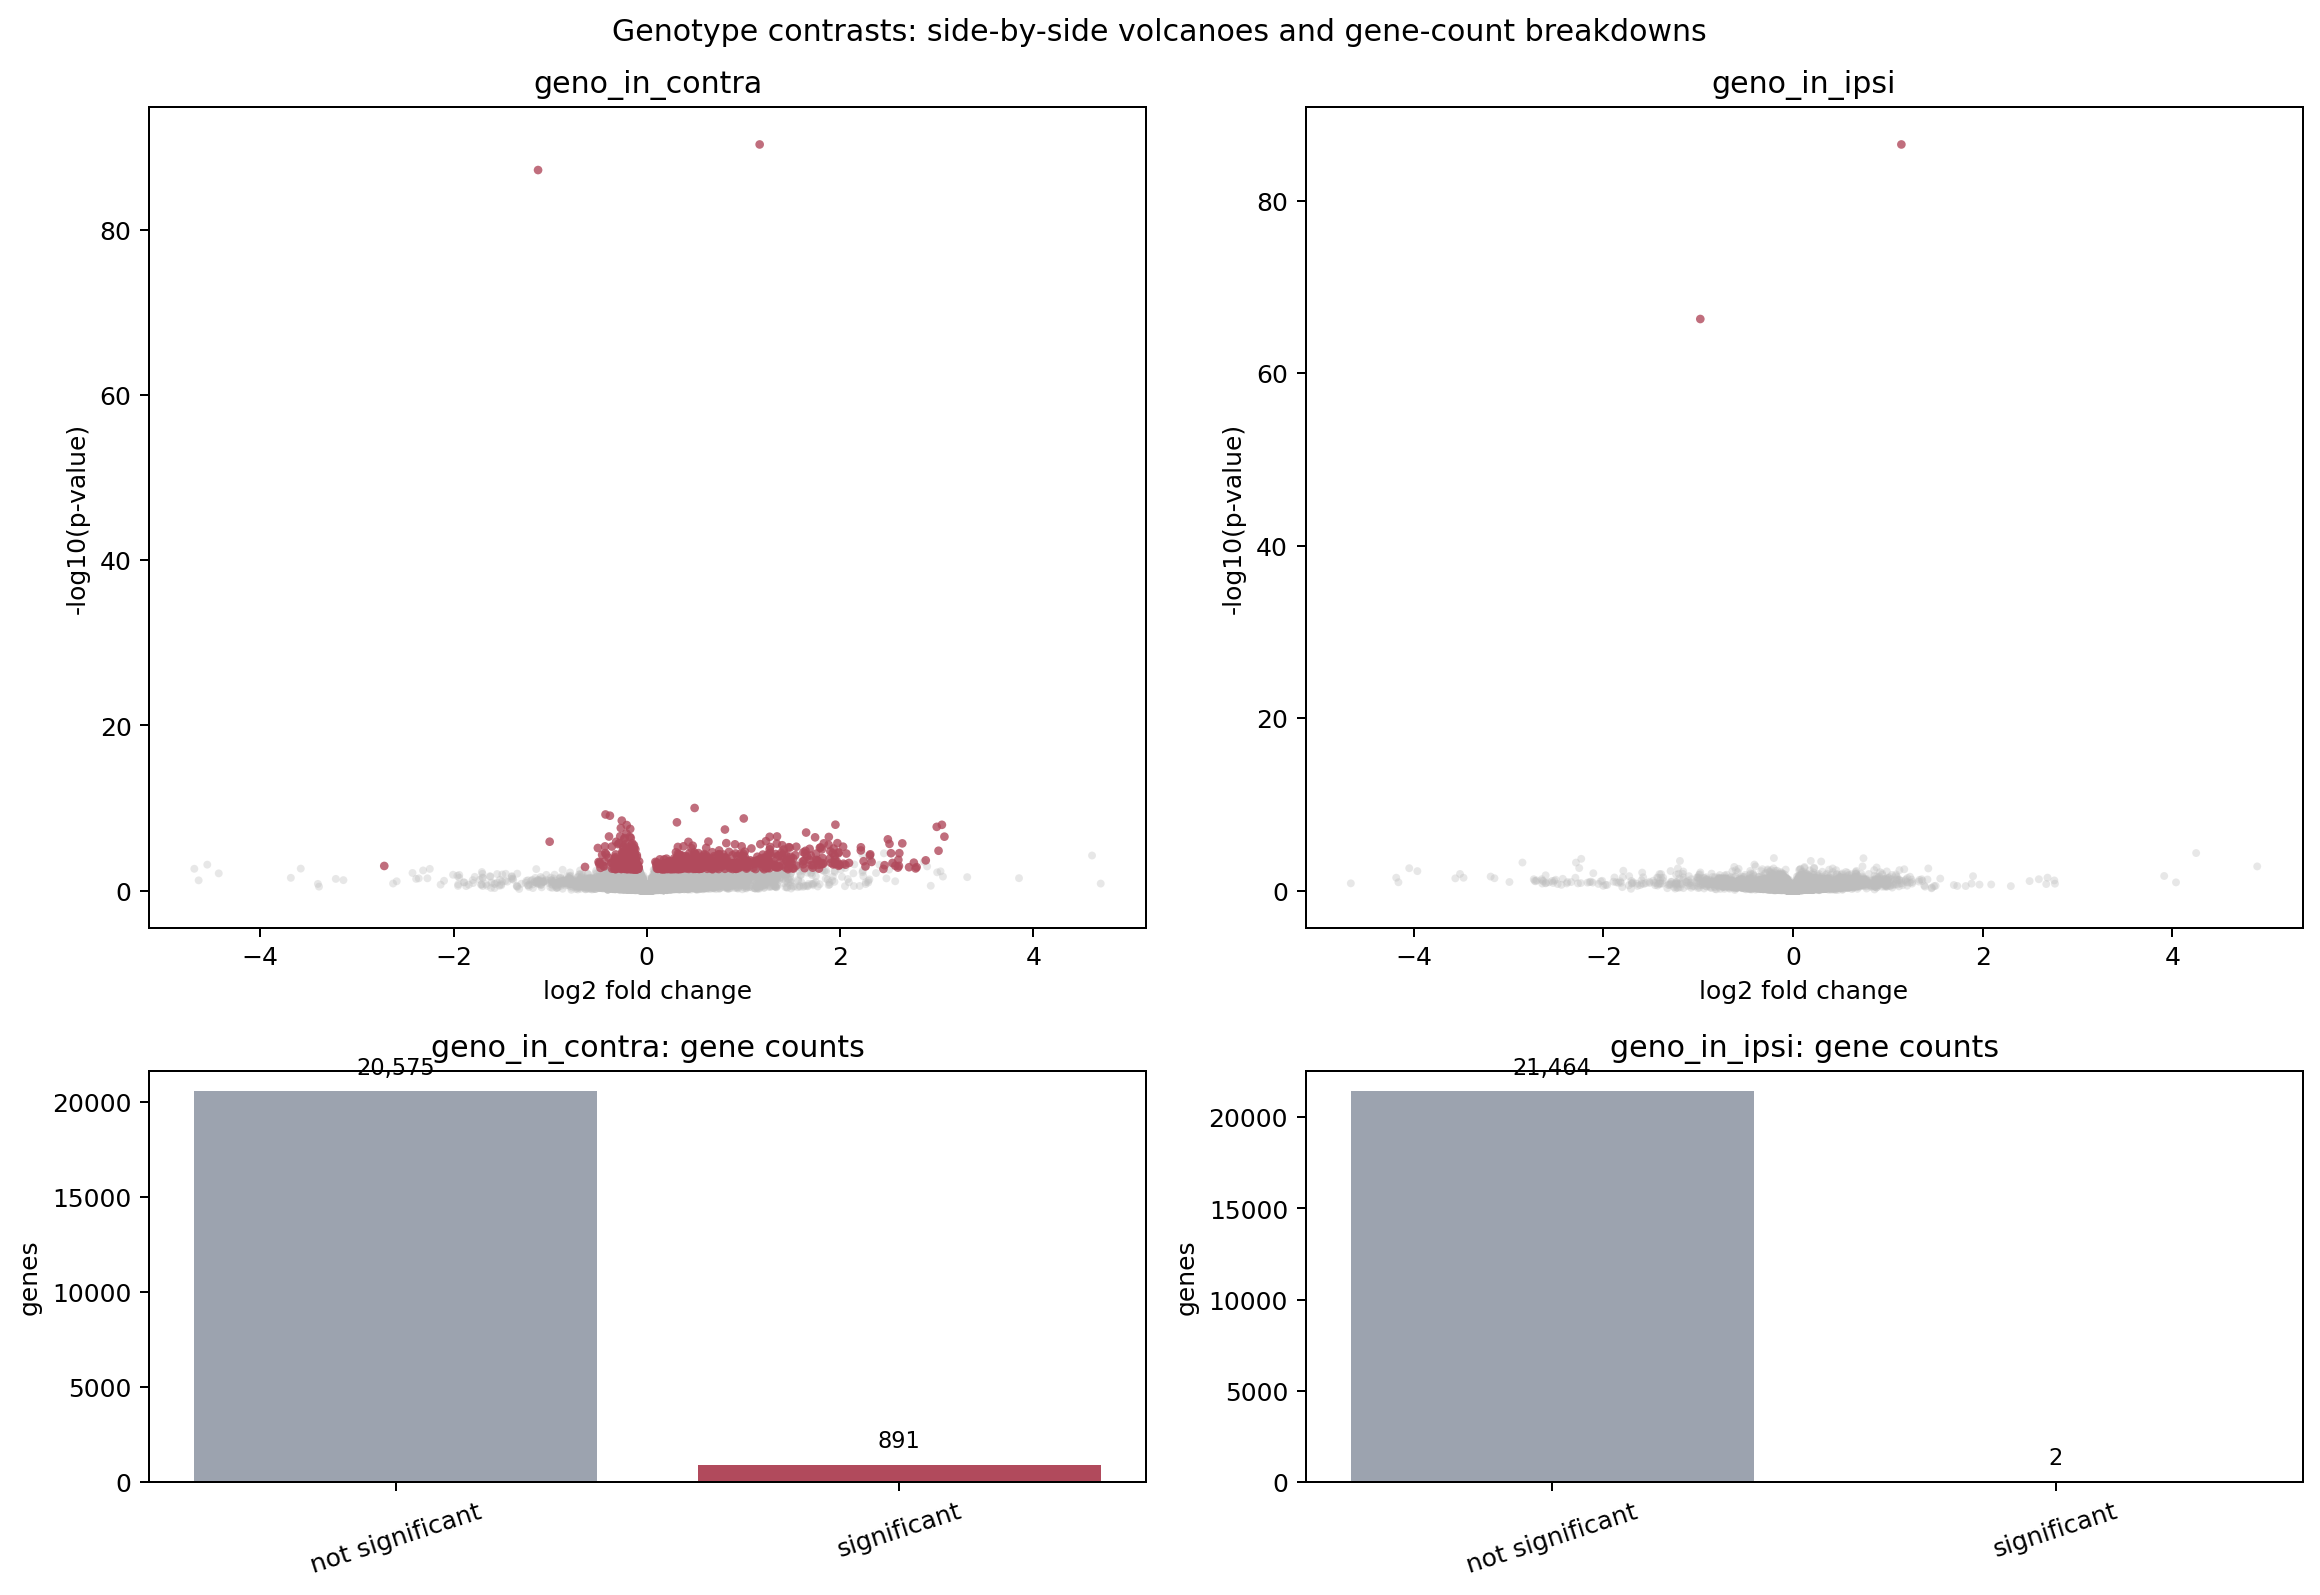

In [44]:
display(Image(filename=str(DERIVED_DIR / 'genotype_comparison' / 'geno_volcano_and_counts_grid.png'), width=1100))

**What we did:** Displayed `geno_in_contra` and `geno_in_ipsi` volcanoes side by side, with their significant-vs-nonsignificant gene counts directly below each plot.

**Why it matters:** This makes the contrast much easier to read. The top row shows the signal shape, while the bottom row shows the gene-count breakdown. Together, they make it clear that genotype is weaker than the main side-specific signal but not zero, and that `geno_in_contra` is the stronger secondary genotype branch.

### Genotype effect-size distributions

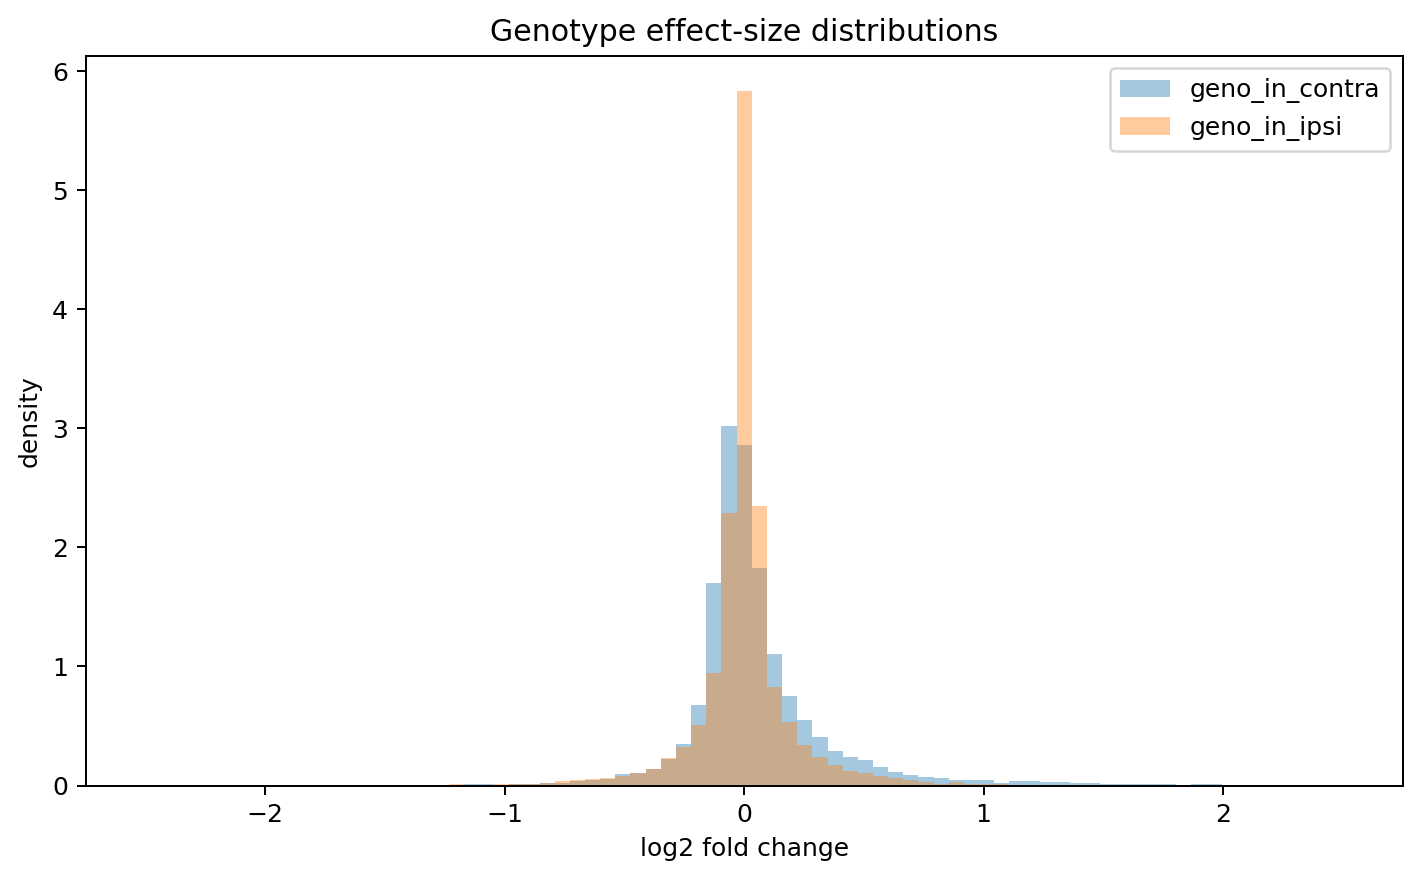

In [45]:
display(Image(filename=str(DERIVED_DIR / 'genotype_comparison' / 'geno_log2fc_density.png'), width=850))

**What we did:** Displayed the log2 fold-change distributions for the two genotype contrasts.

**Why it matters:** This shows that weaker does not mean zero. The genotype branches still have measurable effect-size structure, but it is not as dominant or as cleanly separated as the side-specific branch.

In [46]:
display(pd.read_csv(DERIVED_DIR / 'genotype_comparison' / 'geno_in_contra_vs_geno_in_ipsi_summary.tsv', sep='	'))

,contrast_id,genes_tested,significant_padj_lt_0_05,top_abs_log2fc,median_abs_log2fc
0,geno_in_contra,16891,891,4.697306,0.098601
1,geno_in_ipsi,21466,2,4.895816,0.050534


**What we did:** Displayed the side-by-side genotype summary for `geno_in_contra` and `geno_in_ipsi`.

**Why it matters:** This table quantifies the comparison, but the paired volcano and count grid below makes the difference easier to see visually: `geno_in_contra` is weaker than the side-specific contrasts, yet still clearly stronger than `geno_in_ipsi`.

### Significant-gene count plot — genotype contrasts

### Genotype counts + boxplot zoom

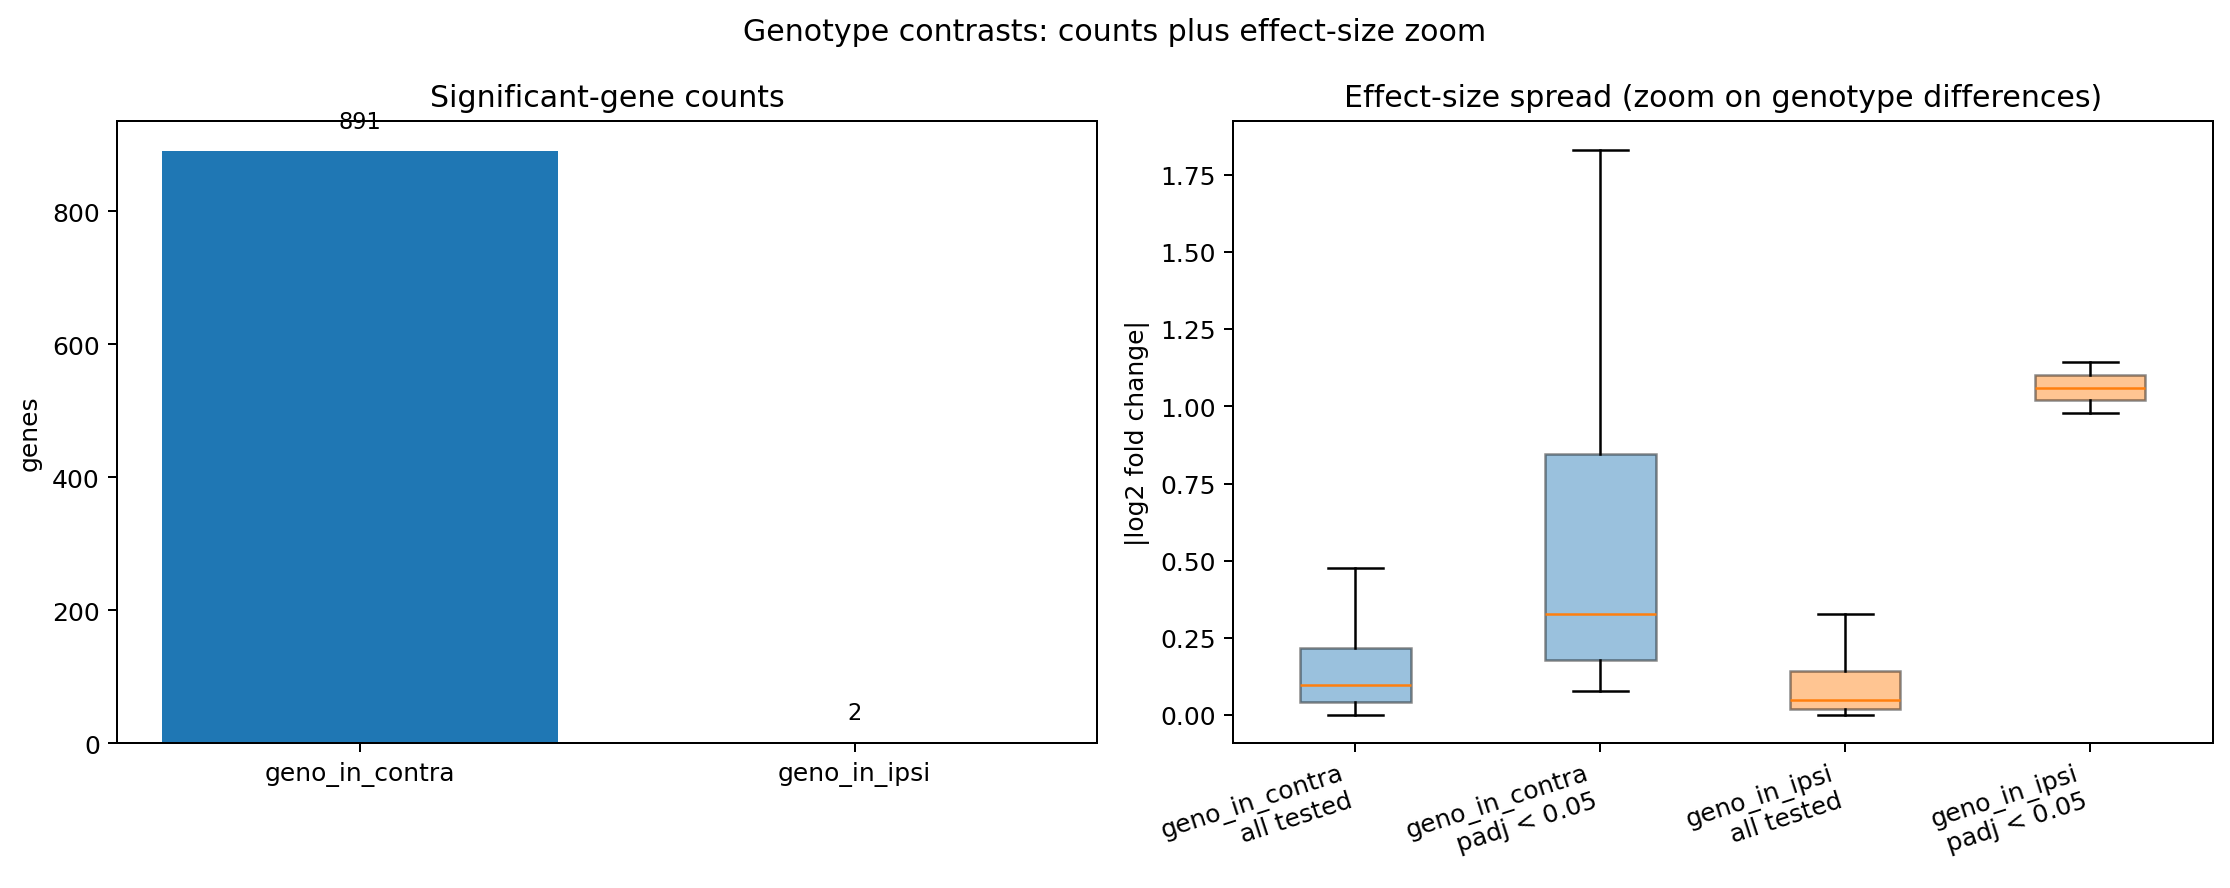

In [47]:
display(Image(filename=str(DERIVED_DIR / 'genotype_comparison' / 'geno_counts_and_boxplot_zoom.png'), width=1000))

**What we did:** Displayed the genotype count bars next to a boxplot view of absolute `log2FoldChange` spread.

**Why it matters:** The count bars alone compress the weaker branch visually. The boxplot gives a zoomed view of the effect-size spread, so we can see that `geno_in_ipsi` is weaker but not flat, while `geno_in_contra` still has the broader and stronger secondary genotype profile.

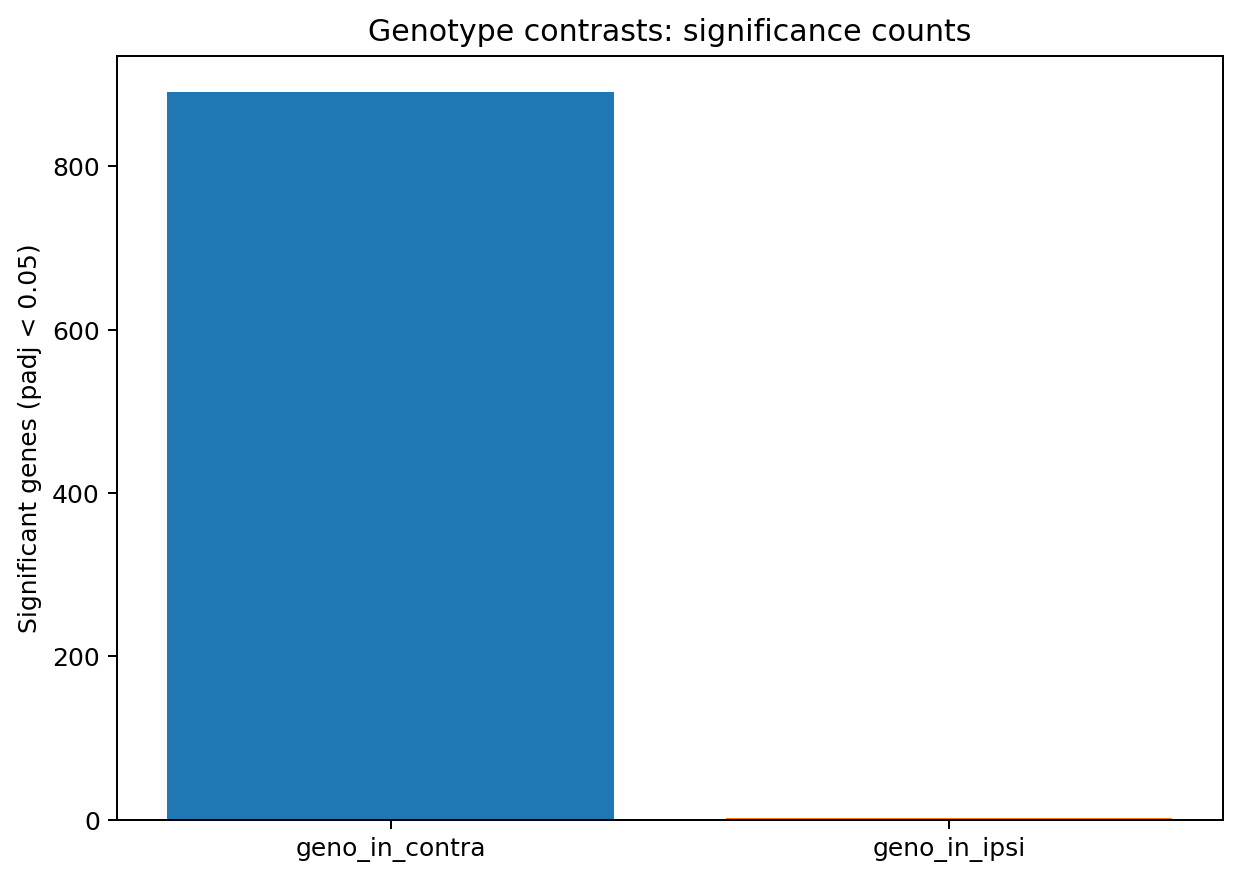

In [48]:
display(Image(filename=str(DERIVED_DIR / 'genotype_comparison' / 'geno_significant_gene_counts.png'), width=700))

**What we did:** Displayed the significant-gene count comparison for the two genotype contrasts.

**Why it matters:** This makes the scale difference visually obvious and reinforces that `geno_in_contra` is the more informative secondary genotype branch for downstream interpretation.

### Top genes by adjusted p-value — `geno_in_contra`

In [49]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_contra' / 'top_genes_by_padj.tsv', sep='	').head(20))

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the top `geno_in_contra` genes ranked by adjusted `pvalue`.

**Why it matters:** This gives us a compact view of the clearest genotype-associated hits on the contralateral side, which is the stronger genotype context in this dataset.

### Top genes by absolute log2 fold change — `geno_in_contra`

In [50]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_contra' / 'top_genes_by_abs_log2fc.tsv', sep='	').head(20))

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_log2FoldChange
0,ENSMUSG00000051295,23.892377,3.315904,1.462527,2.267243,2.337540e-02,0.160371,3.315904
1,ENSMUSG00000074199,206.203044,3.079925,0.600720,5.127058,2.943050e-07,0.000224,3.079925
2,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,0.000018,3.053604
3,ENSMUSG00000058914,87.562764,3.018954,0.697169,4.330305,1.489030e-05,0.002734,3.018954
4,ENSMUSG00000054889,48.774281,3.000426,0.533846,5.620399,1.905173e-08,0.000027,3.000426
5,ENSMUSG00000048373,185.629424,2.886676,0.780452,3.698723,2.166872e-04,0.013864,2.886676
6,ENSMUSG00000079507,72.470619,2.792359,0.876464,3.185937,1.442859e-03,0.035999,2.792359
7,ENSMUSG00000024650,127.118172,2.781739,0.902776,3.081317,2.060874e-03,0.043517,2.781739
8,ENSMUSG00000048939,297.761732,2.763459,0.782357,3.532220,4.120856e-04,0.018812,2.763459
9,ENSMUSG00000058626,53.934158,-2.716778,0.828202,-3.280333,1.036848e-03,0.029937,2.716778


**What we did:** Displayed the largest-magnitude `geno_in_contra` genes by absolute `log2FoldChange`.

**Why it matters:** This helps us check whether the strongest genotype shifts are also likely to be biologically interesting enough to earn space in the next weekly report.

### Top genes by adjusted p-value — `geno_in_ipsi`

In [51]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_ipsi' / 'top_genes_by_padj.tsv', sep='	').head(20))

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.142676,0.057698,19.804529,2.720970e-87,5.840834e-83
1,ENSMUSG00000054423,26411.196648,-0.978033,0.056539,-17.298351,4.840439e-67,5.195243e-63
2,ENSMUSG00000083623,7.871461,4.251727,1.040566,4.085975,4.389208e-05,3.140625e-01
3,ENSMUSG00000072676,4424.594137,-0.201865,0.053659,-3.761964,1.685846e-04,7.356920e-01
4,ENSMUSG00000138276,66.252704,0.742814,0.197900,3.753480,1.743962e-04,7.356920e-01
5,ENSMUSG00000032517,57.937037,-2.234049,0.601847,-3.711992,2.056346e-04,7.356920e-01
6,ENSMUSG00000021843,6721.748280,0.187286,0.052493,3.567848,3.599257e-04,9.693238e-01
7,ENSMUSG00000055945,17.406644,-1.192919,0.334443,-3.566885,3.612499e-04,9.693238e-01
8,ENSMUSG00000037126,640.563025,0.296779,0.084193,3.525000,4.234832e-04,9.999588e-01
9,ENSMUSG00000058626,53.934158,-2.853836,0.826140,-3.454423,5.514722e-04,9.999588e-01


**What we did:** Displayed the top `geno_in_ipsi` genes ranked by adjusted `pvalue`.

**Why it matters:** We keep this as a contrastive comparison, but the transcript-guided emphasis remains on `geno_in_contra` because the ipsilateral genotype signal is much smaller.

### Top genes by absolute log2 fold change — `geno_in_ipsi`

In [52]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_ipsi' / 'top_genes_by_abs_log2fc.tsv', sep='	').head(20))

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_log2FoldChange
0,ENSMUSG00000095130,5.118958,4.895816,1.547781,3.163119,0.001561,0.999959,4.895816
1,ENSMUSG00000076533,4.143667,-4.664105,3.188021,-1.463010,0.143465,0.999959,4.664105
2,ENSMUSG00000083623,7.871461,4.251727,1.040566,4.085975,0.000044,0.314062,4.251727
3,ENSMUSG00000035923,5.409909,-4.185105,1.949889,-2.146329,0.031847,0.999959,4.185105
4,ENSMUSG00000096326,8.170307,-4.161901,2.590315,-1.606716,0.108117,0.999959,4.161901
5,ENSMUSG00000050578,153.771386,-4.047969,1.340199,-3.020423,0.002524,0.999959,4.047969
6,ENSMUSG00000095612,12.464514,4.039345,2.530579,1.596214,0.110441,0.999959,4.039345
7,ENSMUSG00000074483,55.158233,-3.962141,1.427539,-2.775505,0.005512,0.999959,3.962141
8,ENSMUSG00000076536,4.205276,3.914614,1.684870,2.323392,0.020158,0.999959,3.914614
9,ENSMUSG00000070385,65.163314,-3.561890,1.715392,-2.076429,0.037854,0.999959,3.561890


**What we did:** Displayed the largest-magnitude `geno_in_ipsi` genes by absolute `log2FoldChange`.

**Why it matters:** This keeps the weaker genotype branch documented without over-centering it in the Draft 1 story.

### Standalone volcano + count view — `geno_in_contra`


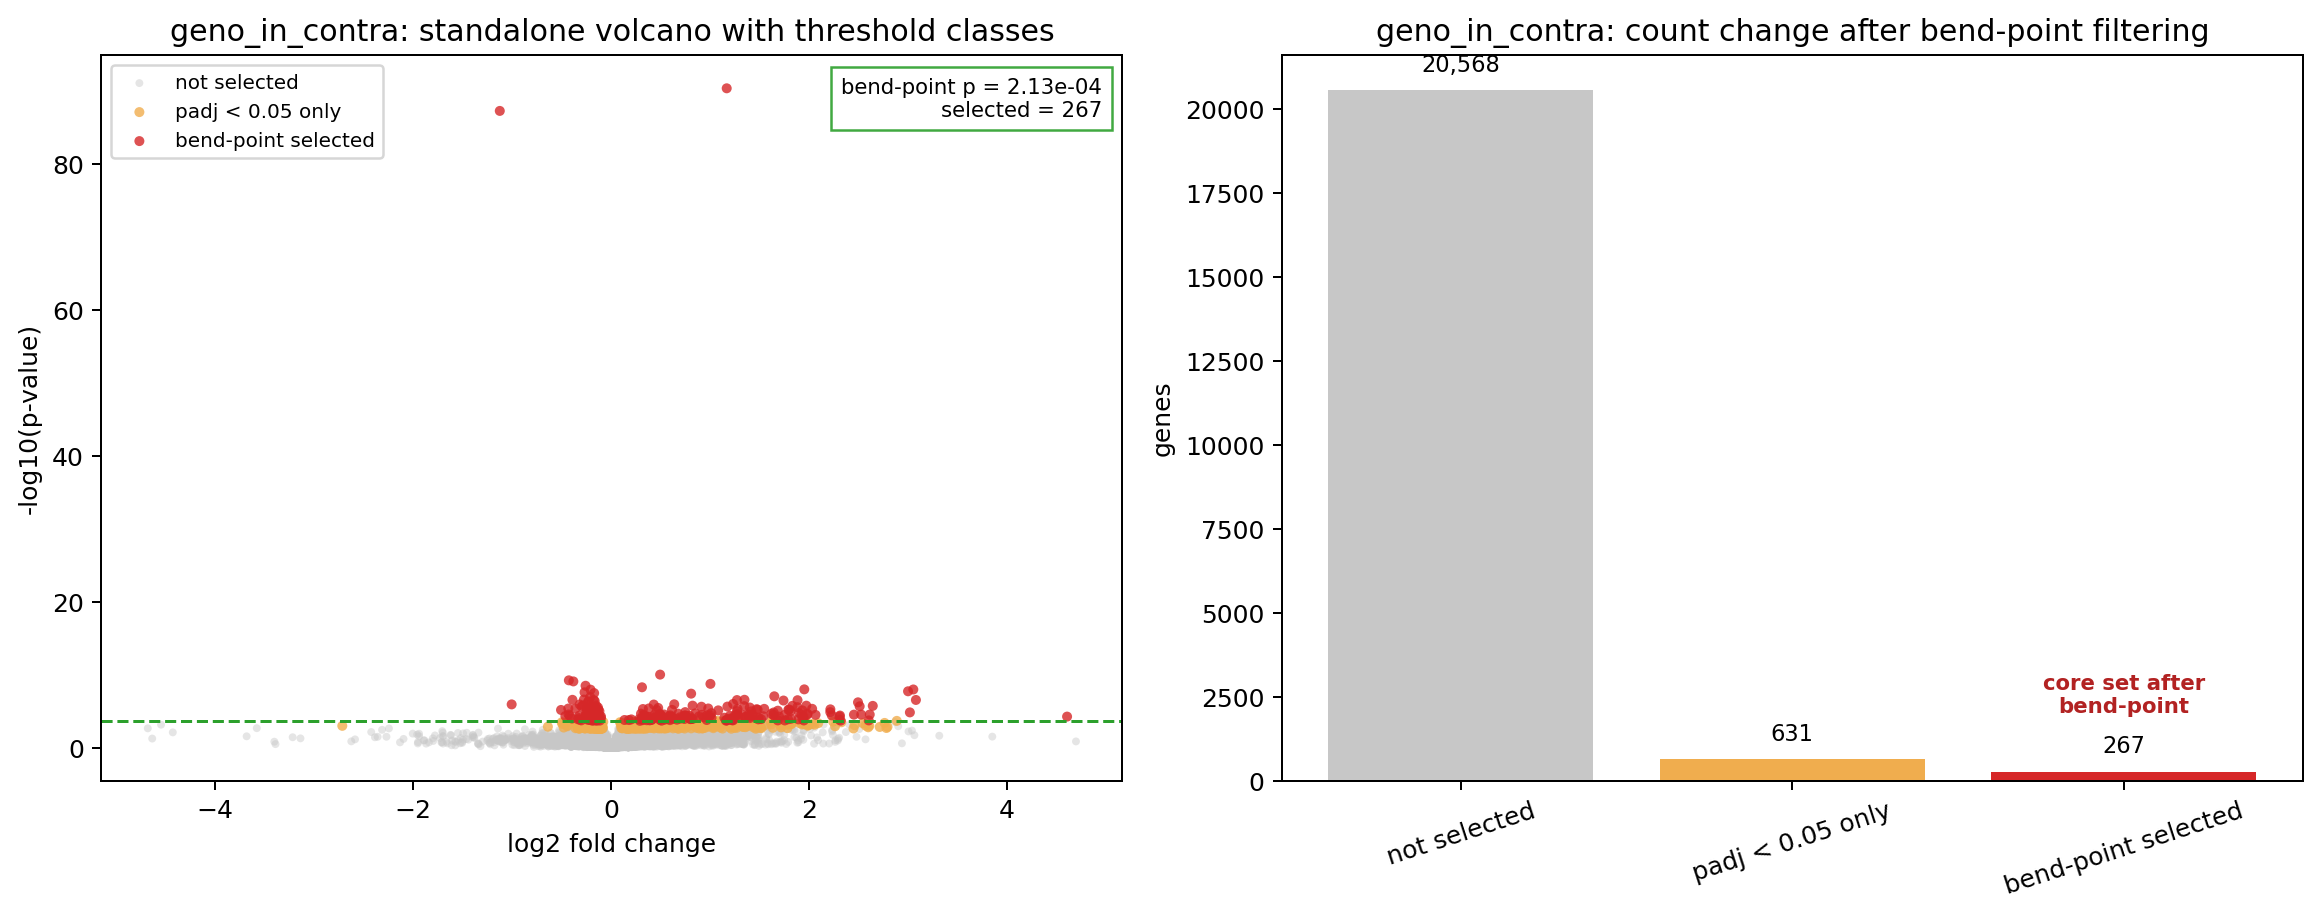

In [53]:
display(HTML((DERIVED_DIR / 'geno_in_contra' / 'volcano_with_counts.html').read_text()))

**What we did:** Displayed the standalone volcano and count breakdown for `geno_in_contra`.

**Why it matters:** This standalone genotype view lets us inspect the raw `geno_in_contra` result on its own before switching to the threshold comparison.

### Bend-point summary table — `geno_in_contra`

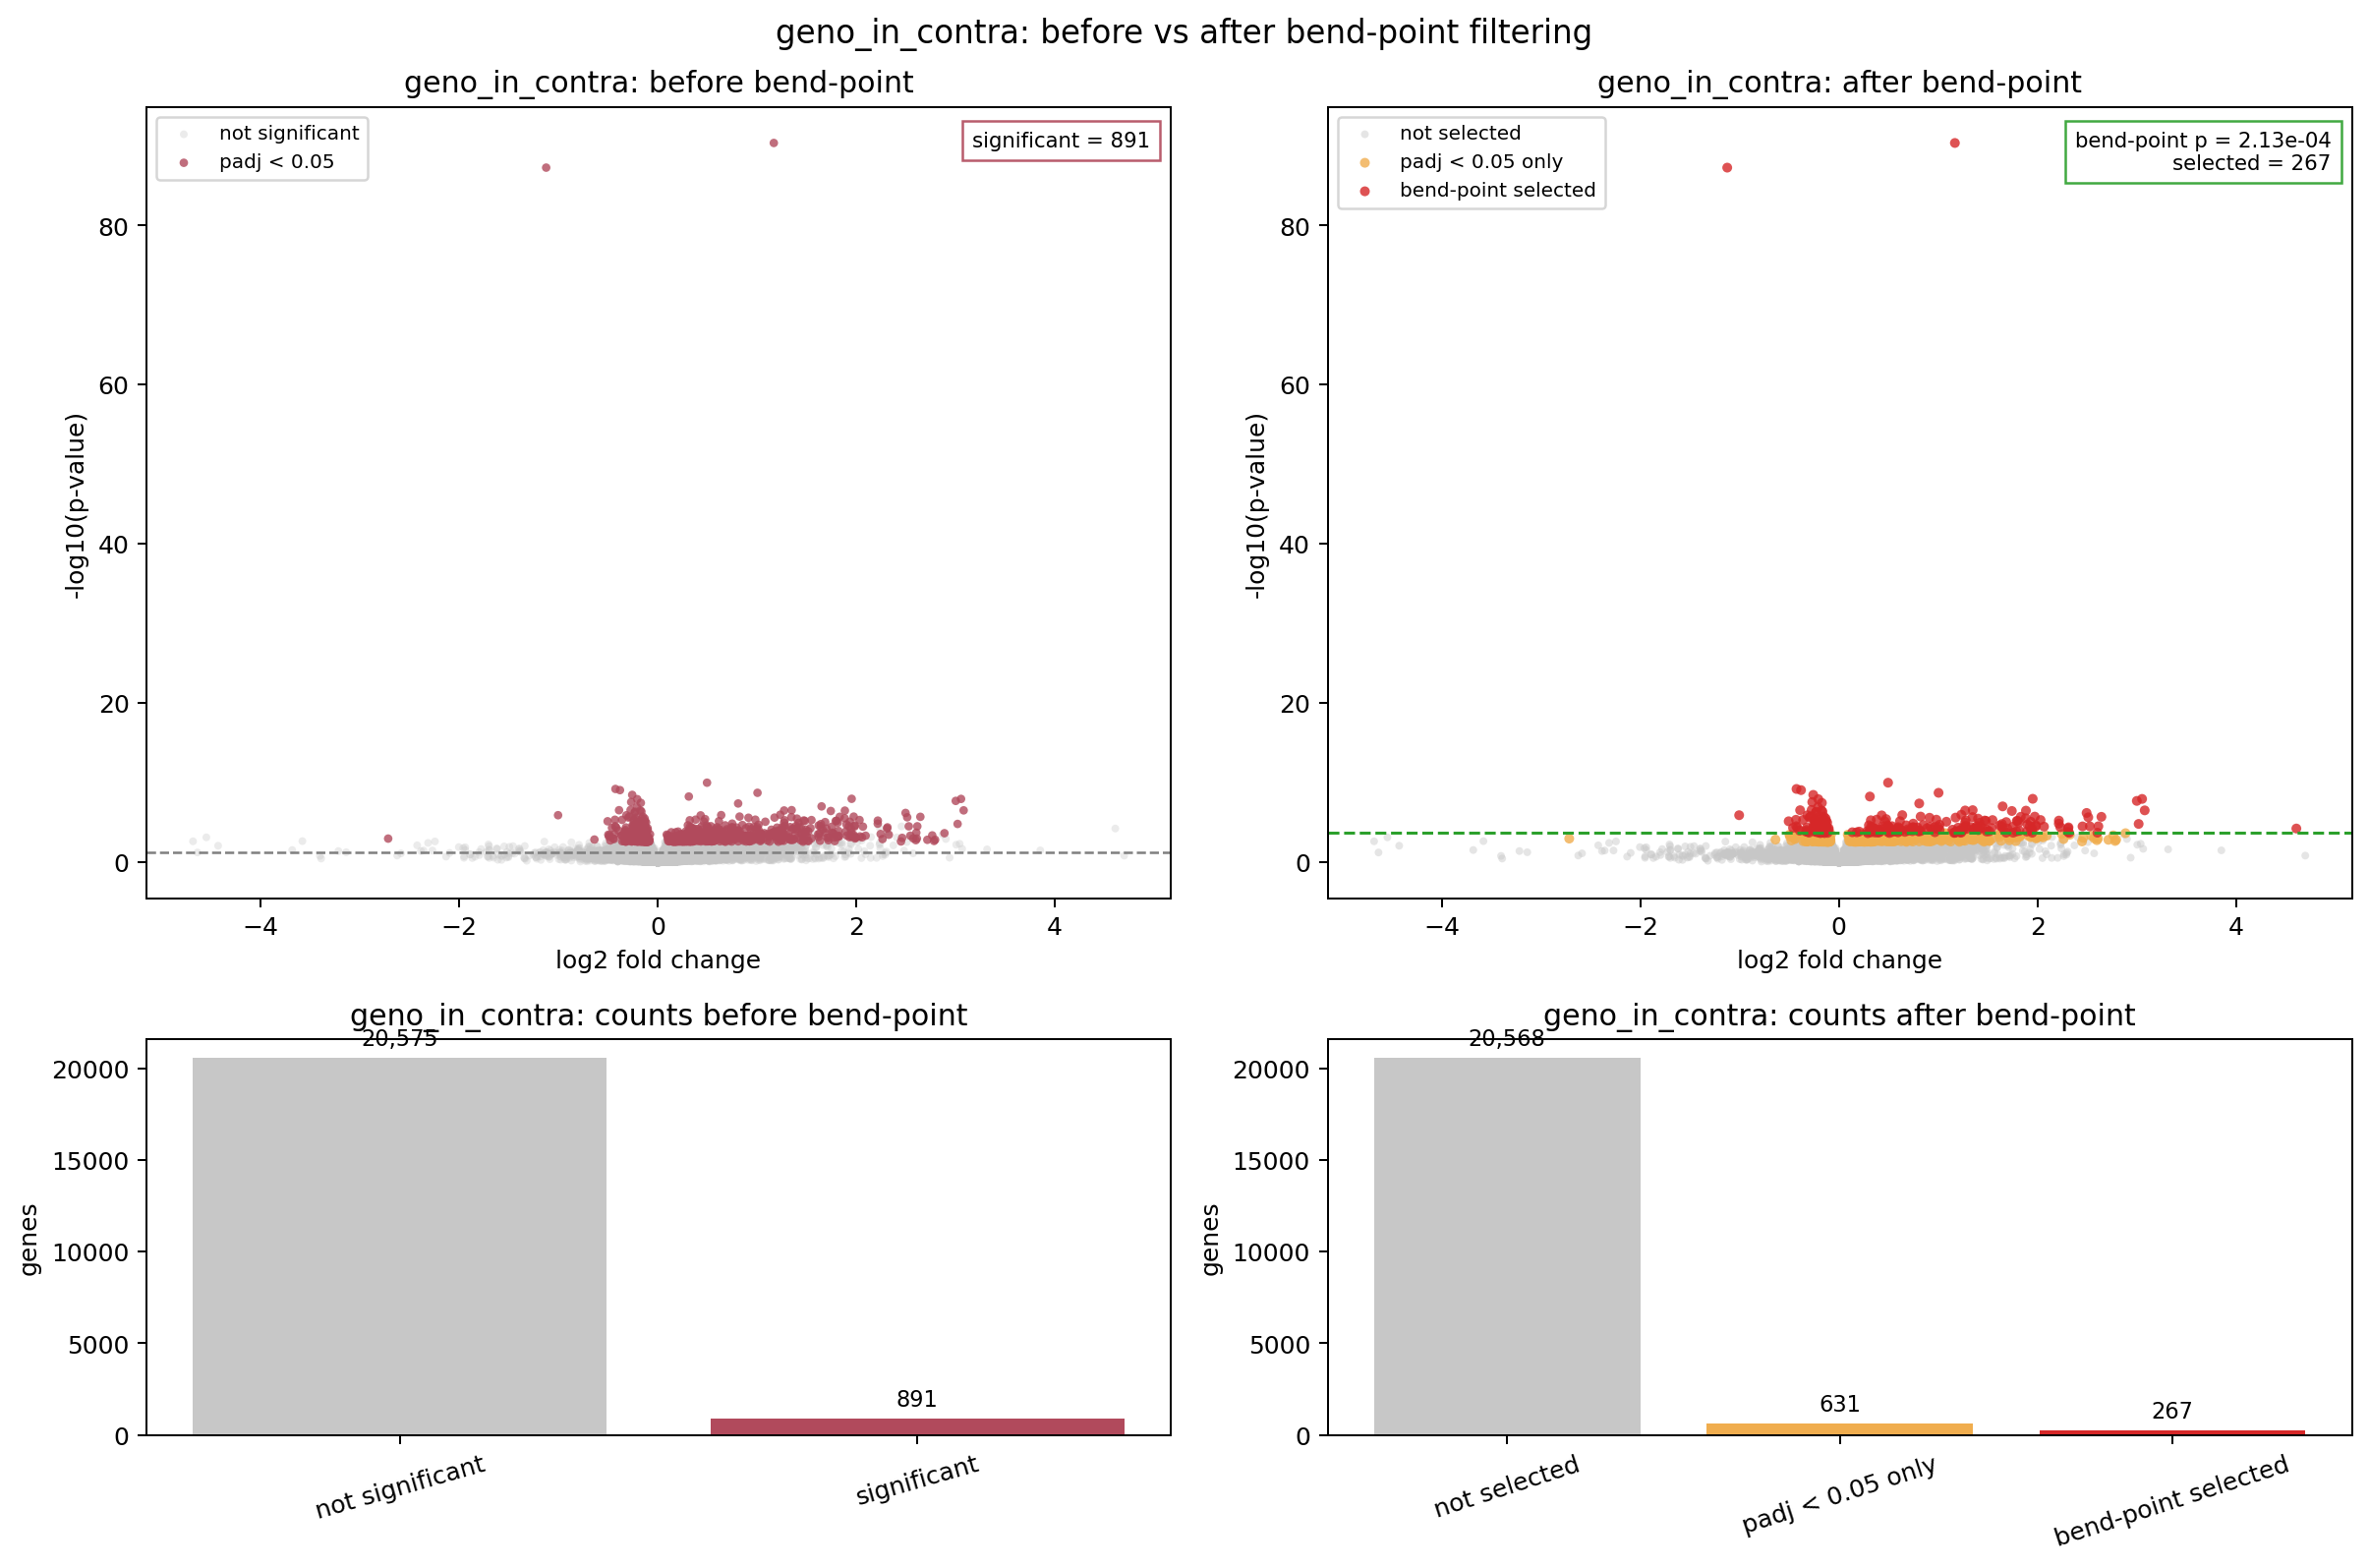

In [54]:
display(Image(filename=str(DERIVED_DIR / 'geno_in_contra' / 'before_after_selection_comparison.png'), width=1000))

**What we did:** Displayed the combined before/after comparison grid for `geno_in_contra`.

**Why it matters:** The top row compares the raw genotype volcano against the bend-point-filtered version, and the bottom row shows the matching count change. That makes the secondary genotype signal easier to read without confusing weaker with zero.

In [55]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_contra' / 'bendpoint_summary.tsv', sep='\t'))

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,geno_in_contra,21466,891,0.000213,267


**What we did:** Displayed the bend-point summary table for `geno_in_contra`.

**Why it matters:** This shows the genotype contrast now has a transcript-aligned narrowed set of `267` genes rather than only a padj-defined set of `891`, which makes it easier to compare against the main side-specific branches.

### Bend-point-selected genes preview — `geno_in_contra`

In [56]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_contra' / 'selected_genes_bendpoint.tsv', sep='\t').head(20))

,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000032011,4.329322e-91,7.312658e-87,1.167886,85101.054172,1,0.000000,90.363580,0.000000,True
1,ENSMUSG00000054423,5.428531e-88,4.584666e-84,-1.125242,26411.196648,2,0.000047,87.265318,0.034238,True
2,ENSMUSG00000071547,9.856686e-11,5.549643e-07,0.494899,290.058023,3,0.000093,10.006269,0.889119,True
3,ENSMUSG00000037428,6.029351e-10,2.546044e-06,-0.427349,16683.752209,4,0.000140,9.219729,0.897776,True
4,ENSMUSG00000021721,8.455688e-10,2.856500e-06,-0.381872,736.109370,5,0.000186,9.072851,0.899355,True
5,ENSMUSG00000066113,1.835970e-09,5.168561e-06,1.003391,343.552194,6,0.000233,8.736135,0.903034,True
6,ENSMUSG00000021675,3.332729e-09,8.041875e-06,-0.258542,6807.005301,7,0.000280,8.477200,0.905853,True
7,ENSMUSG00000034910,5.399490e-09,1.140035e-05,0.311732,626.124838,8,0.000326,8.267647,0.908125,True
8,ENSMUSG00000037362,1.039161e-08,1.766397e-05,1.951837,3474.041675,9,0.000373,7.983317,0.911225,True
9,ENSMUSG00000039084,1.076337e-08,1.766397e-05,3.053604,281.172985,10,0.000419,7.968052,0.911347,True


**What we did:** Previewed the bend-point-selected `geno_in_contra` genes.

**Why it matters:** This is now the default genotype gene set for enrichment and story triage.

### Standalone volcano + count view — `geno_in_ipsi`


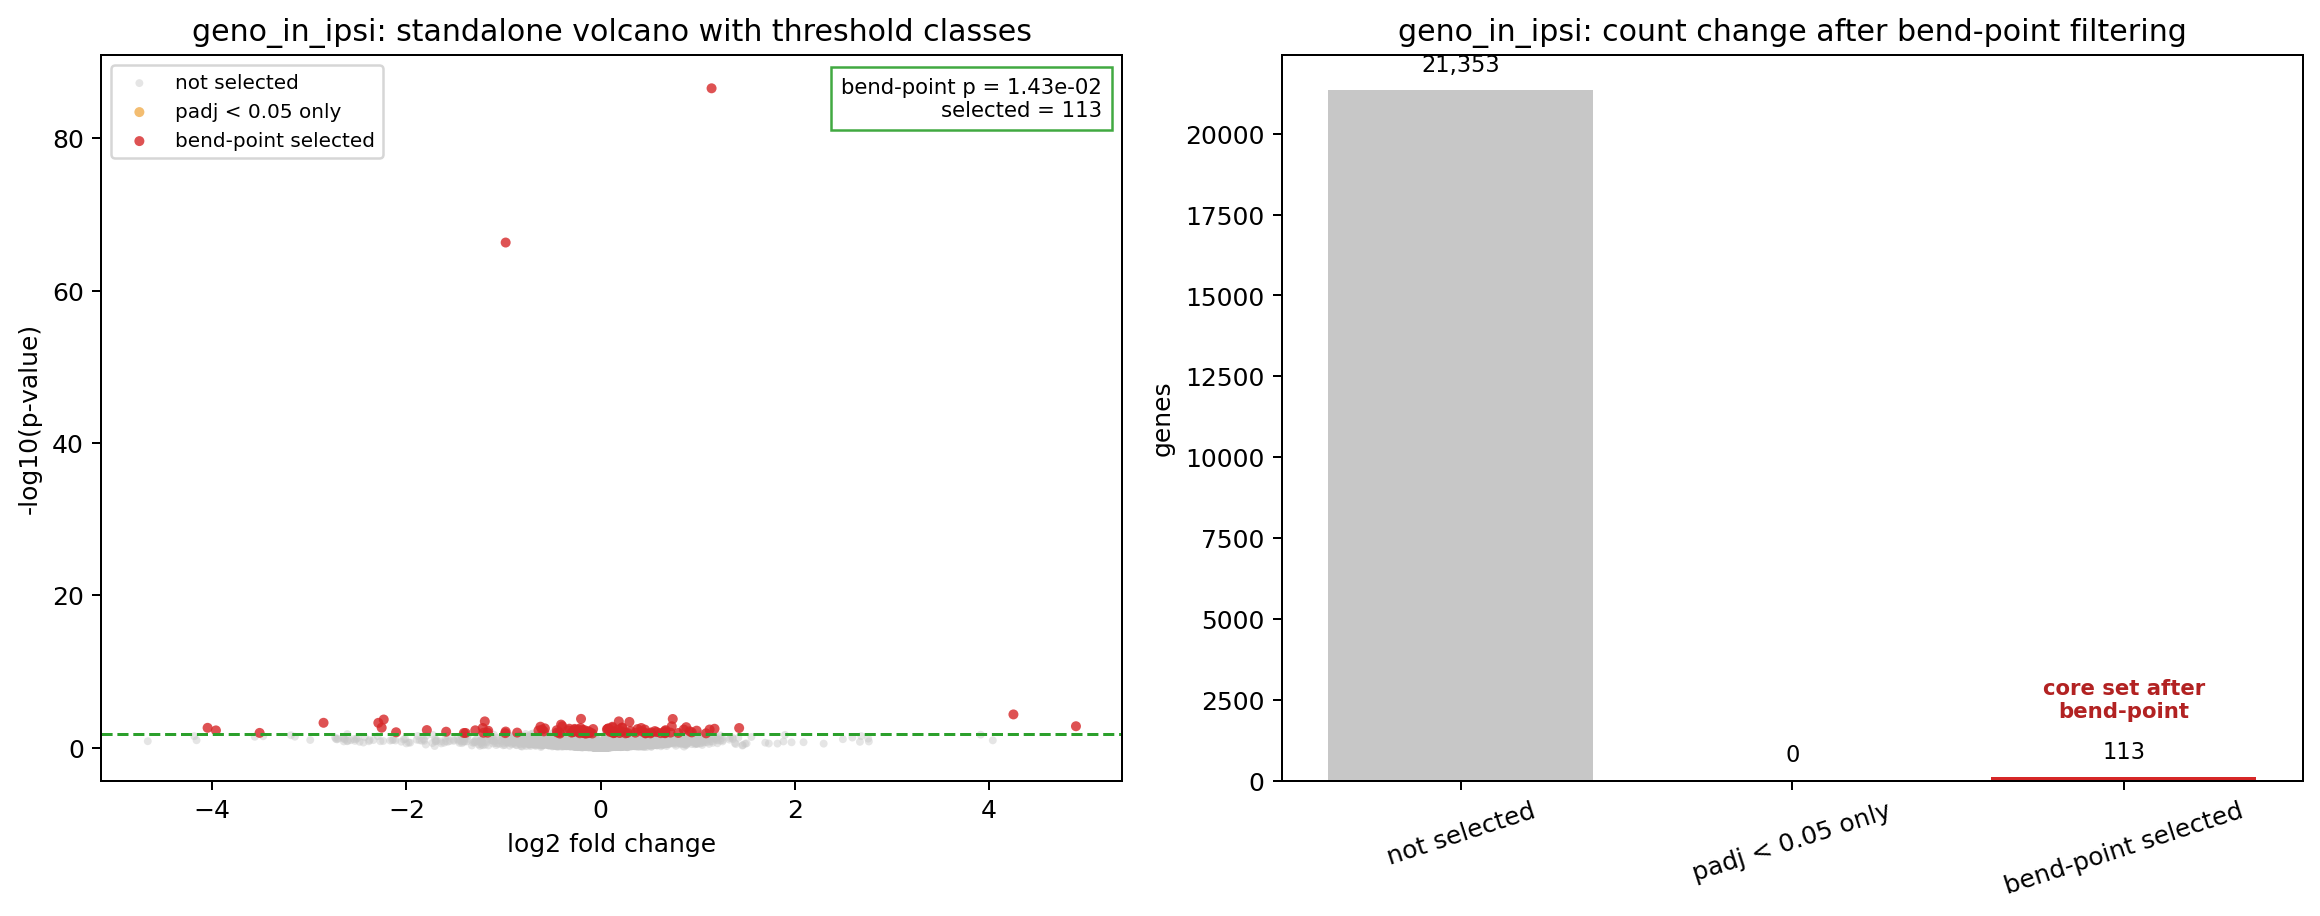

In [57]:
display(HTML((DERIVED_DIR / 'geno_in_ipsi' / 'volcano_with_counts.html').read_text()))

**What we did:** Displayed the standalone volcano and count breakdown for `geno_in_ipsi`.

**Why it matters:** This standalone genotype view keeps the weaker branch readable on its own before the threshold comparison.

### Bend-point summary table — `geno_in_ipsi`

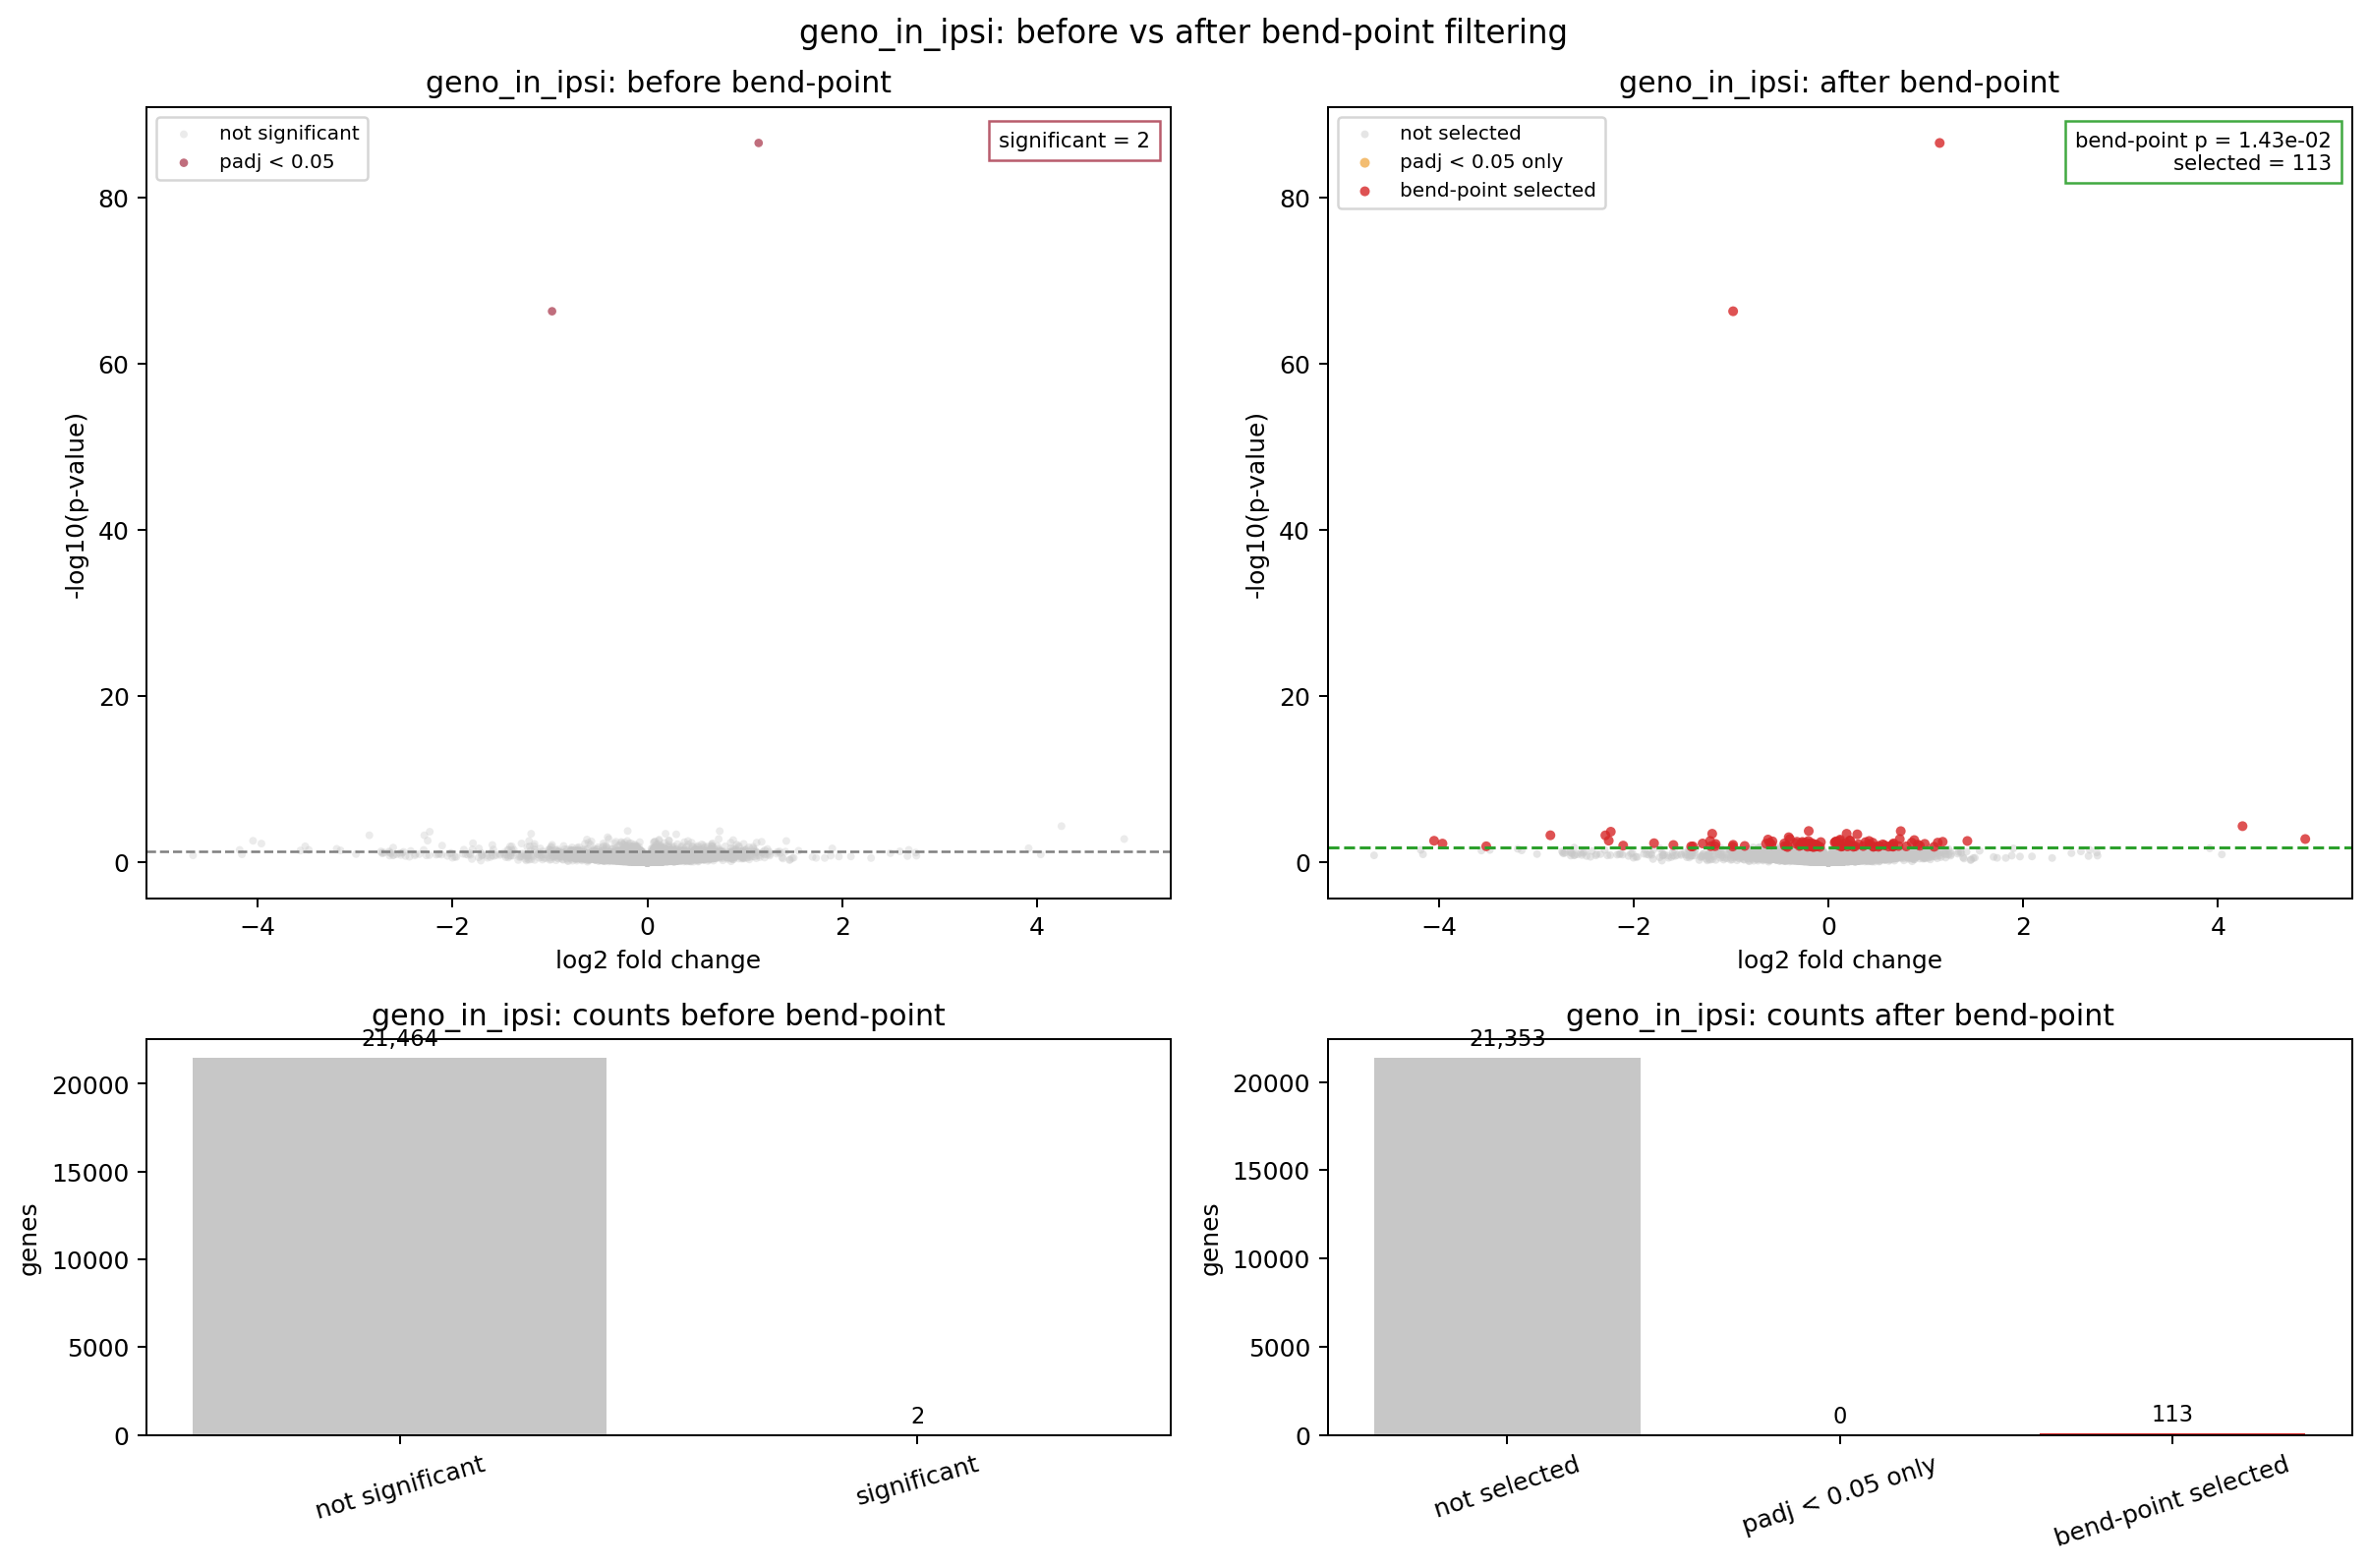

In [58]:
display(Image(filename=str(DERIVED_DIR / 'geno_in_ipsi' / 'before_after_selection_comparison.png'), width=1000))

**What we did:** Displayed the combined before/after comparison grid for `geno_in_ipsi`.

**Why it matters:** The same before/after layout helps us inspect the weaker ipsilateral genotype branch carefully. We can see the raw signal first, then the narrowed follow-up subset, without pretending that the two tell the same story.

In [59]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_ipsi' / 'bendpoint_summary.tsv', sep='\t'))

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,geno_in_ipsi,21466,2,0.014343,113


**What we did:** Displayed the bend-point summary table for `geno_in_ipsi`.

**Why it matters:** Even though only `2` genes are padj-significant, the bend-point curve still defines a wider follow-up set of `113` genes, which is useful for exploration but should be interpreted cautiously.

### Bend-point-selected genes preview — `geno_in_ipsi`

In [60]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_ipsi' / 'selected_genes_bendpoint.tsv', sep='\t').head(20))

,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000032011,2.720970e-87,5.840834e-83,1.142676,85101.054172,1,0.000000,86.565276,0.000000,True
1,ENSMUSG00000054423,4.840439e-67,5.195243e-63,-0.978033,26411.196648,2,0.000047,66.315115,0.233867,True
2,ENSMUSG00000083623,4.389208e-05,3.140625e-01,4.251727,7.871461,3,0.000093,4.357614,0.949505,True
3,ENSMUSG00000072676,1.685846e-04,7.356920e-01,-0.201865,4424.594137,4,0.000140,3.773182,0.956209,True
4,ENSMUSG00000138276,1.743962e-04,7.356920e-01,0.742814,66.252704,5,0.000186,3.758463,0.956332,True
5,ENSMUSG00000032517,2.056346e-04,7.356920e-01,-2.234049,57.937037,6,0.000233,3.686904,0.957112,True
6,ENSMUSG00000021843,3.599257e-04,9.693238e-01,0.187286,6721.748280,7,0.000280,3.443787,0.959874,True
7,ENSMUSG00000055945,3.612499e-04,9.693238e-01,-1.192919,17.406644,8,0.000326,3.442192,0.959846,True
8,ENSMUSG00000037126,4.234832e-04,9.999588e-01,0.296779,640.563025,9,0.000373,3.373164,0.960597,True
9,ENSMUSG00000058626,5.514722e-04,9.999588e-01,-2.853836,53.934158,10,0.000419,3.258476,0.961875,True


**What we did:** Previewed the bend-point-selected `geno_in_ipsi` genes.

**Why it matters:** This keeps the weaker genotype branch documented while making it clear that it is exploratory rather than the default secondary story.

### Standalone volcano + count view — `interaction`


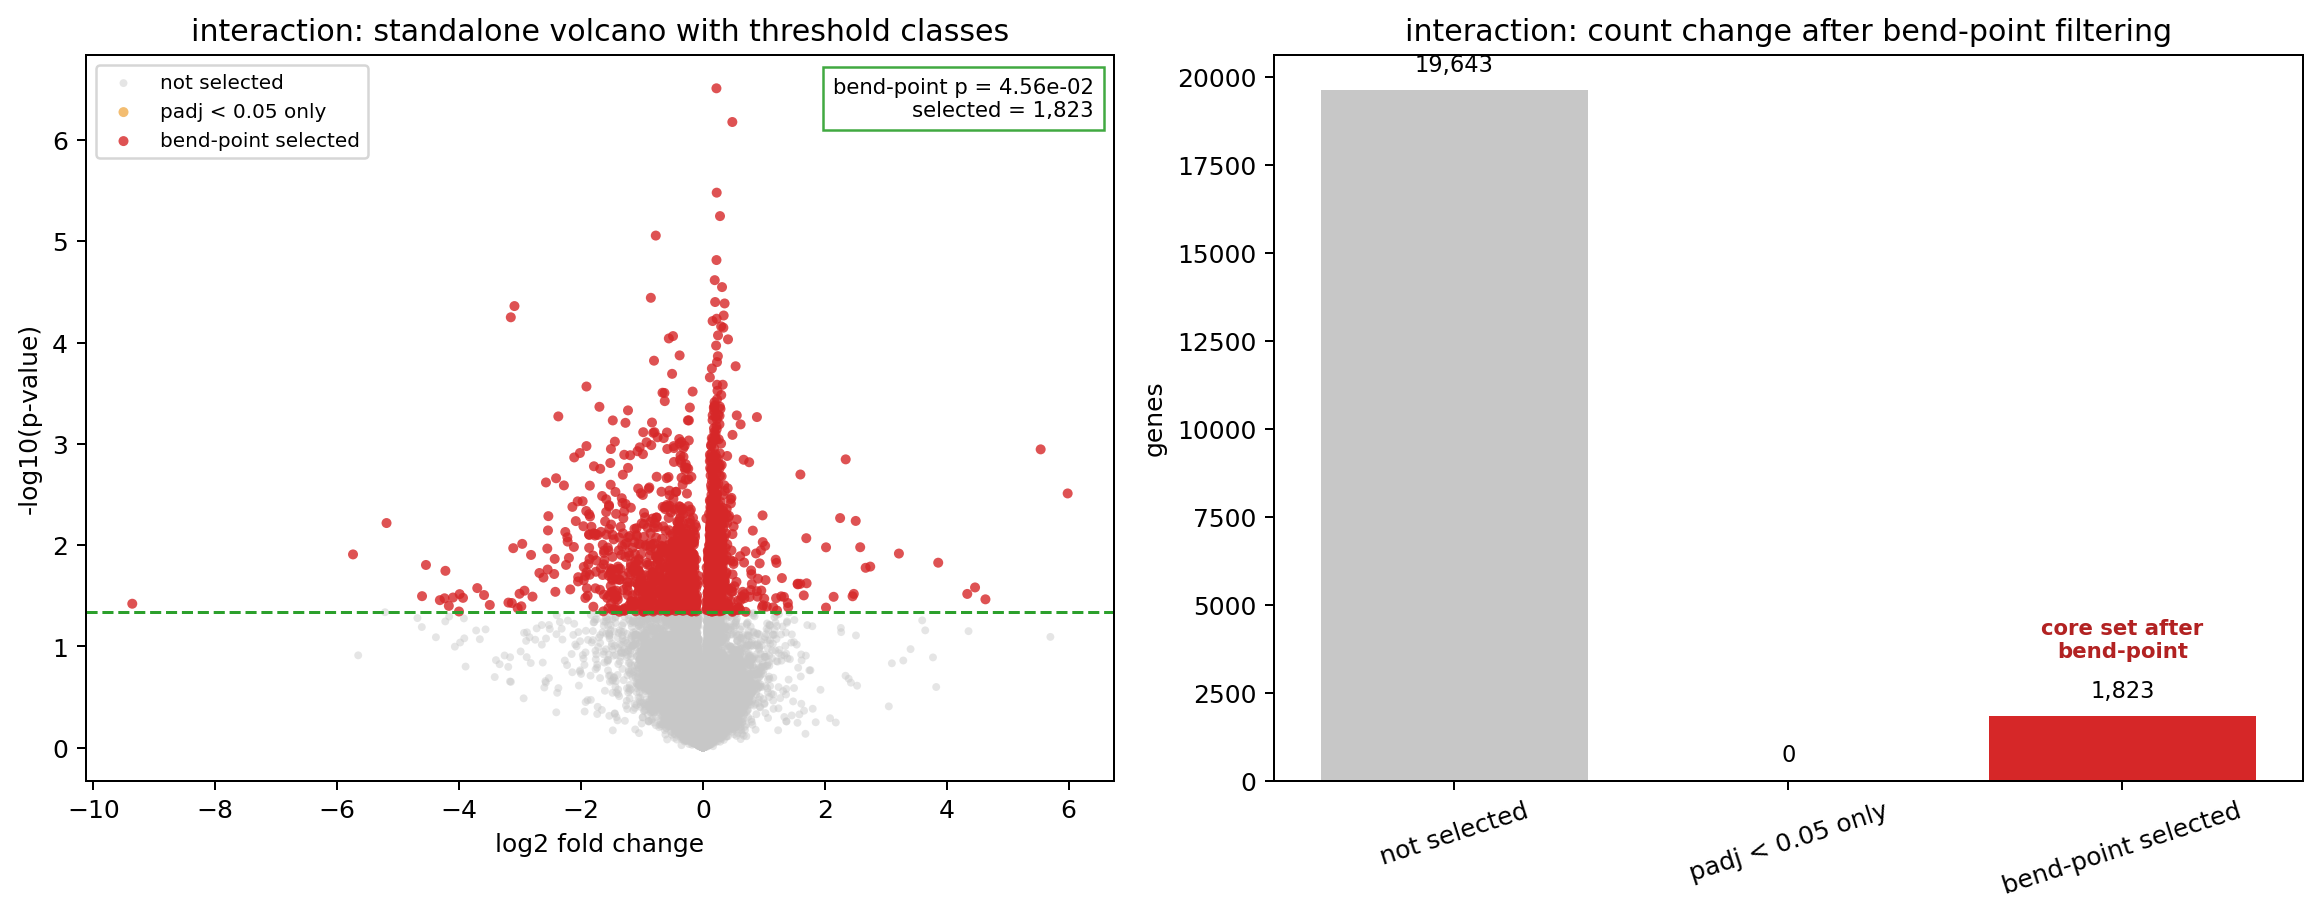

In [61]:
display(HTML((DERIVED_DIR / 'interaction' / 'volcano_with_counts.html').read_text()))

**What we did:** Displayed the standalone volcano and count breakdown for `interaction`.

**Why it matters:** This standalone interaction view lets us inspect the raw interaction result separately from the threshold comparison.

### Bend-point summary table — `interaction`

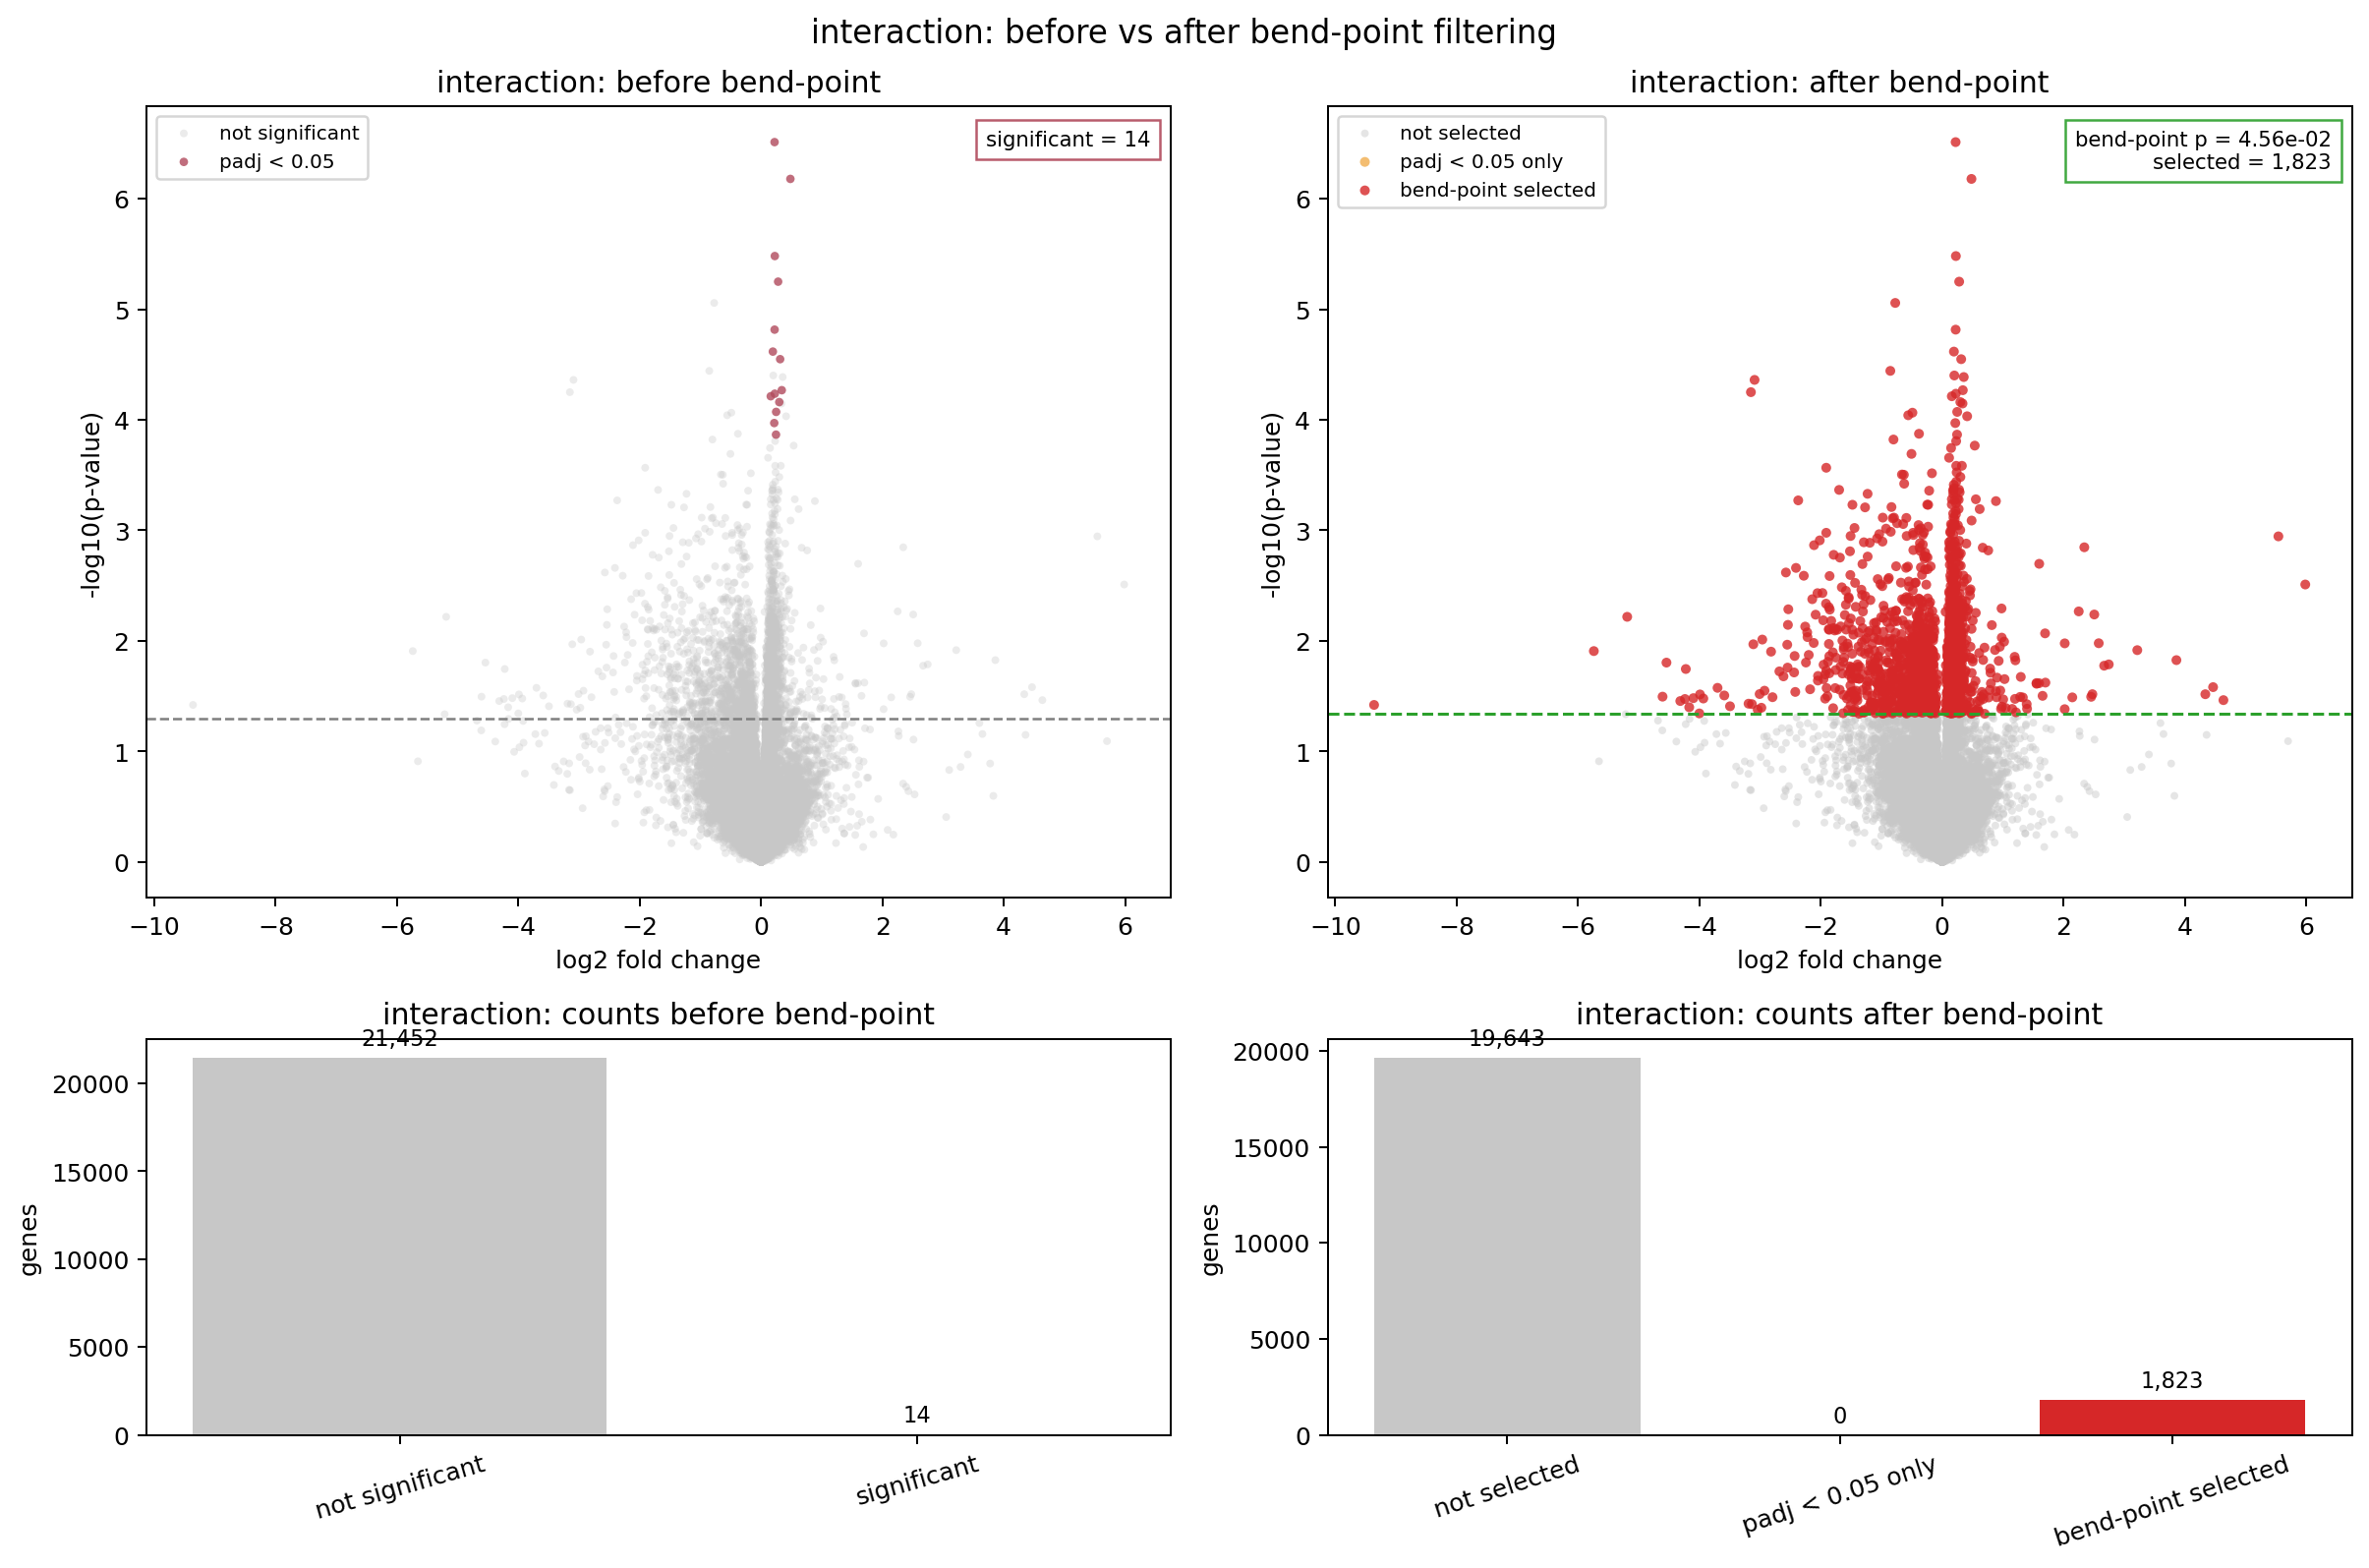

In [62]:
display(Image(filename=str(DERIVED_DIR / 'interaction' / 'before_after_selection_comparison.png'), width=1000))

**What we did:** Displayed the combined before/after comparison grid for `interaction`.

**Why it matters:** This layout makes the interaction branch easier to sanity-check because it shows both the original volcano and the bend-point-filtered view, plus the counts that explain how sharply the threshold changes the follow-up set.

In [63]:
display(pd.read_csv(DERIVED_DIR / 'interaction' / 'bendpoint_summary.tsv', sep='\t'))

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,interaction,21466,14,0.045648,1823


**What we did:** Displayed the bend-point summary table for `interaction`.

**Why it matters:** The interaction contrast has only `14` padj-significant genes but a much larger bend-point-selected set (`1823`), so this branch needs especially careful sanity checks before we promote it into the weekly report story.

### Bend-point-selected genes preview — `interaction`

In [64]:
display(pd.read_csv(DERIVED_DIR / 'interaction' / 'selected_genes_bendpoint.tsv', sep='\t').head(20))

,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000032939,3.083204e-07,0.001487,0.222094,6348.760480,1,0.000000,6.510998,0.000000,True
1,ENSMUSG00000037428,6.634146e-07,0.001600,0.482914,16683.752209,2,0.000047,6.178215,0.050473,True
2,ENSMUSG00000045136,3.307544e-06,0.005317,0.226333,30567.184825,3,0.000093,5.480494,0.156346,True
3,ENSMUSG00000021675,5.637171e-06,0.006797,0.280766,6807.005301,4,0.000140,5.248939,0.191452,True
4,ENSMUSG00000060548,8.778446e-06,NaN,-0.772977,203.585850,5,0.000186,5.056582,0.220607,True
5,ENSMUSG00000062542,1.531333e-05,0.014771,0.222841,10768.628830,6,0.000233,4.814930,0.257245,True
6,ENSMUSG00000031934,2.418633e-05,0.019442,0.193999,4859.374876,7,0.000280,4.616430,0.287333,True
7,ENSMUSG00000028381,2.831920e-05,0.019512,0.314065,8504.028095,8,0.000326,4.547919,0.297687,True
8,ENSMUSG00000040732,3.613008e-05,NaN,-0.853894,264.589642,9,0.000373,4.442131,0.313701,True
9,ENSMUSG00000042487,3.977097e-05,NaN,0.200977,1850.217034,10,0.000419,4.400434,0.319984,True


**What we did:** Previewed the bend-point-selected `interaction` genes.

**Why it matters:** This makes the interaction follow-up explicit, but it remains exploratory because the selected set is much broader than the padj-significant set.

## GO / pathway enrichment follow-up

### Top enrichment terms — `ipsi_vs_contra_in_ff`

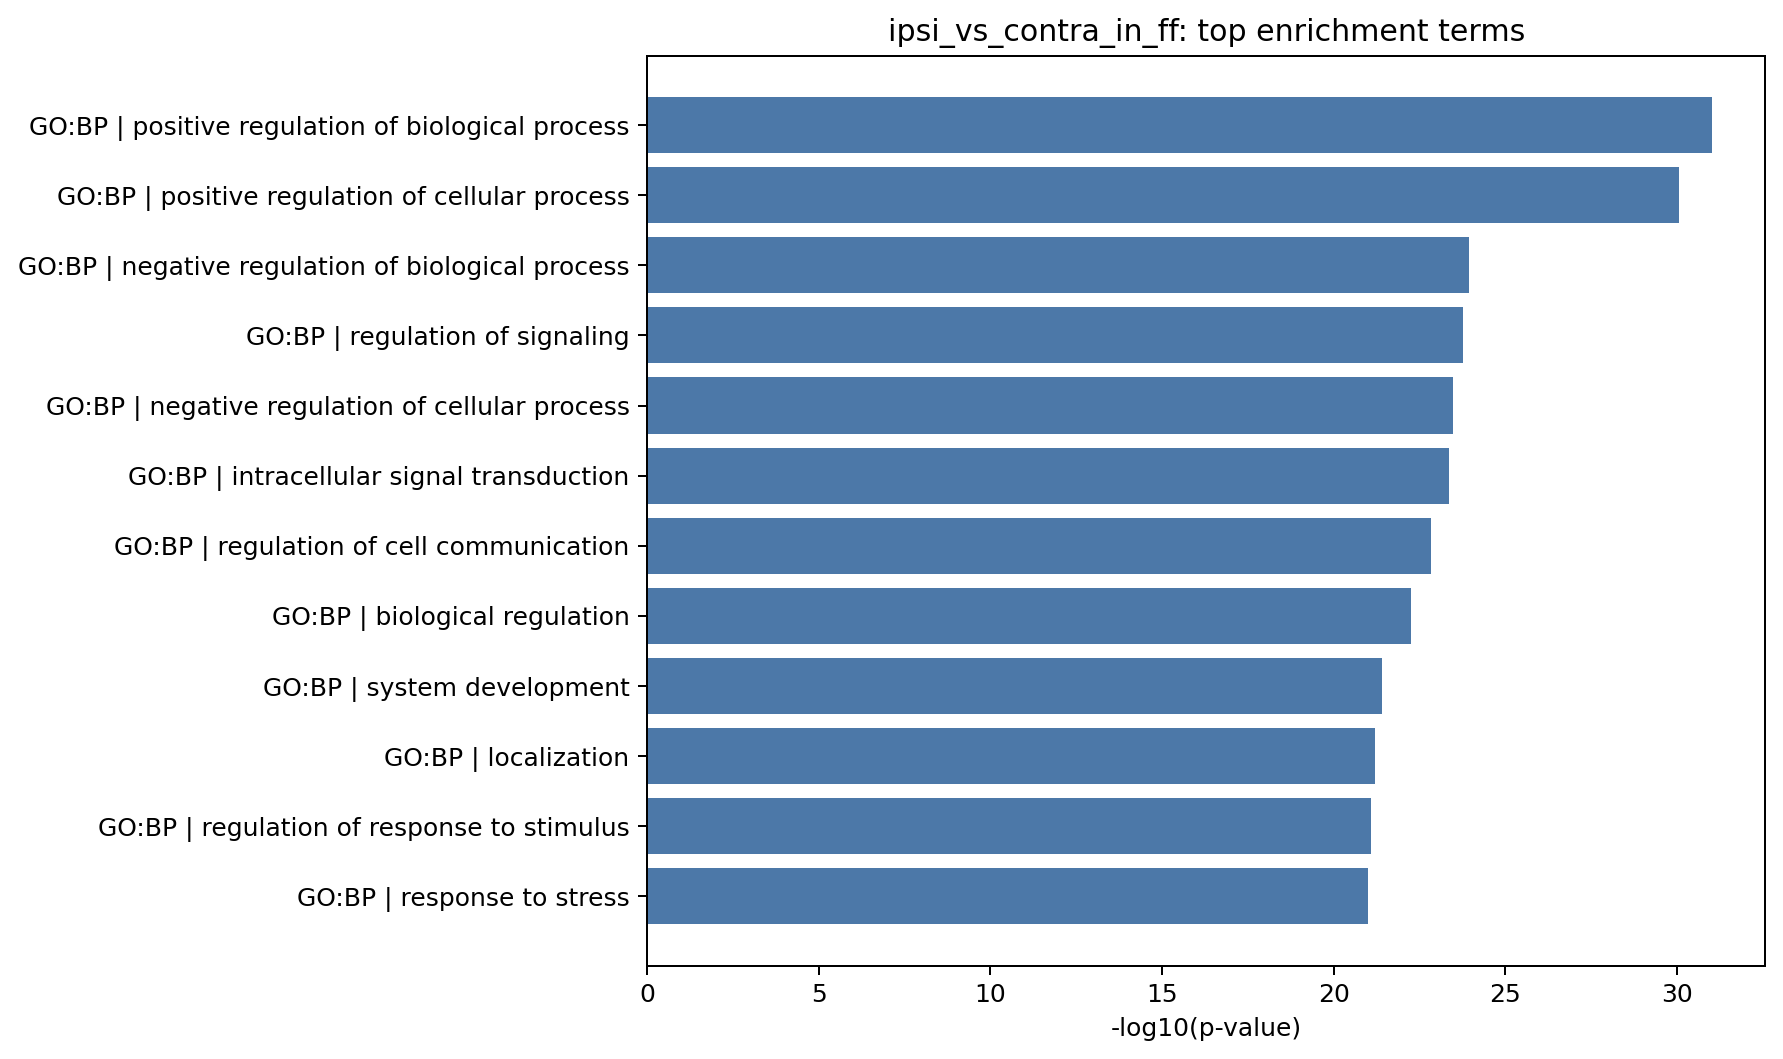

In [65]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_top_terms.png'), width=1000))

**What we did:** Displayed the top g:Profiler enrichment terms for the bend-point-selected `ipsi_vs_contra_in_ff` genes.

**Why it matters:** The enrichment was run on the bend-point-filtered gene set so the interpretation stays tied to a principled narrowing rule. The top terms emphasize regulation, signaling, and developmental/localization processes, which gives us candidate biological themes for the weekly report.

### Enrichment companion views — `ipsi_vs_contra_in_ff`

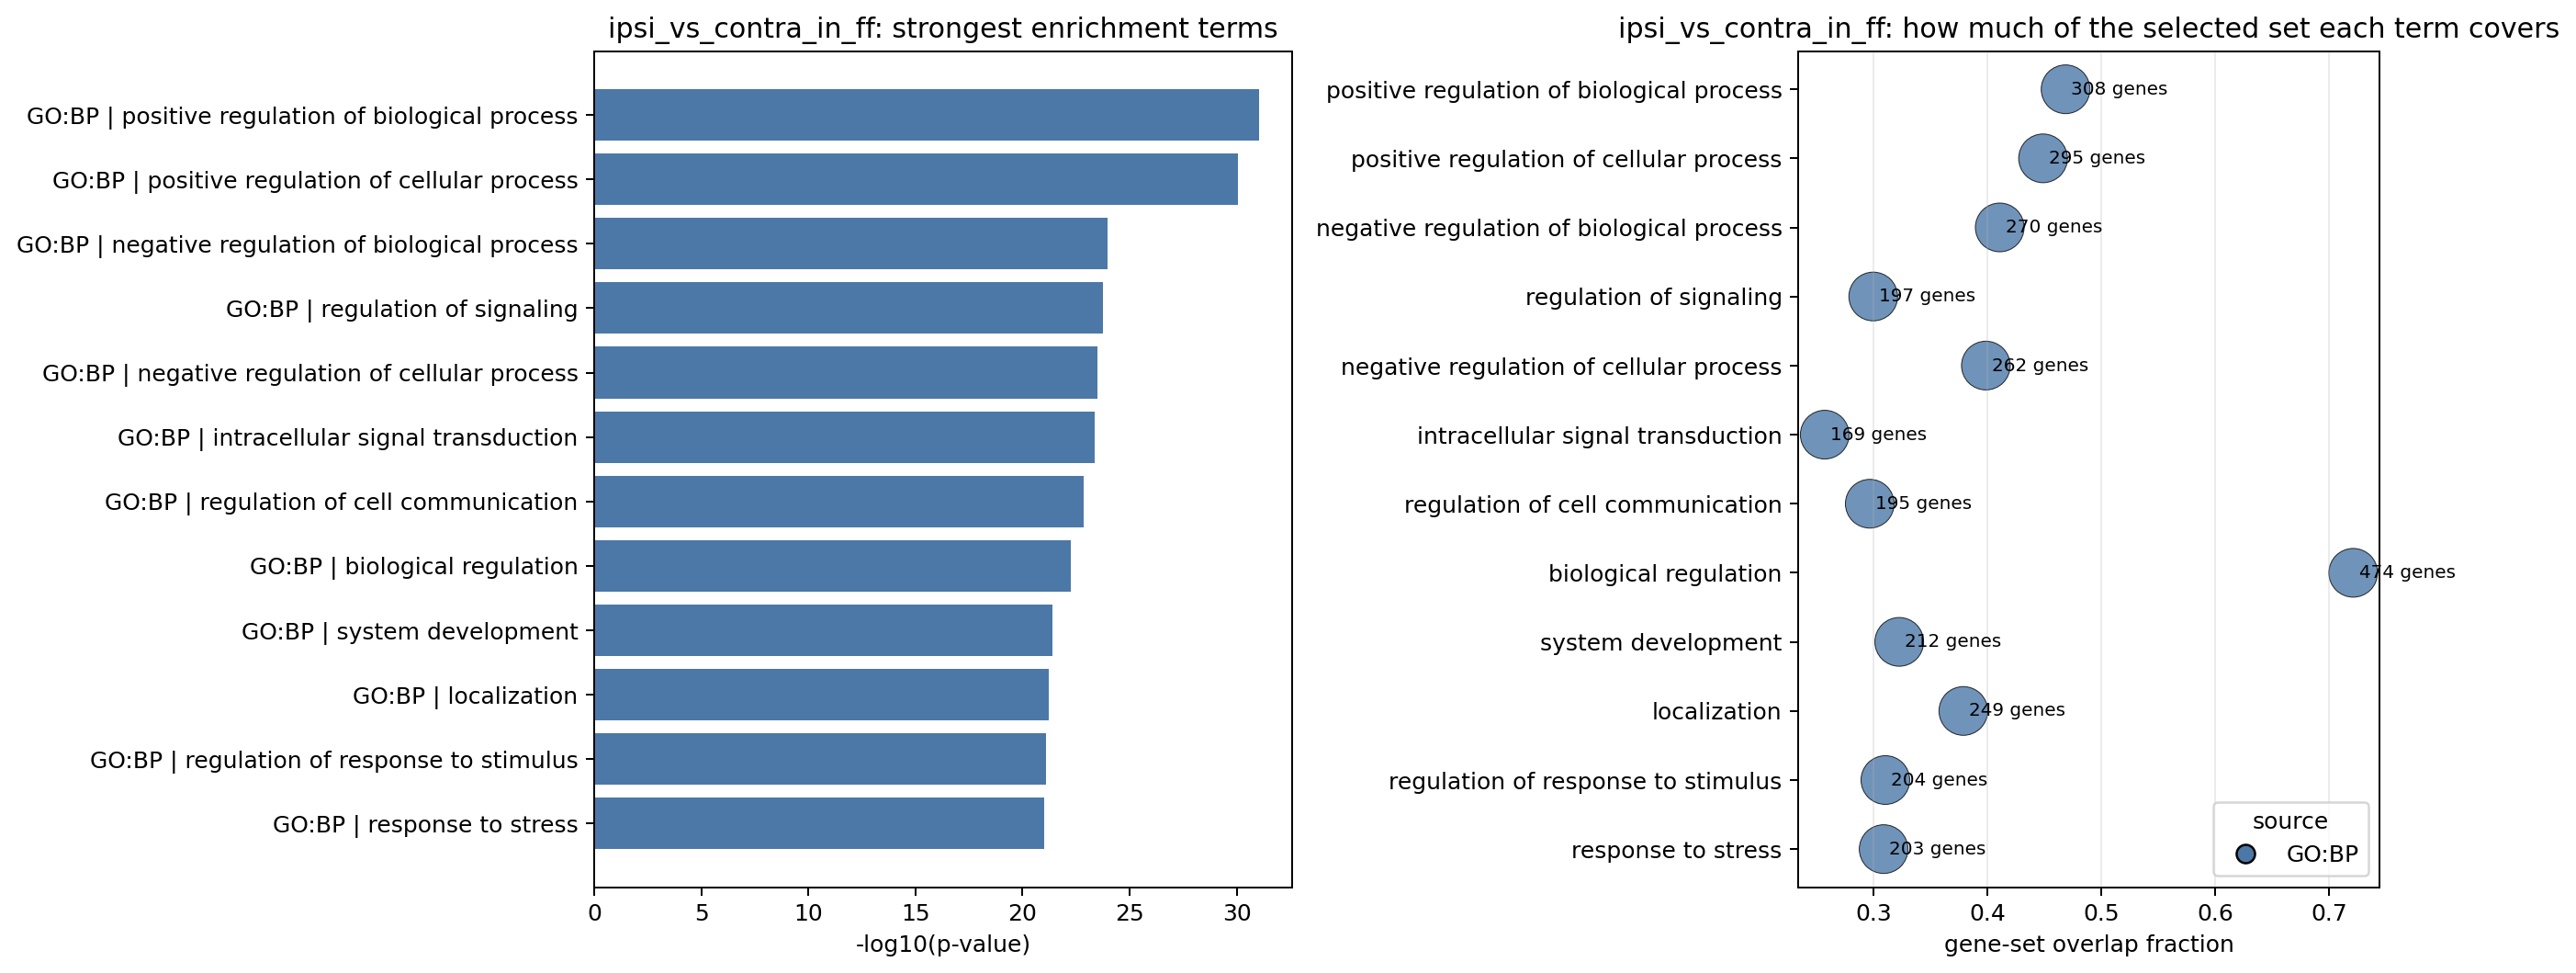

In [66]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_terms_and_overlap.png'), width=1200))

**What we did:** Displayed a companion enrichment figure for `ipsi_vs_contra_in_ff` that pairs the ranked-term summary with an overlap-focused view.

**Why it matters:** The left panel still shows which terms are strongest, while the right panel shows how much of the selected gene set each term actually covers and which source it came from. This helps us judge meaning, not just significance.

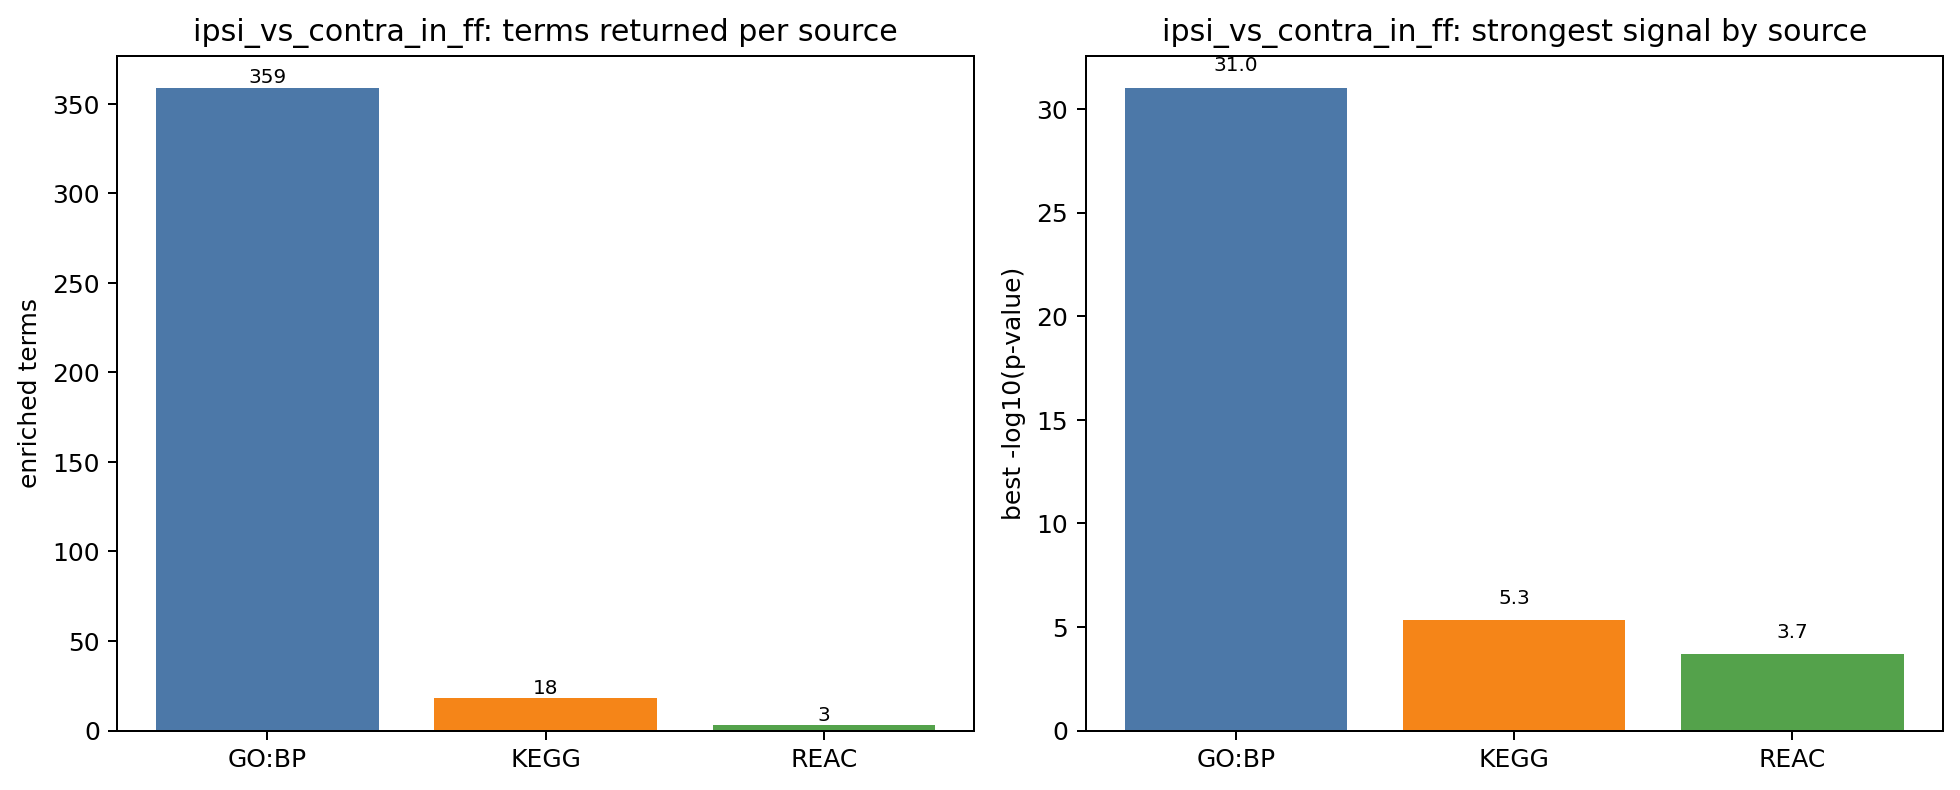

In [67]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_source_summary.png'), width=950))

**What we did:** Displayed a source-level enrichment summary for `ipsi_vs_contra_in_ff`.

**Why it matters:** This gives us a fast comparison of how much signal comes from `GO:BP`, `KEGG`, and `REAC`, which helps us decide which enrichment view is most report-worthy and whether the story is dominated by one source or replicated across several sources.

### Enrichment table preview — `ipsi_vs_contra_in_ff`

In [68]:
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_enrichment.tsv', sep='	').head(20))

,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0048518,positive regulation of biological process,9.427224e-32,6447,657,308,25907,"['GO:0008150', 'GO:0050789']"
1,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0048522,positive regulation of cellular process,8.454629e-31,6095,657,295,25907,"['GO:0009987', 'GO:0048518', 'GO:0050794']"
2,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0048519,negative regulation of biological process,1.114633e-24,5759,657,270,25907,"['GO:0008150', 'GO:0050789']"
3,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0023051,regulation of signaling,1.717882e-24,3558,657,197,25907,"['GO:0023052', 'GO:0050789']"
4,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0048523,negative regulation of cellular process,3.268086e-24,5540,657,262,25907,"['GO:0009987', 'GO:0048519', 'GO:0050794']"
5,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0035556,intracellular signal transduction,4.320748e-24,2810,657,169,25907,['GO:0007165']
6,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0010646,regulation of cell communication,1.429176e-23,3560,657,195,25907,"['GO:0007154', 'GO:0050794']"
7,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0065007,biological regulation,5.557276e-23,13503,657,474,25907,['GO:0008150']
8,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0048731,system development,3.999491e-22,4155,657,212,25907,"['GO:0007275', 'GO:0048856']"
9,ipsi_vs_contra_in_ff,bend-point selected genes,GO:BP,GO:0051179,localization,6.068204e-22,5309,657,249,25907,['GO:0008150']


**What we did:** Displayed the enrichment table preview for `ipsi_vs_contra_in_ff`.

**Why it matters:** This table records the exact terms, sources, and overlap sizes behind the summarized plot so we can pick the most convincing terms for reporting.

### Direction-split enrichment — `ipsi_vs_contra_in_ff`

,set,n_genes
0,selected,709
1,up (log2FC > 0),607
2,down (log2FC < 0),102
3,zero,0


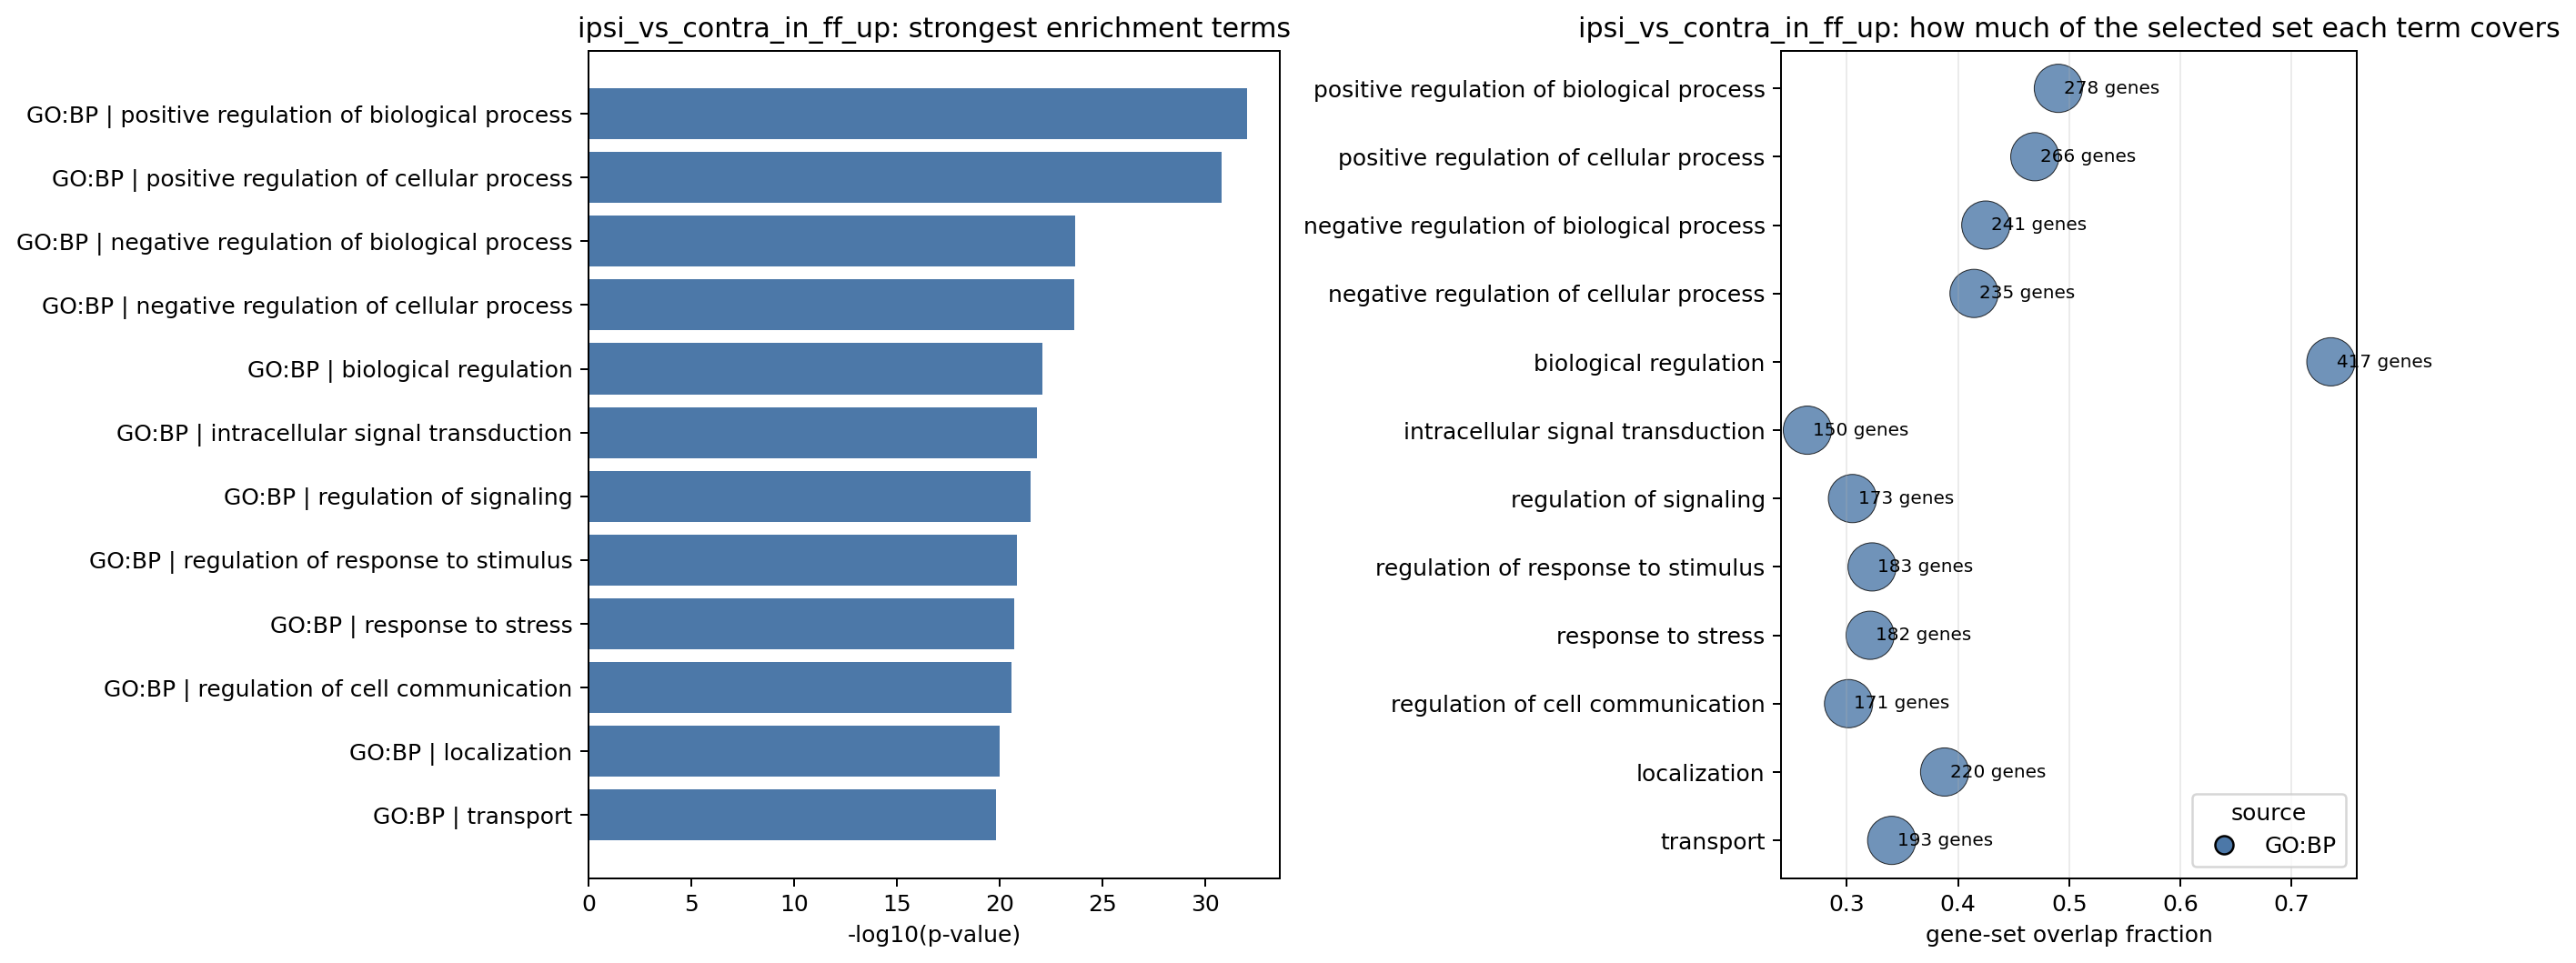

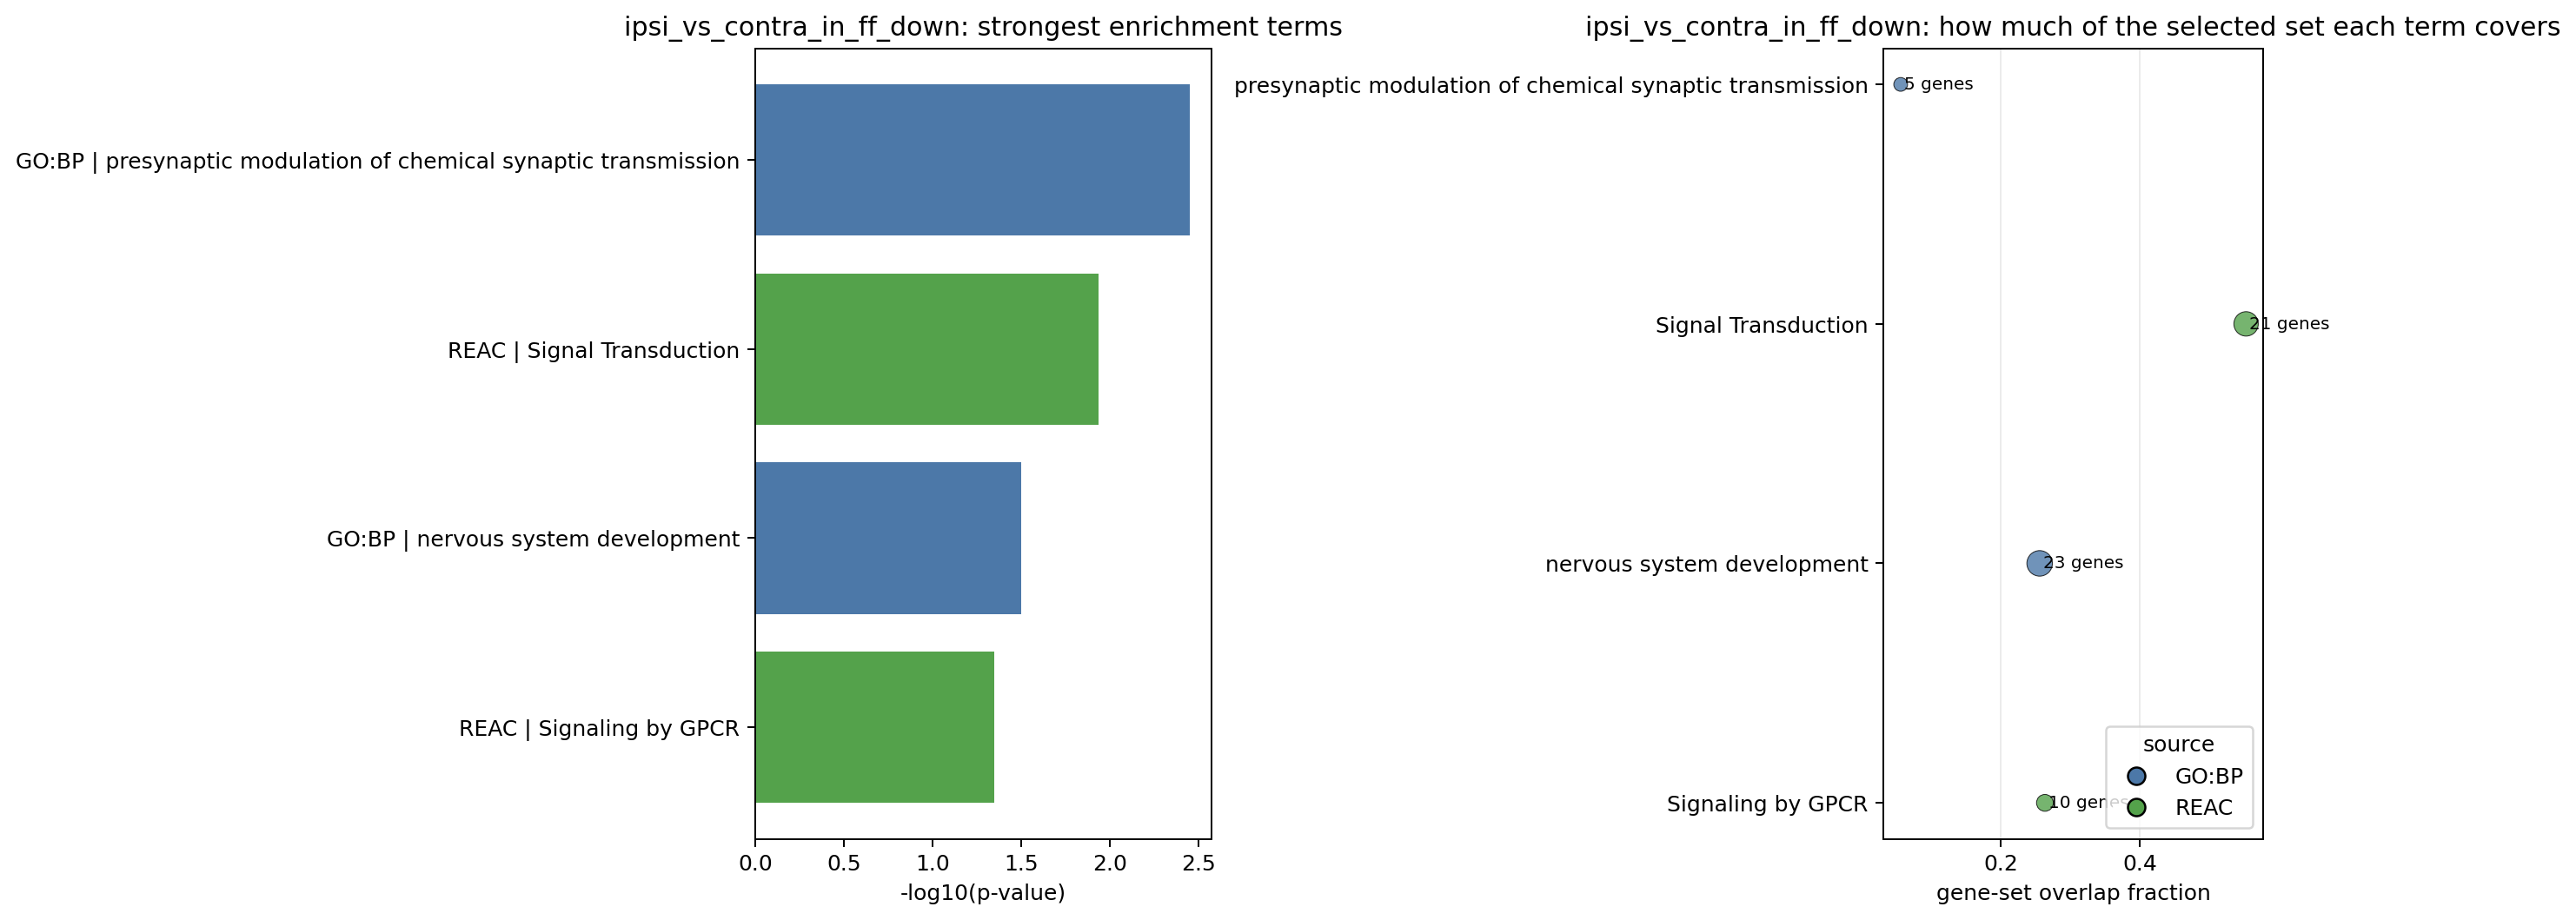

,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048518,positive regulation of biological process,9.893579e-33,6447,567,278,25907,"['GO:0008150', 'GO:0050789']"
1,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048522,positive regulation of cellular process,1.628116e-31,6095,567,266,25907,"['GO:0009987', 'GO:0048518', 'GO:0050794']"
2,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048519,negative regulation of biological process,2.298483e-24,5759,567,241,25907,"['GO:0008150', 'GO:0050789']"
3,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048523,negative regulation of cellular process,2.389344e-24,5540,567,235,25907,"['GO:0009987', 'GO:0048519', 'GO:0050794']"
4,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0065007,biological regulation,8.504132e-23,13503,567,417,25907,['GO:0008150']
5,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0035556,intracellular signal transduction,1.540069e-22,2810,567,150,25907,['GO:0007165']
6,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0023051,regulation of signaling,3.060739e-22,3558,567,173,25907,"['GO:0023052', 'GO:0050789']"
7,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048583,regulation of response to stimulus,1.423328e-21,3939,567,183,25907,"['GO:0050789', 'GO:0050896']"
8,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0006950,response to stress,2.020976e-21,3917,567,182,25907,['GO:0050896']
9,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0010646,regulation of cell communication,2.630694e-21,3560,567,171,25907,"['GO:0007154', 'GO:0050794']"


,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),GO:BP,GO:0099171,presynaptic modulation of chemical synaptic tr...,0.003540,60,90,5,25907,['GO:0050804']
1,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),REAC,REAC:R-MMU-162582,Signal Transduction,0.011534,2073,38,21,8469,['REAC:0000000']
2,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),GO:BP,GO:0007399,nervous system development,0.031554,2593,90,23,25907,['GO:0048731']
3,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),REAC,REAC:R-MMU-372790,Signaling by GPCR,0.044729,581,38,10,8469,['REAC:R-MMU-162582']


In [69]:
ff = pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'selected_genes_bendpoint.tsv', sep='\t')

n_selected = int(len(ff))
n_up = int((ff['log2FoldChange'] > 0).sum())
n_down = int((ff['log2FoldChange'] < 0).sum())
n_zero = int((ff['log2FoldChange'] == 0).sum())

summary = pd.DataFrame(
    {
        'set': ['selected', 'up (log2FC > 0)', 'down (log2FC < 0)', 'zero'],
        'n_genes': [n_selected, n_up, n_down, n_zero],
    }
)
display(summary)

display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_terms_and_overlap_up.png'), width=1200))
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_terms_and_overlap_down.png'), width=1200))

display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_enrichment_up.tsv', sep='\t').head(10))
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_enrichment_down.tsv', sep='\t').head(10))

**What we did:** Split the bend-point-selected `ipsi_vs_contra_in_ff` genes by direction (up vs down `log2FoldChange`) and displayed enrichment summaries separately.

**Why it matters:** Enrichment can be misleading if opposite-direction genes are mixed in a single query set. In the FF branch, the upregulated side carries most of the interpretable pathway signal, so this split helps us keep the GO discussion defensible and reminds us to treat the weaker downregulated side more cautiously.

## Anchor-gene companion table — `ipsi_vs_contra_in_ff`

In [70]:
anchor_base = DERIVED_DIR / 'ipsi_vs_contra_in_ff'
anchor_df = pd.read_csv(anchor_base / 'selected_genes_bendpoint.tsv', sep='\t')
symbol_path = anchor_base / 'selected_genes_bendpoint_gene_symbols.tsv'
if symbol_path.exists():
    symbol_df = pd.read_csv(symbol_path, sep='\t').drop_duplicates('gene_id')
    anchor_df = anchor_df.merge(symbol_df, on='gene_id', how='left')
else:
    anchor_df['symbol'] = anchor_df['gene_id']
anchor_df['symbol'] = anchor_df['symbol'].fillna(anchor_df['gene_id'])
anchor_df['Direction'] = anchor_df['log2FoldChange'].gt(0).map({True: 'Upregulated', False: 'Downregulated'})
anchor_df['abs_log2FoldChange'] = anchor_df['log2FoldChange'].abs()

anchor_table = pd.concat([
    anchor_df[anchor_df['log2FoldChange'] > 0].sort_values(['padj', 'abs_log2FoldChange'], ascending=[True, False]).head(5),
    anchor_df[anchor_df['log2FoldChange'] < 0].sort_values(['padj', 'abs_log2FoldChange'], ascending=[True, False]).head(5),
], ignore_index=True).copy()
anchor_table['Gene symbol'] = anchor_table['symbol']
anchor_table['Gene ID'] = anchor_table['gene_id']
anchor_table['Selection note'] = 'top within bend-point core by padj'
anchor_table = anchor_table[['Direction', 'Gene symbol', 'Gene ID', 'log2FoldChange', 'padj', 'Selection note']]
anchor_table.to_csv(anchor_base / 'anchor_genes_up_down.tsv', sep='\t', index=False)
display(anchor_table)

,Direction,Gene symbol,Gene ID,log2FoldChange,padj,Selection note
0,Upregulated,Atf3,ENSMUSG00000026628,5.689282,0.000000e+00,top within bend-point core by padj
1,Upregulated,Flrt3,ENSMUSG00000051379,3.432440,0.000000e+00,top within bend-point core by padj
2,Upregulated,Gadd45a,ENSMUSG00000036390,3.378730,0.000000e+00,top within bend-point core by padj
3,Upregulated,Sox11,ENSMUSG00000063632,3.051050,2.239759e-311,top within bend-point core by padj
4,Upregulated,Jun,ENSMUSG00000052684,1.676557,2.543762e-306,top within bend-point core by padj
5,Downregulated,Vwc2l,ENSMUSG00000045648,-0.959394,3.704359e-38,top within bend-point core by padj
6,Downregulated,Hdac11,ENSMUSG00000034245,-0.389180,8.581183e-35,top within bend-point core by padj
7,Downregulated,B3gnt8,ENSMUSG00000059479,-0.701388,2.773910e-29,top within bend-point core by padj
8,Downregulated,Pik3r2,ENSMUSG00000031834,-0.349357,7.563062e-29,top within bend-point core by padj
9,Downregulated,Oprl1,ENSMUSG00000027584,-0.904441,1.584197e-27,top within bend-point core by padj


**What we did:** Built an anchor-gene companion table for `ipsi_vs_contra_in_ff` by selecting the top 5 upregulated and top 5 downregulated genes from the bend-point-selected core, ranked by `padj` and then `abs(log2FoldChange)` as a tie-break.

**Why it matters:** This is a bridge between pure DE ranking and GO interpretation. It gives us a small, discussion-ready gene list that we can explain statistically from a data-analysis perspective while we decide how much biological interpretation to add in the paper and weekly report.

## Pathway themes to investigate

In [71]:
ff_theme_table = (
    pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'gprofiler_enrichment.tsv', sep='	')
    .loc[:, ['source', 'name', 'p_value', 'intersection_size']]
    .query("source in ['GO:BP', 'KEGG', 'REAC']")
    .head(12)
    .copy()
)
display(ff_theme_table)

,source,name,p_value,intersection_size
0,GO:BP,positive regulation of biological process,9.427224e-32,308
1,GO:BP,positive regulation of cellular process,8.454629e-31,295
2,GO:BP,negative regulation of biological process,1.114633e-24,270
3,GO:BP,regulation of signaling,1.717882e-24,197
4,GO:BP,negative regulation of cellular process,3.268086e-24,262
5,GO:BP,intracellular signal transduction,4.320748e-24,169
6,GO:BP,regulation of cell communication,1.429176e-23,195
7,GO:BP,biological regulation,5.557276e-23,474
8,GO:BP,system development,3.999491e-22,212
9,GO:BP,localization,6.068204e-22,249


**What we did:** Reduced the FF enrichment output to a short pathway-theme table for team discussion.

**Why it matters:** The transcript feedback was to interpret the data in two ways: **gene by gene** and **pathway level**. These terms are not final conclusions; they are candidate themes to investigate—especially injury response, regeneration response, and stress / inflammation—and they should be checked against the anchor genes before we carry them into the report or paper draft.

### Top enrichment terms — `ipsi_vs_contra_in_cre`

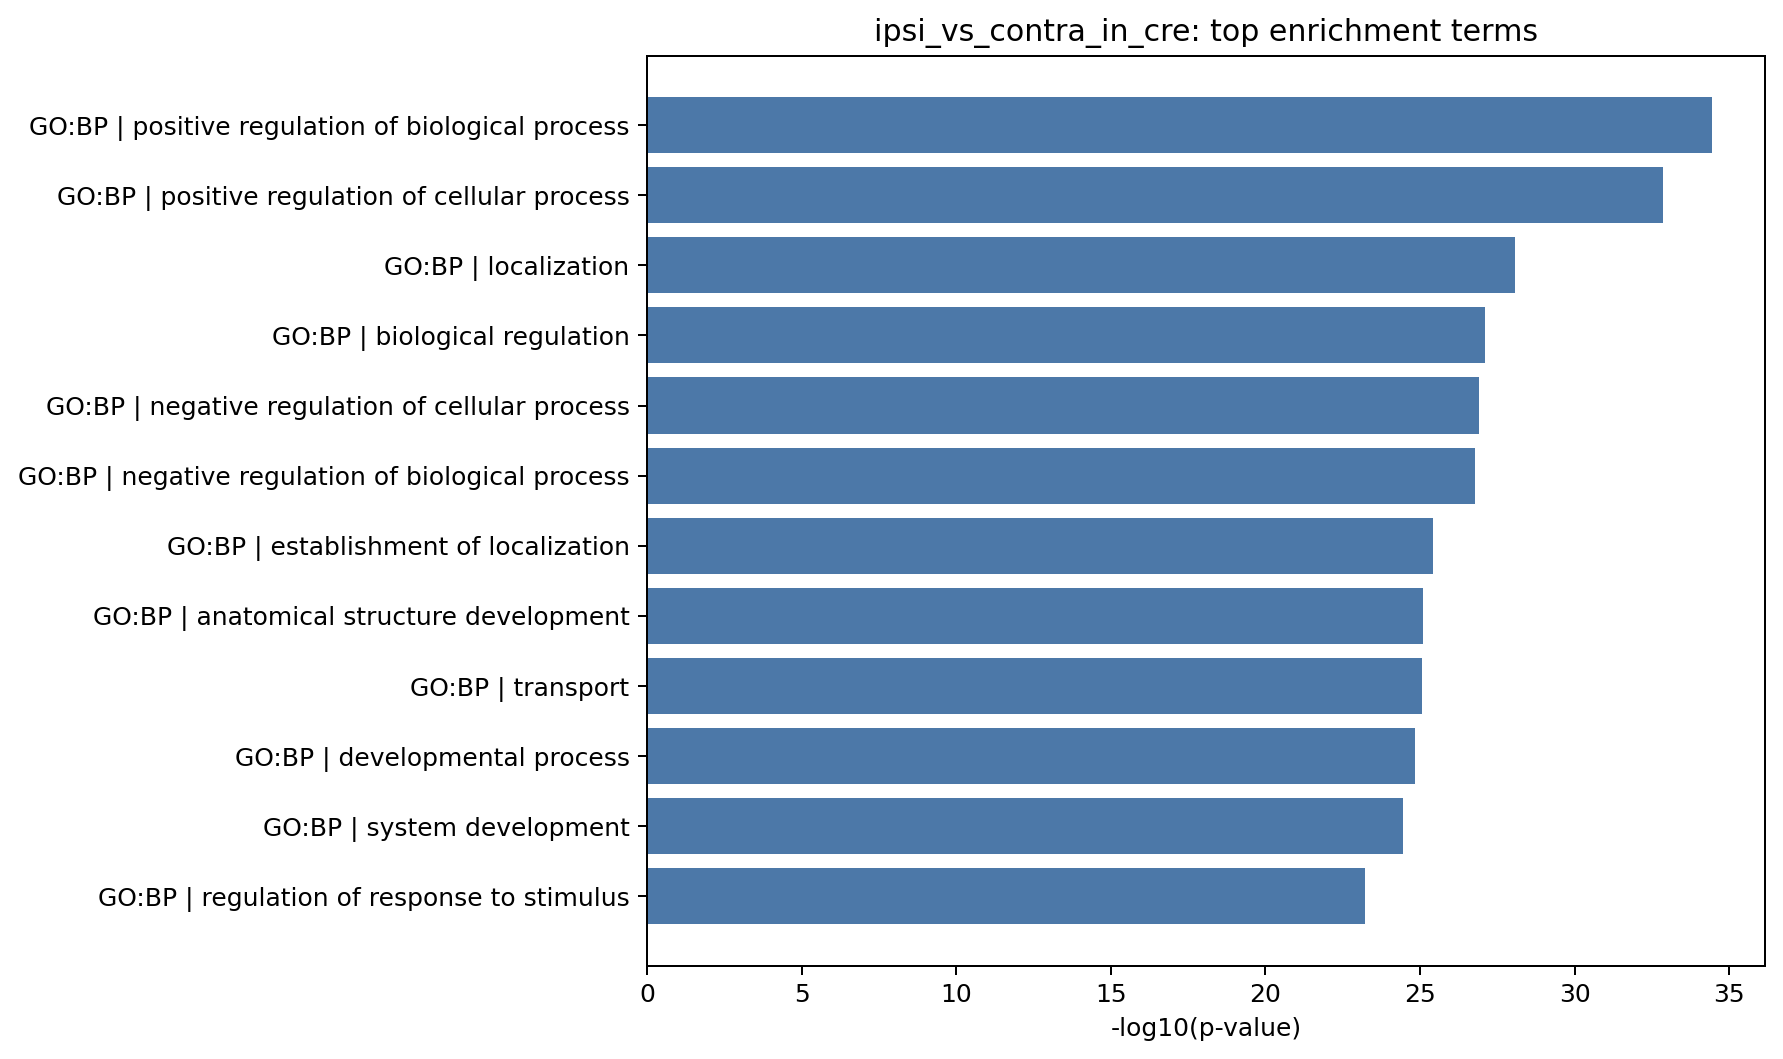

In [72]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'gprofiler_top_terms.png'), width=1000))

**What we did:** Displayed the top g:Profiler enrichment terms for the bend-point-selected `ipsi_vs_contra_in_cre` genes.

**Why it matters:** Like the `ff` branch, this uses the bend-point-filtered set rather than an arbitrary shortlist. The strongest terms again point to broad regulation, localization, transport, and developmental structure, giving us a second side-specific interpretation path to compare.

### Enrichment companion views — `ipsi_vs_contra_in_cre`

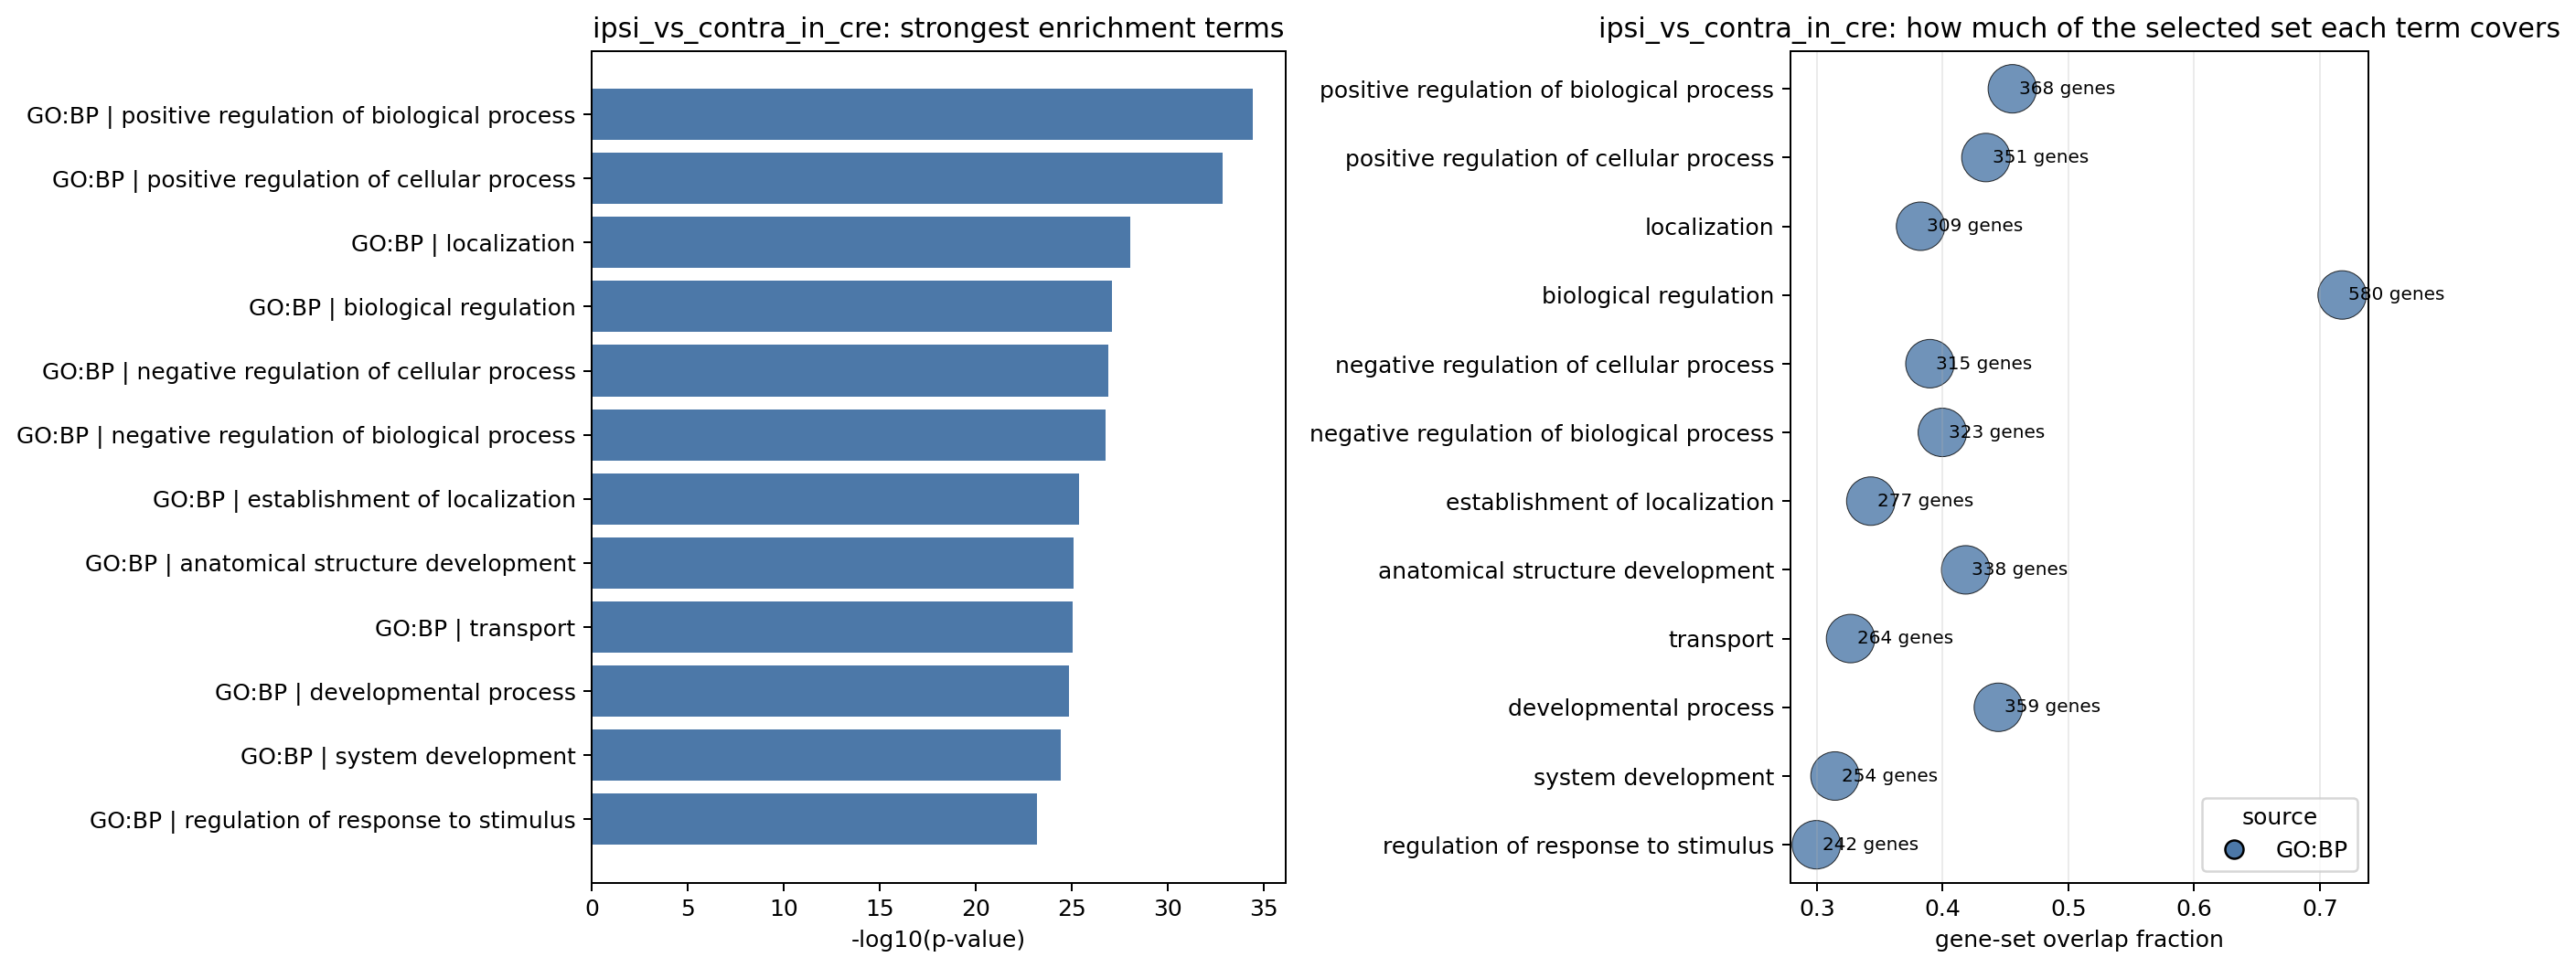

In [73]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'gprofiler_terms_and_overlap.png'), width=1200))

**What we did:** Displayed a companion enrichment figure for `ipsi_vs_contra_in_cre` that pairs the ranked-term summary with an overlap-focused view.

**Why it matters:** The left panel still shows which terms are strongest, while the right panel shows how much of the selected gene set each term actually covers and which source it came from. This helps us judge meaning, not just significance.

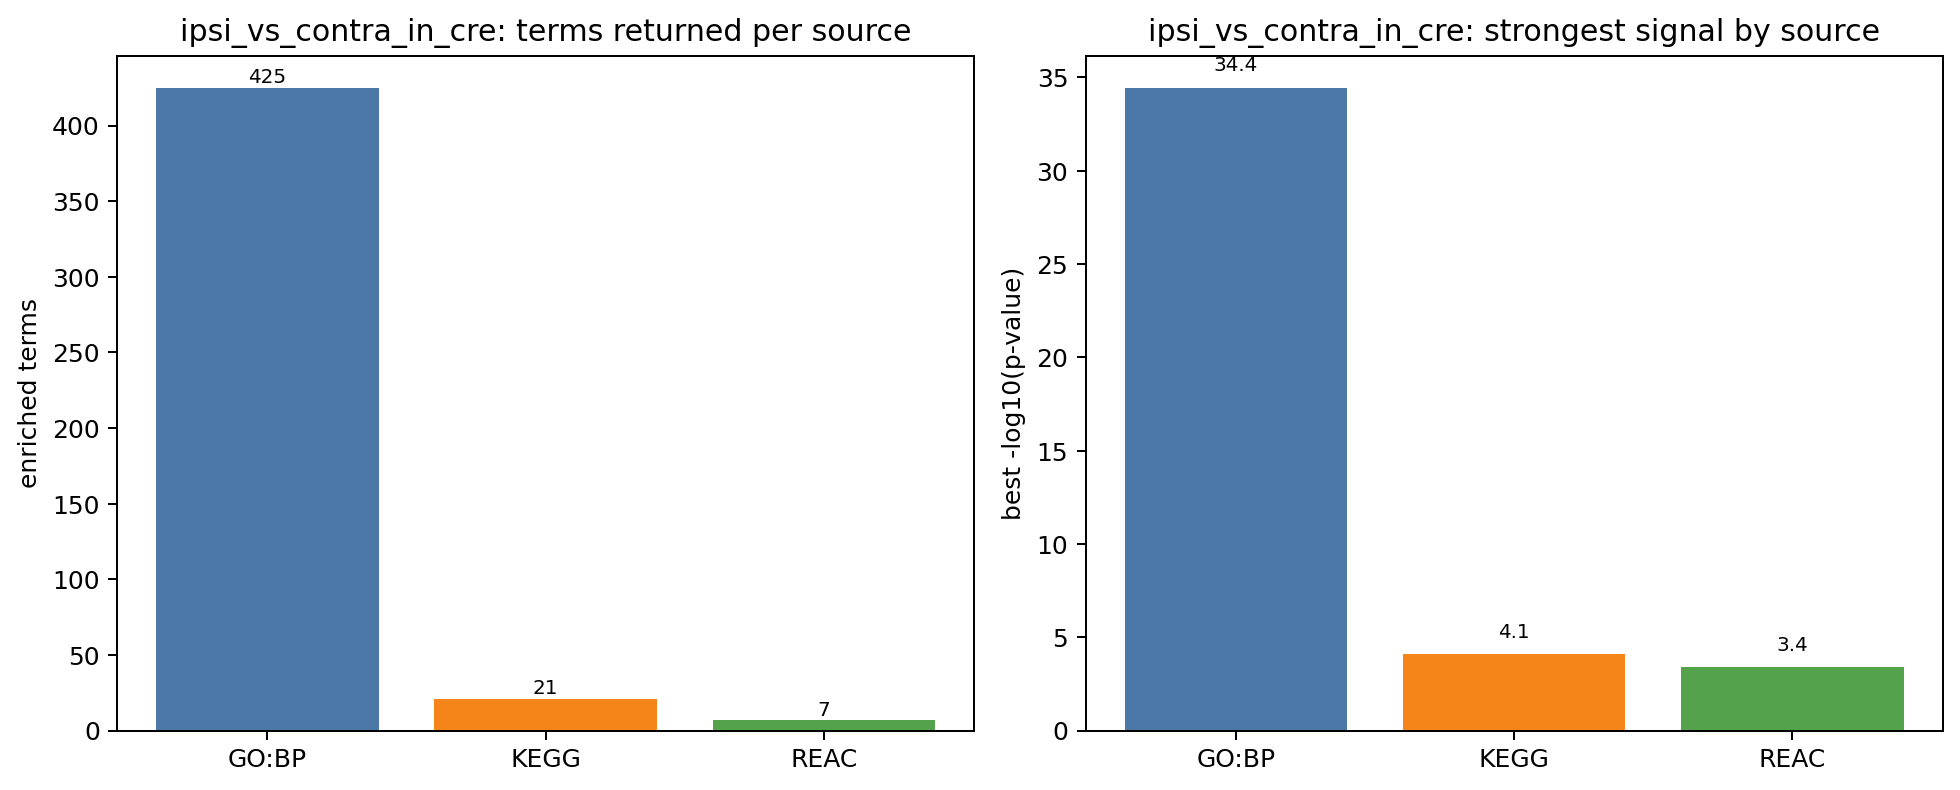

In [74]:
display(Image(filename=str(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'gprofiler_source_summary.png'), width=950))

**What we did:** Displayed a source-level enrichment summary for `ipsi_vs_contra_in_cre`.

**Why it matters:** This gives us a fast comparison of how much signal comes from `GO:BP`, `KEGG`, and `REAC`, which helps us decide which enrichment view is most report-worthy and whether the story is dominated by one source or replicated across several sources.

### Enrichment table preview — `ipsi_vs_contra_in_cre`

In [75]:
display(pd.read_csv(DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'gprofiler_enrichment.tsv', sep='	').head(20))

,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0048518,positive regulation of biological process,3.565315e-35,6447,808,368,25907,"['GO:0008150', 'GO:0050789']"
1,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0048522,positive regulation of cellular process,1.330502e-33,6095,808,351,25907,"['GO:0009987', 'GO:0048518', 'GO:0050794']"
2,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0051179,localization,8.660140e-29,5309,808,309,25907,['GO:0008150']
3,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0065007,biological regulation,8.104387e-28,13503,808,580,25907,['GO:0008150']
4,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0048523,negative regulation of cellular process,1.207533e-27,5540,808,315,25907,"['GO:0009987', 'GO:0048519', 'GO:0050794']"
5,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0048519,negative regulation of biological process,1.648342e-27,5759,808,323,25907,"['GO:0008150', 'GO:0050789']"
6,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0051234,establishment of localization,3.871346e-26,4666,808,277,25907,['GO:0051179']
7,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0048856,anatomical structure development,8.096807e-26,6280,808,338,25907,['GO:0032502']
8,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0006810,transport,8.626824e-26,4364,808,264,25907,['GO:0051234']
9,ipsi_vs_contra_in_cre,bend-point selected genes,GO:BP,GO:0032502,developmental process,1.409798e-25,6873,808,359,25907,['GO:0008150']


**What we did:** Displayed the enrichment table preview for `ipsi_vs_contra_in_cre`.

**Why it matters:** This gives us the concrete term-level details behind the CRE-side enrichment plot for figure and report selection.

### Top enrichment terms — `geno_in_contra`

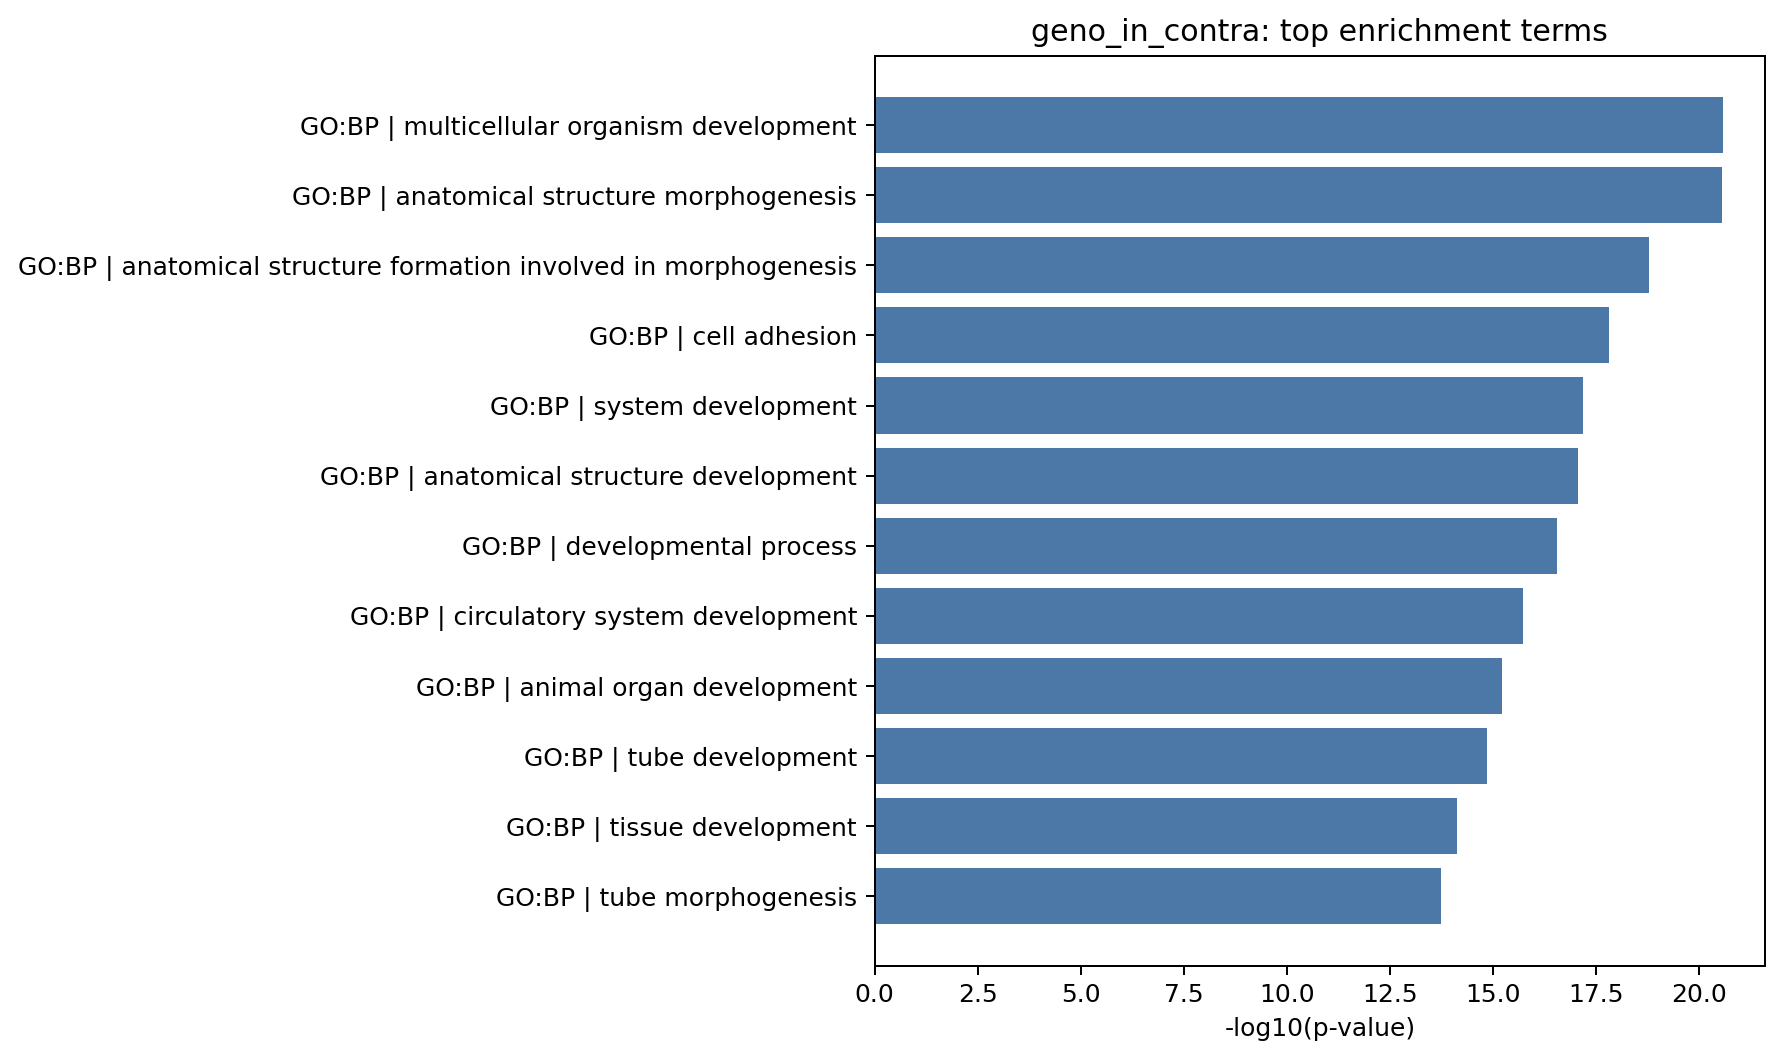

In [76]:
display(Image(filename=str(DERIVED_DIR / 'geno_in_contra' / 'gprofiler_top_terms.png'), width=1000))

**What we did:** Displayed the top g:Profiler enrichment terms for the bend-point-selected `geno_in_contra` genes.

**Why it matters:** `geno_in_contra` is now treated with the same bend-point narrowing logic as the main side-specific contrasts, which keeps the secondary genotype story comparable to the main story instead of relying on a looser padj-only set.

### Enrichment companion views — `geno_in_contra`

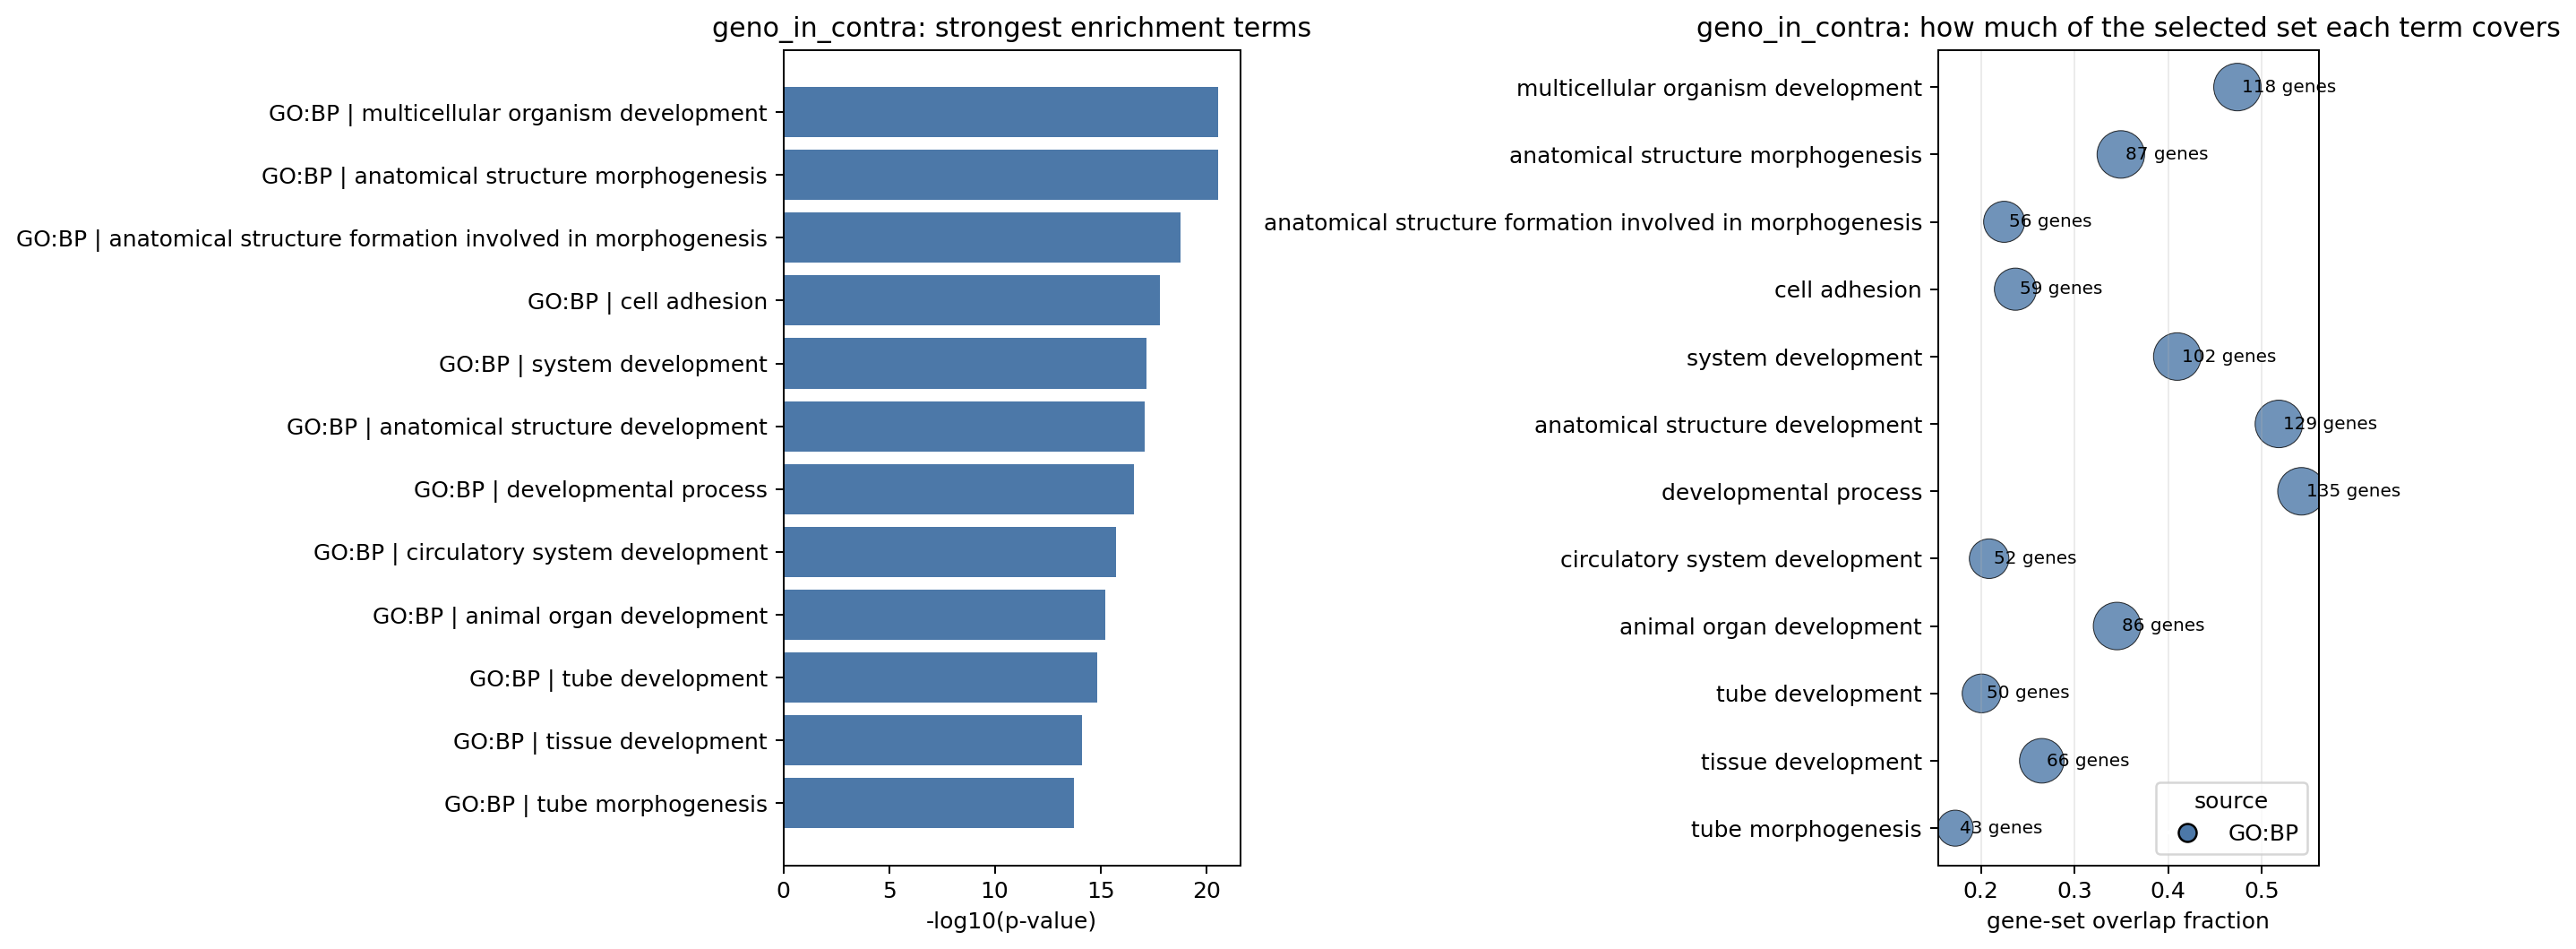

In [77]:
display(Image(filename=str(DERIVED_DIR / 'geno_in_contra' / 'gprofiler_terms_and_overlap.png'), width=1200))

**What we did:** Displayed a companion enrichment figure for `geno_in_contra` that pairs the ranked-term summary with an overlap-focused view.

**Why it matters:** The left panel still shows which terms are strongest, while the right panel shows how much of the selected gene set each term actually covers and which source it came from. This helps us judge meaning, not just significance.

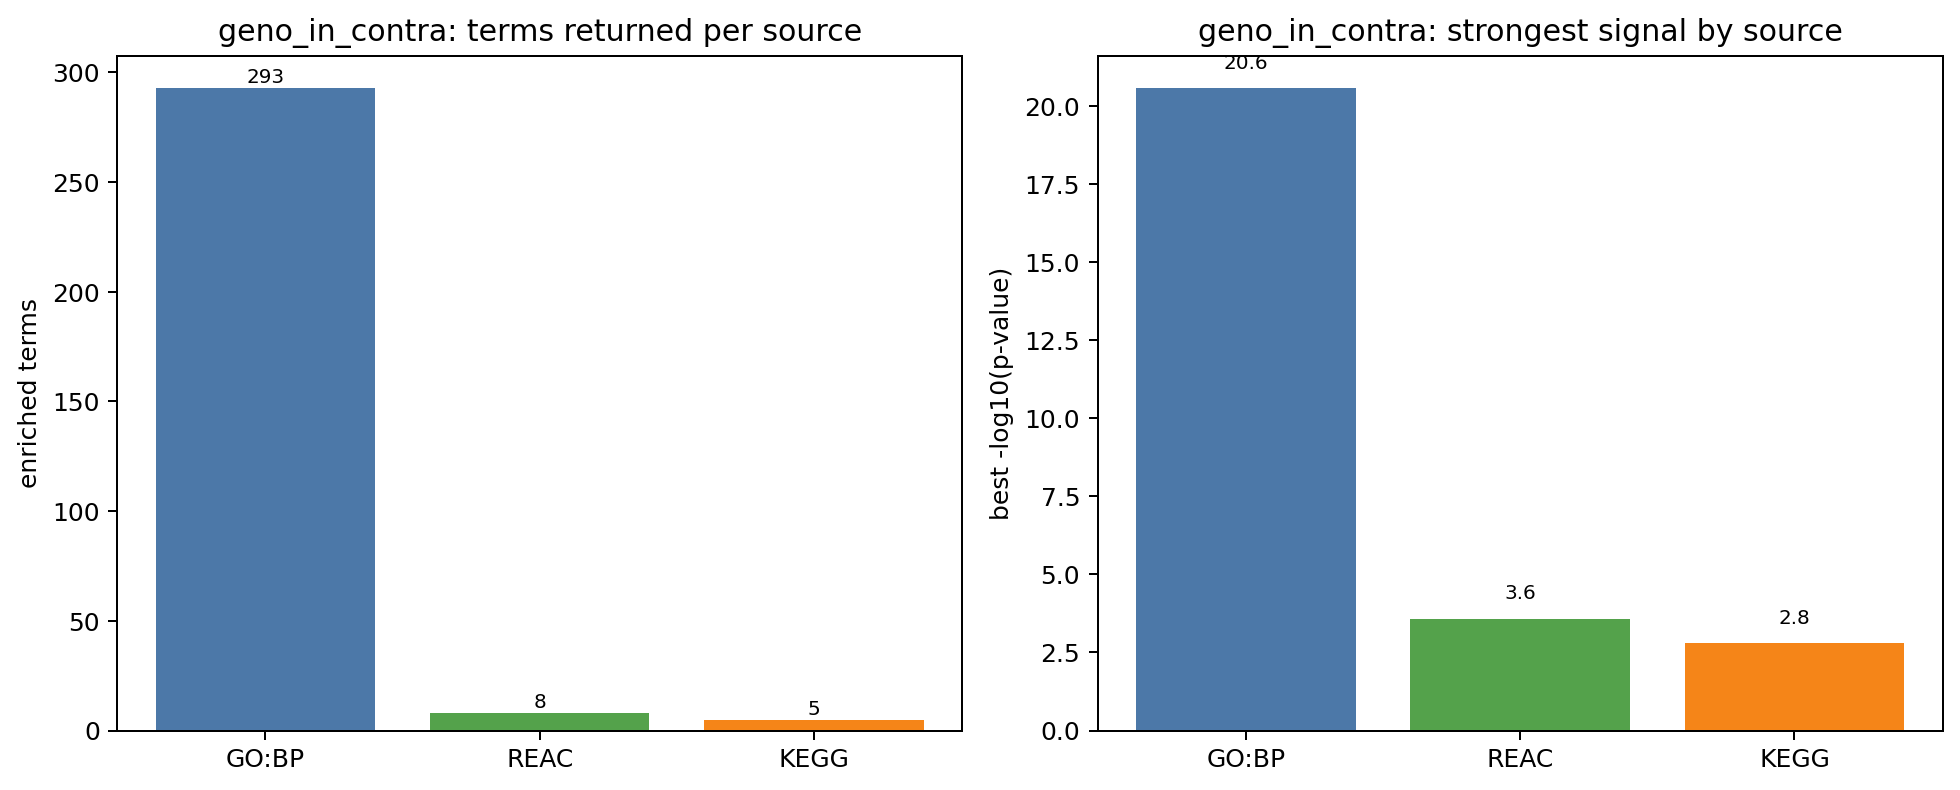

In [78]:
display(Image(filename=str(DERIVED_DIR / 'geno_in_contra' / 'gprofiler_source_summary.png'), width=950))

**What we did:** Displayed a source-level enrichment summary for `geno_in_contra`.

**Why it matters:** This gives us a fast comparison of how much signal comes from `GO:BP`, `KEGG`, and `REAC`, which helps us decide which enrichment view is most report-worthy and whether the story is dominated by one source or replicated across several sources.

### Enrichment table preview — `geno_in_contra`

In [79]:
display(pd.read_csv(DERIVED_DIR / 'geno_in_contra' / 'gprofiler_enrichment.tsv', sep='	').head(20))

,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,geno_in_contra,bend-point selected genes,GO:BP,GO:0007275,multicellular organism development,2.626361e-21,4907,249,118,25907,"['GO:0032501', 'GO:0048856']"
1,geno_in_contra,bend-point selected genes,GO:BP,GO:0009653,anatomical structure morphogenesis,2.773581e-21,2781,249,87,25907,"['GO:0032502', 'GO:0048856']"
2,geno_in_contra,bend-point selected genes,GO:BP,GO:0048646,anatomical structure formation involved in mor...,1.639167e-19,1230,249,56,25907,"['GO:0009653', 'GO:0032502']"
3,geno_in_contra,bend-point selected genes,GO:BP,GO:0007155,cell adhesion,1.486456e-18,1435,249,59,25907,['GO:0009987']
4,geno_in_contra,bend-point selected genes,GO:BP,GO:0048731,system development,6.619093e-18,4155,249,102,25907,"['GO:0007275', 'GO:0048856']"
5,geno_in_contra,bend-point selected genes,GO:BP,GO:0048856,anatomical structure development,8.507661e-18,6280,249,129,25907,['GO:0032502']
6,geno_in_contra,bend-point selected genes,GO:BP,GO:0032502,developmental process,2.714760e-17,6873,249,135,25907,['GO:0008150']
7,geno_in_contra,bend-point selected genes,GO:BP,GO:0072359,circulatory system development,1.891758e-16,1230,249,52,25907,['GO:0048731']
8,geno_in_contra,bend-point selected genes,GO:BP,GO:0048513,animal organ development,5.811260e-16,3272,249,86,25907,['GO:0048856']
9,geno_in_contra,bend-point selected genes,GO:BP,GO:0035295,tube development,1.406504e-15,1190,249,50,25907,"['GO:0007275', 'GO:0048856']"


**What we did:** Displayed the enrichment table preview for `geno_in_contra`.

**Why it matters:** The table now documents the bend-point-selected genotype gene set, its overlap with the top pathways, and the exact terms behind the genotype-focused enrichment plot.

### Top enrichment terms — `interaction`

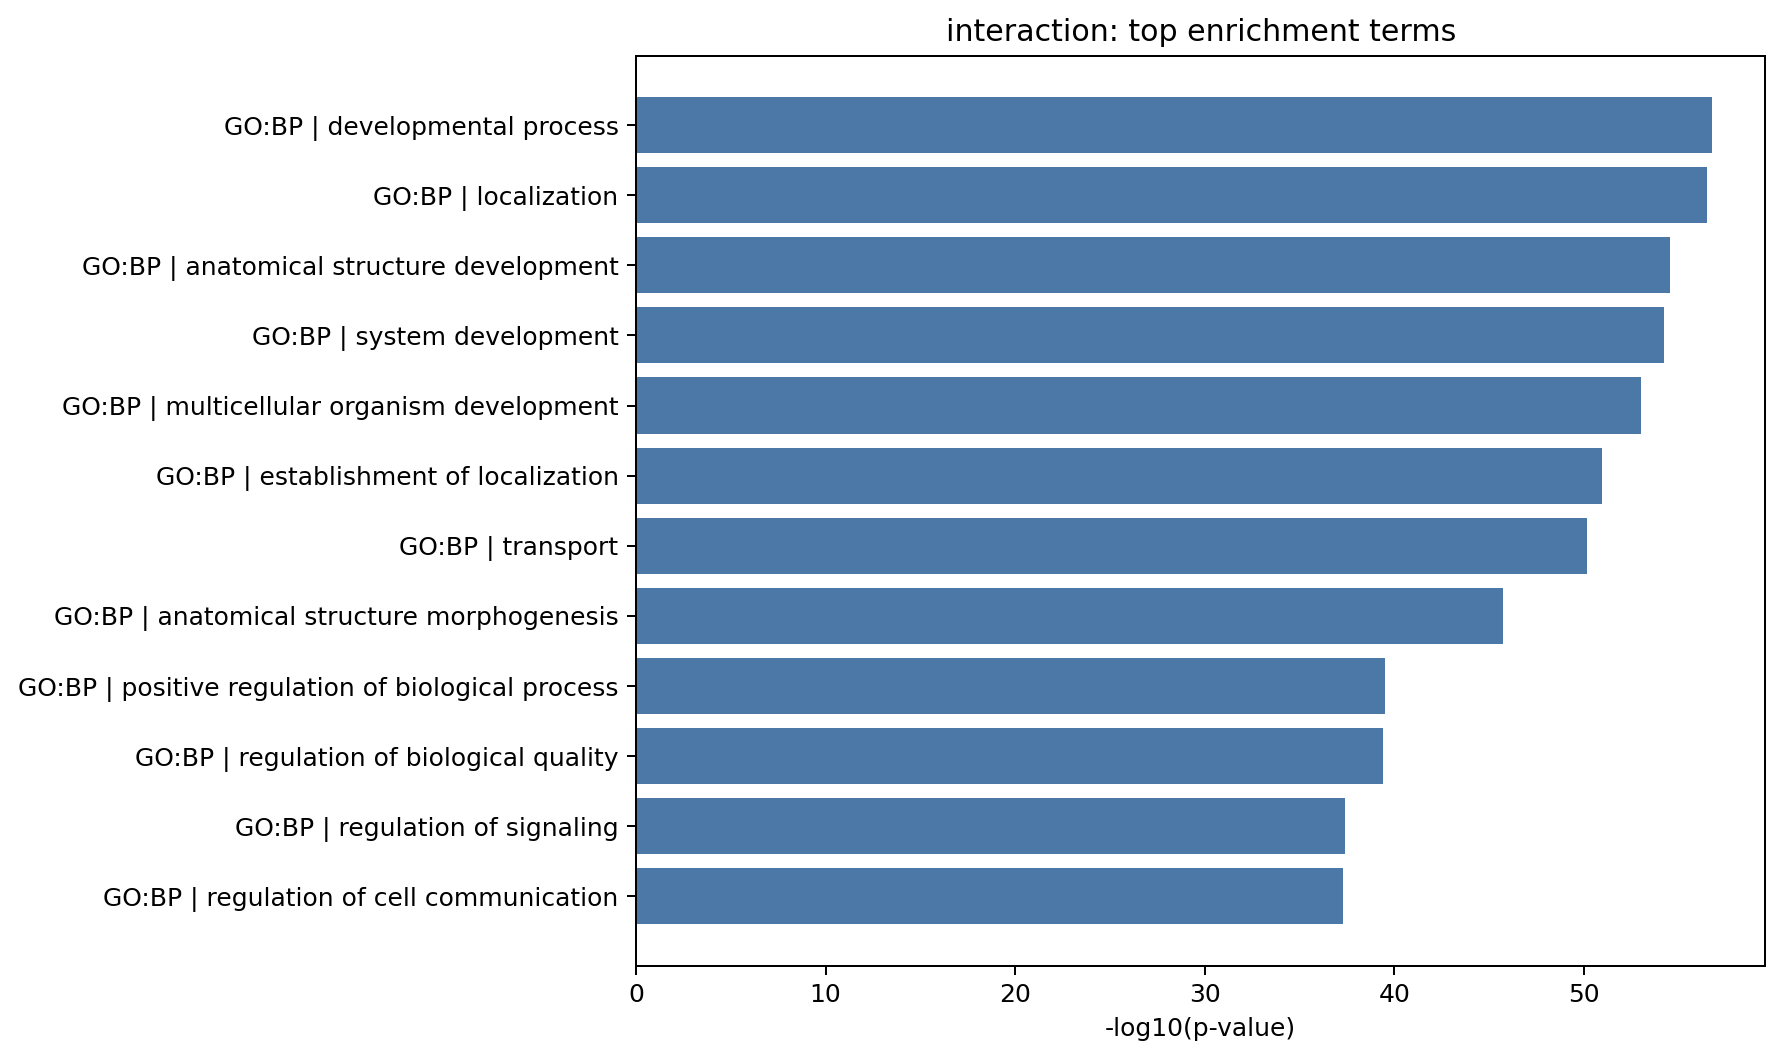

In [80]:
display(Image(filename=str(DERIVED_DIR / 'interaction' / 'gprofiler_top_terms.png'), width=1000))

**What we did:** Displayed the top g:Profiler enrichment terms for the bend-point-selected `interaction` genes.

**Why it matters:** This gives us a first-pass biological read on the interaction branch, but it should be treated as exploratory because the bend-point selection is much larger than the padj-significant core.

### Enrichment companion views — `interaction`

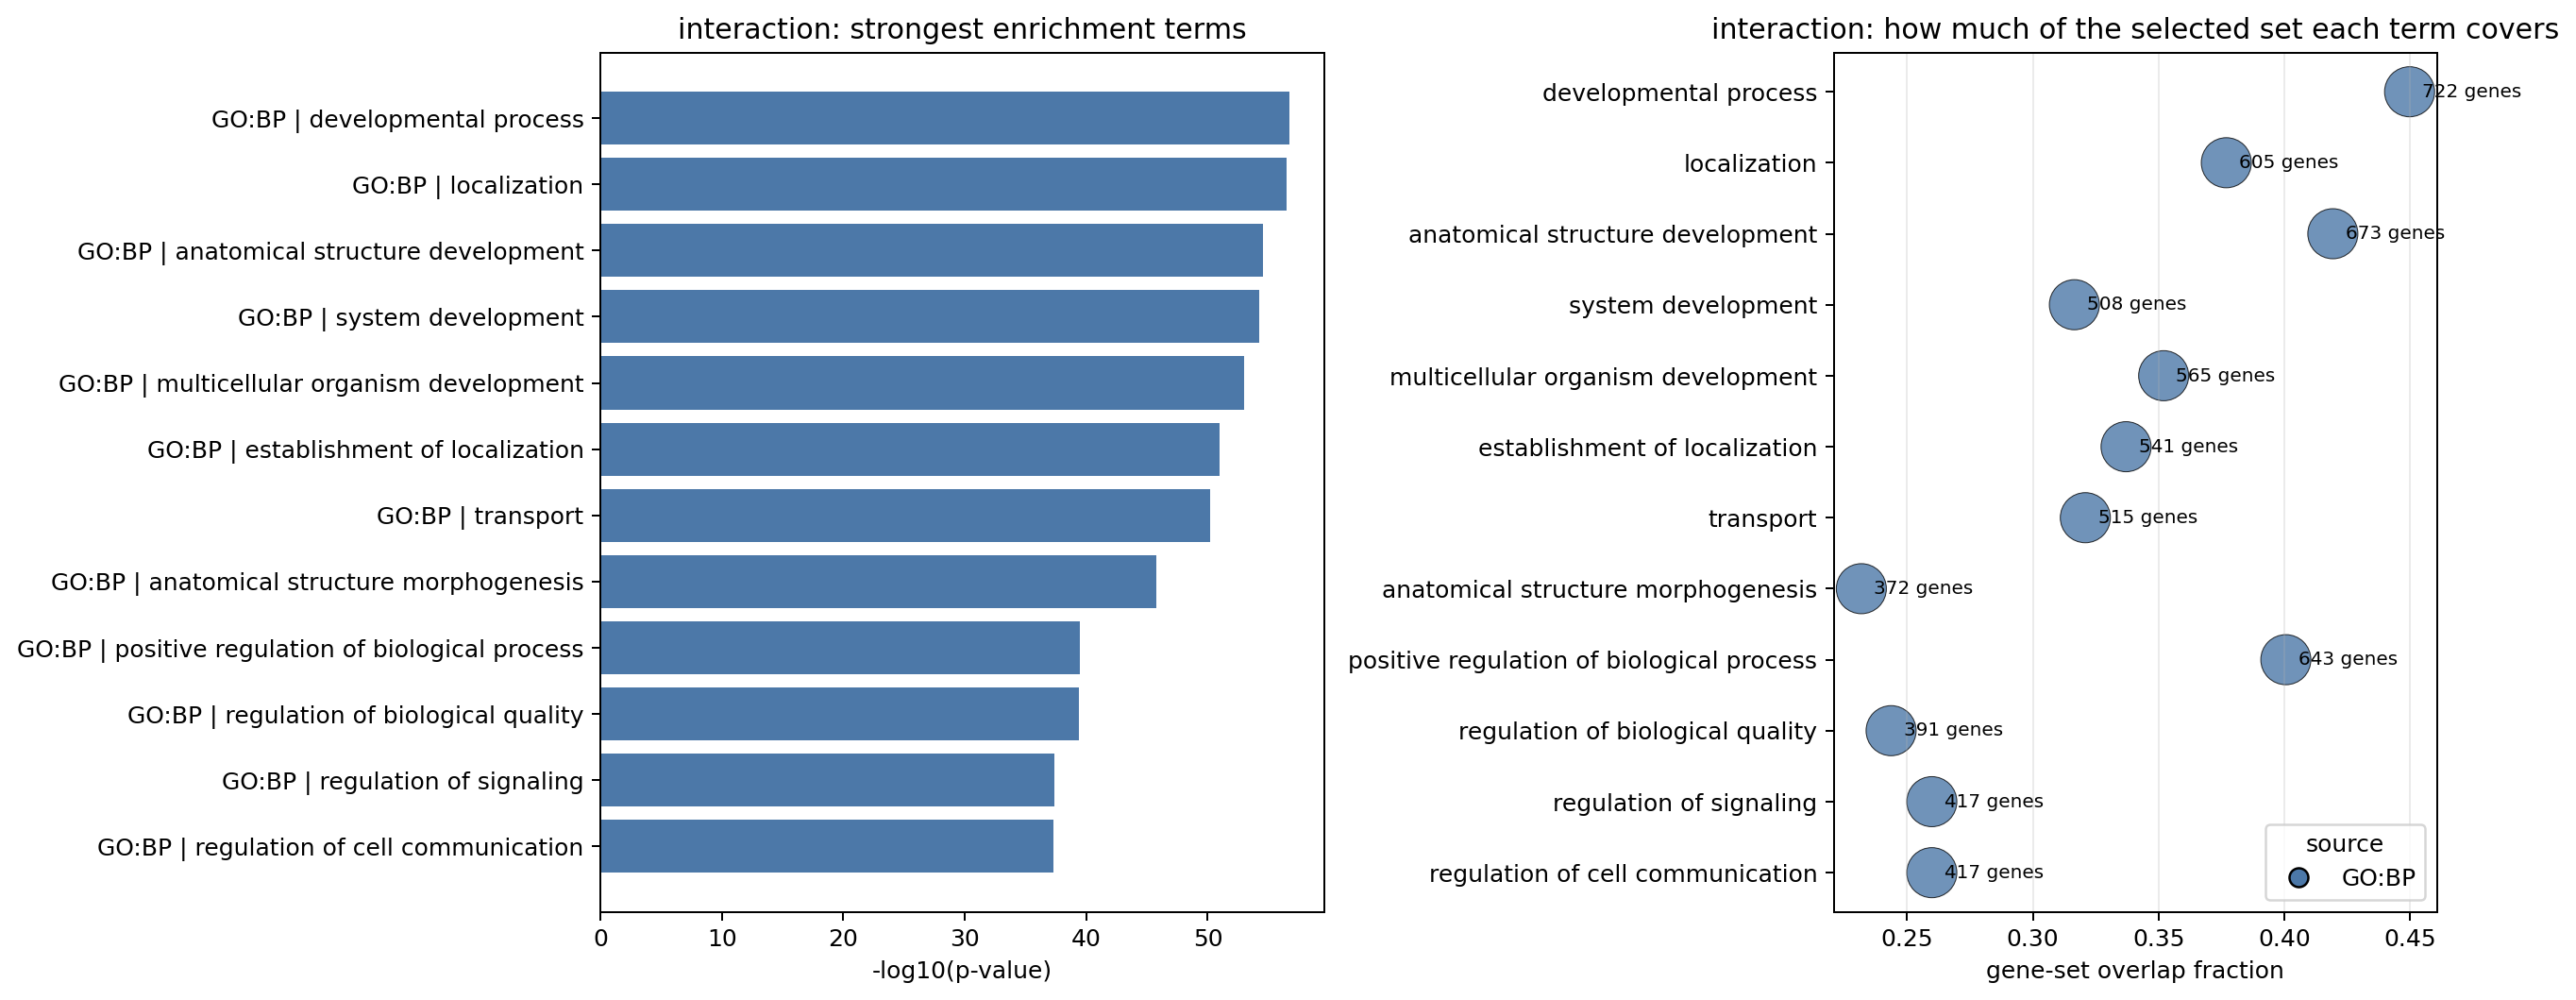

In [81]:
display(Image(filename=str(DERIVED_DIR / 'interaction' / 'gprofiler_terms_and_overlap.png'), width=1200))

**What we did:** Displayed a companion enrichment figure for `interaction` that pairs the ranked-term summary with an overlap-focused view.

**Why it matters:** The left panel still shows which terms are strongest, while the right panel shows how much of the selected gene set each term actually covers and which source it came from. This helps us judge meaning, not just significance.

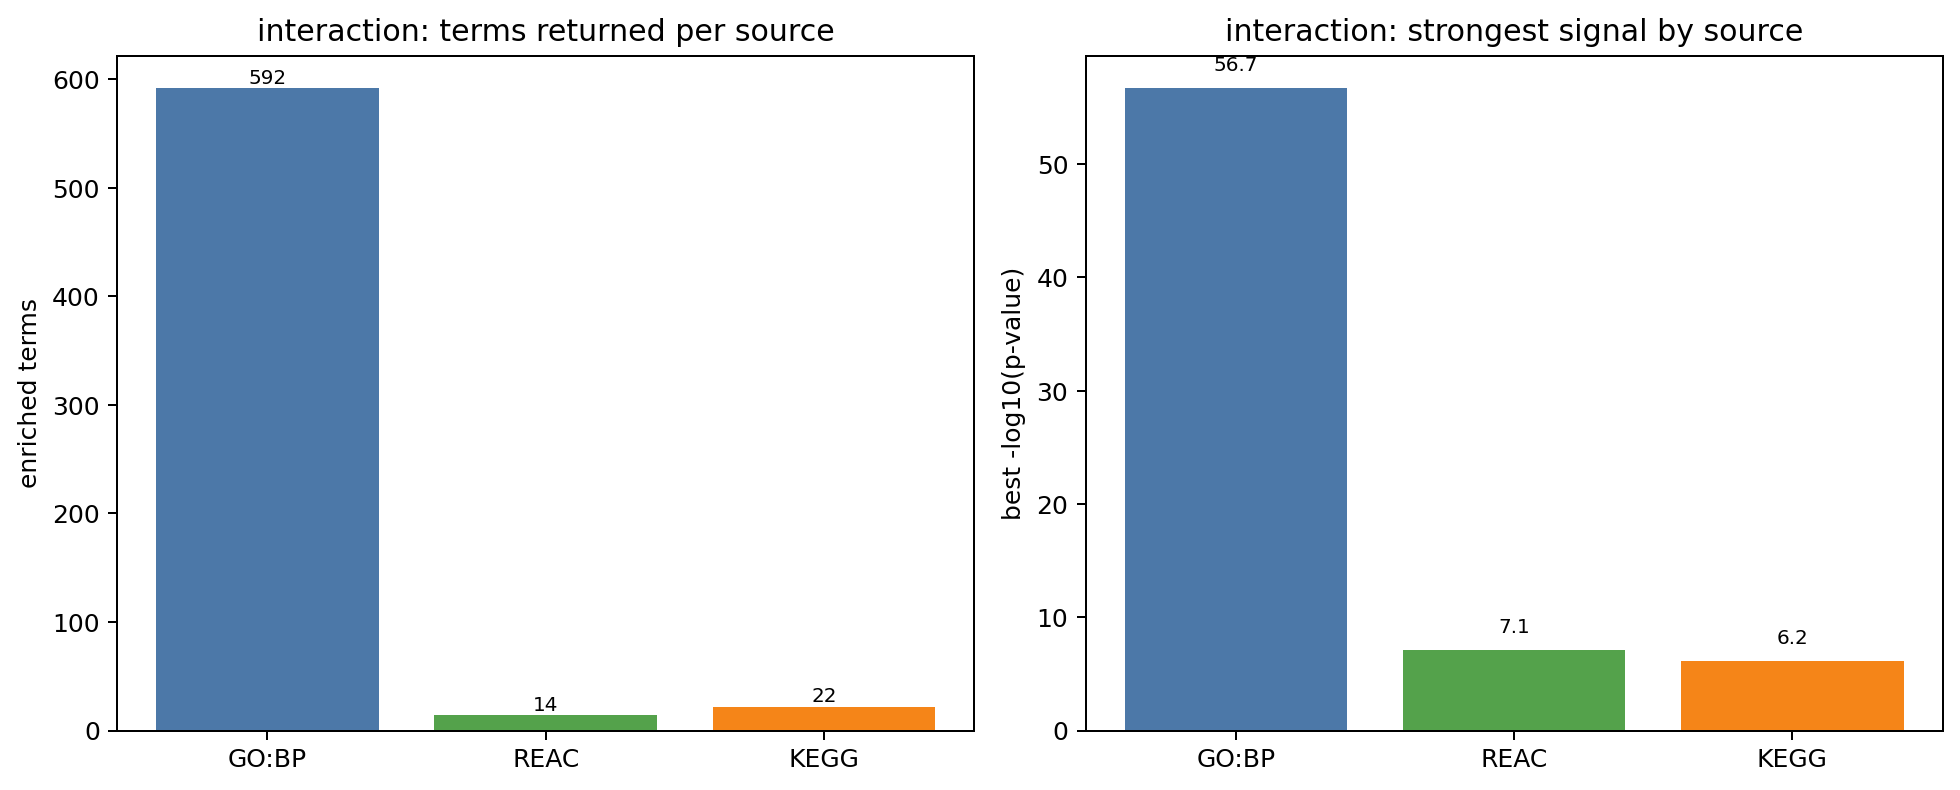

In [82]:
display(Image(filename=str(DERIVED_DIR / 'interaction' / 'gprofiler_source_summary.png'), width=950))

**What we did:** Displayed a source-level enrichment summary for `interaction`.

**Why it matters:** This gives us a fast comparison of how much signal comes from `GO:BP`, `KEGG`, and `REAC`, which helps us decide which enrichment view is most report-worthy and whether the story is dominated by one source or replicated across several sources.

### Enrichment table preview — `interaction`

In [83]:
display(pd.read_csv(DERIVED_DIR / 'interaction' / 'gprofiler_enrichment.tsv', sep='\t').head(20))

,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,interaction,bend-point selected genes,GO:BP,GO:0032502,developmental process,1.825940e-57,6873,1605,722,25907,['GO:0008150']
1,interaction,bend-point selected genes,GO:BP,GO:0051179,localization,3.045538e-57,5309,1605,605,25907,['GO:0008150']
2,interaction,bend-point selected genes,GO:BP,GO:0048856,anatomical structure development,3.030412e-55,6280,1605,673,25907,['GO:0032502']
3,interaction,bend-point selected genes,GO:BP,GO:0048731,system development,6.033550e-55,4155,1605,508,25907,"['GO:0007275', 'GO:0048856']"
4,interaction,bend-point selected genes,GO:BP,GO:0007275,multicellular organism development,1.023978e-53,4907,1605,565,25907,"['GO:0032501', 'GO:0048856']"
5,interaction,bend-point selected genes,GO:BP,GO:0051234,establishment of localization,1.073335e-51,4666,1605,541,25907,['GO:0051179']
6,interaction,bend-point selected genes,GO:BP,GO:0006810,transport,6.832929e-51,4364,1605,515,25907,['GO:0051234']
7,interaction,bend-point selected genes,GO:BP,GO:0009653,anatomical structure morphogenesis,1.754409e-46,2781,1605,372,25907,"['GO:0032502', 'GO:0048856']"
8,interaction,bend-point selected genes,GO:BP,GO:0048518,positive regulation of biological process,3.093599e-40,6447,1605,643,25907,"['GO:0008150', 'GO:0050789']"
9,interaction,bend-point selected genes,GO:BP,GO:0065008,regulation of biological quality,4.099497e-40,3180,1605,391,25907,['GO:0065007']


**What we did:** Displayed the enrichment table preview for `interaction`.

**Why it matters:** This lets us compare whether the interaction terms are specific enough to matter for the weekly report or whether they remain too broad to outrank the side-specific story.

## Weekly report takeaways

- **Recommended lead story:** keep the report centered on the side-specific DRG contrasts, with `ipsi_vs_contra_in_ff` and `ipsi_vs_contra_in_cre` as the main candidates because they align best with the PCA-first interpretation and still retain coherent bend-point-filtered follow-up sets.
- **Recommended secondary story:** keep `geno_in_contra` as the strongest genotype follow-up because it now has a bend-point-filtered gene set and usable enrichment profile.
- **Not yet promoted:** `geno_in_ipsi` and `interaction` now have exploratory bend-point outputs, but both still need stricter sanity checks before we let them compete with the side-specific story in the next weekly report.

## Main takeaways

- The `SRP618841` DE run completed for one balanced DRG family on `NovaSeq X`.
- The strongest visible structure is by side (`ipsi` vs `contra`), which is why the PCA should be interpreted first.
- The two main paper contrasts are `ipsi_vs_contra_in_ff` and `ipsi_vs_contra_in_cre`, and both still look like the strongest weekly-report candidates after bend-point filtering.
- Bend-point outputs now exist for every contrast, including `geno_in_contra`, `geno_in_ipsi`, and `interaction`.
- `geno_in_contra` remains the strongest secondary genotype branch and now has a bend-point-selected enrichment set that is easier to compare against the main side-specific branches.
- The local derived-analysis tree is:
  - `mouse_new/differential_expression_all20/derived_analysis/`
- The shared output tree on `sequoia` is:
  - `/home/zebrafish/mouse/SRP618841_parallel/differential_expression_all20`
